# Option Pricing with Quantum Machine Learning

## Q-volution 2026 QML Hackathon - Track B (Quandela)

This notebook implements a **hybrid quantum-classical model** for swaption (option) pricing
using Quandela's [MerLin framework](https://merlinquantum.ai) for photonic quantum machine learning.

### Core Concept

Swaption pricing exhibits complex non-linear dependencies on market factors (interest rates,
volatilities, correlations). While classical linear models capture the dominant structure,
**residual non-linearities** offer an opportunity for quantum enhancement.

Our approach follows the **"Quantum Residual Correction"** paradigm:
1. A **classical baseline** (Linear Regression) captures the dominant linear pricing structure
2. A **parameterized photonic quantum circuit** extracts non-linear features from the residual errors
3. The quantum features feed into a classical head that predicts corrections to the baseline

This "dressed quantum circuit" architecture is supported by recent research showing that
hybrid models where quantum circuits provide corrections to classical predictions consistently
outperform end-to-end quantum approaches.

### Key Technical Features

| Feature | Implementation | Reference |
|---------|---------------|-----------|
| **Framework** | MerLin + Perceval | Notton et al. (arXiv:2602.11092) |
| **Encoding** | Angle encoding only (QPU-compatible) | Schuld et al. (arXiv:2008.08605) |
| **Scaling** | Learnable per-feature ScaleLayer | Jerbi et al. (arXiv:2103.05577) |
| **Circuit** | Data re-uploading (multiple stages) | Perez-Salinas et al. (arXiv:1907.02085) |
| **Architecture** | Residual hybrid (classical + quantum) | arXiv:2511.20922, arXiv:2601.11942 |
| **Dressed Circuit** | Classical pre/post-processing | Mari et al. (arXiv:1912.08278) |
| **Normalization** | MinMax [0,1] + BatchNorm | Ioffe & Szegedy (arXiv:1502.03167) |
| **Noise Model** | QPU hardware-derived (Perceval) | Heurtel et al. (arXiv:2204.00602) |
| **Max Scale** | 20 modes / 10 photons | Competition constraint |

### Backends

| # | Backend | Description |
|---|---------|-------------|
| 1 | **CPU Simulator (SLOS)** | Local Perceval simulation |
| 2 | **GPU Accelerated** | CUDA-accelerated simulation via PyTorch |
| 3 | **QPU-Realistic Noise** | Noise model with hardware-derived parameters |
| 4 | **QPU Access** | Quandela Cloud (token in .env, commented out) |

## 0. Environment Setup

Install required packages and configure the runtime environment.

For **Google Colab**, uncomment and run the pip install cell below.
For **local development**, use the virtual environment:

```bash
python3.12 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
```

### Dependencies

| Package | Purpose |
|---------|---------|
| `merlinquantum` | Quandela's photonic QML framework |
| `perceval-quandela` | Photonic quantum computing simulator |
| `torch` | Deep learning backend (GPU support) |
| `scikit-learn` | Classical baselines, preprocessing |
| `python-dotenv` | Secure API token management |
| `datasets` | HuggingFace dataset loading |

In [1]:
# Install dependencies (uncomment for Google Colab)
# !pip install merlinquantum datasets pandas scikit-learn matplotlib seaborn tqdm python-dotenv torch torchvision 

In [2]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import special
import perceval as pcvl
from merlin import QuantumLayer, LexGrouping, MeasurementStrategy, ComputationSpace
from merlin.builder import CircuitBuilder

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Load Quandela Cloud token from .env file (never hardcode for GitHub)
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    print("python-dotenv not installed. Set QUANDELA_TOKEN env var manually.")

QUANDELA_TOKEN = os.environ.get("QUANDELA_TOKEN", "")
if QUANDELA_TOKEN:
    print(f"Quandela Cloud token loaded ({len(QUANDELA_TOKEN)} chars)")
else:
    print("WARNING: QUANDELA_TOKEN not found. Create a .env file with QUANDELA_TOKEN=your_token")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device selection
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu_props.name} ({gpu_props.total_memory/1e9:.0f} GB VRAM)")
else:
    DEVICE = torch.device("cpu")
    print("Running on CPU (GPU recommended for larger circuits)")

print(f"PyTorch {torch.__version__} | Perceval {pcvl.__version__} | Device: {DEVICE}")

# Ensure output directories exist (self-contained on Colab)
os.makedirs('results', exist_ok=True)
os.makedirs('results/models', exist_ok=True)

Quandela Cloud token loaded (175 chars)
GPU: NVIDIA RTX PRO 6000 Blackwell Workstation Edition (102 GB VRAM)
PyTorch 2.10.0+cu128 | Perceval 1.1.0 | Device: cuda:0


## 1. Data Loading and Exploratory Analysis

### Dataset: Quandela/Challenge_Swaptions (HuggingFace)

The dataset contains historical swaption prices organized as a time series:
- **Rows**: Trading dates (494 dates for Level 1)
- **Columns**: 224 swaption contracts defined by (Tenor, Maturity) pairs
  - **Tenor** (14 values): 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30 years
  - **Maturity** (16 values): 1/12, 1/4, 1/2, 3/4, 1, 1.5, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30 years

**Level 1 - Future Prediction**: Given complete historical data, predict prices for the next two weeks.

**Level 2 - Missing Data**: Same task but with missing values that must be imputed first.

In [3]:
from datasets import load_dataset

# Level 1: Future prediction (complete data)
ds_level1 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train",
)
df_level1 = ds_level1.to_pandas()
print(f"Level 1: {df_level1.shape[0]} dates x {df_level1.shape[1]} columns")

# Level 2: Missing data prediction
ds_level2 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-2_Missing_data_prediction/train_level2.csv",
    split="train",
)
df_level2 = ds_level2.to_pandas()
missing_count = df_level2.isnull().sum().sum()
print(f"Level 2: {df_level2.shape[0]} dates x {df_level2.shape[1]} columns, {missing_count} missing values")

# Display basic statistics
numeric_cols = df_level1.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric features: {len(numeric_cols)}")
print(f"Date range: {df_level1.iloc[0, 0]} to {df_level1.iloc[-1, 0]}")
print(f"\nPrice statistics:")
print(df_level1[numeric_cols].describe().round(4))

Level 1: 494 dates x 225 columns
Level 2: 489 dates x 225 columns, 0 missing values

Numeric features: 224
Date range: 01/01/2050 to 23/12/2051

Price statistics:
       Tenor : 1; Maturity : 0.0833333333333333  \
count                                  494.0000   
mean                                     0.0300   
std                                      0.0073   
min                                      0.0205   
25%                                      0.0249   
50%                                      0.0277   
75%                                      0.0336   
max                                      0.0632   

       Tenor : 2; Maturity : 0.0833333333333333  \
count                                  494.0000   
mean                                     0.0395   
std                                      0.0071   
min                                      0.0275   
25%                                      0.0343   
50%                                      0.0382   
75%                 

### Exploratory Data Analysis

We visualize the swaption pricing surface and time-series dynamics to understand
the data structure before designing the quantum model.

> **Note**: The dataset values represent **swaption prices** (as per the official
> training material: *"The dataset contains swaption prices for multiple dates,
> maturities, and tenors"*). While swaptions are closely related to implied
> volatility, the challenge targets **price prediction**, not volatility forecasting.


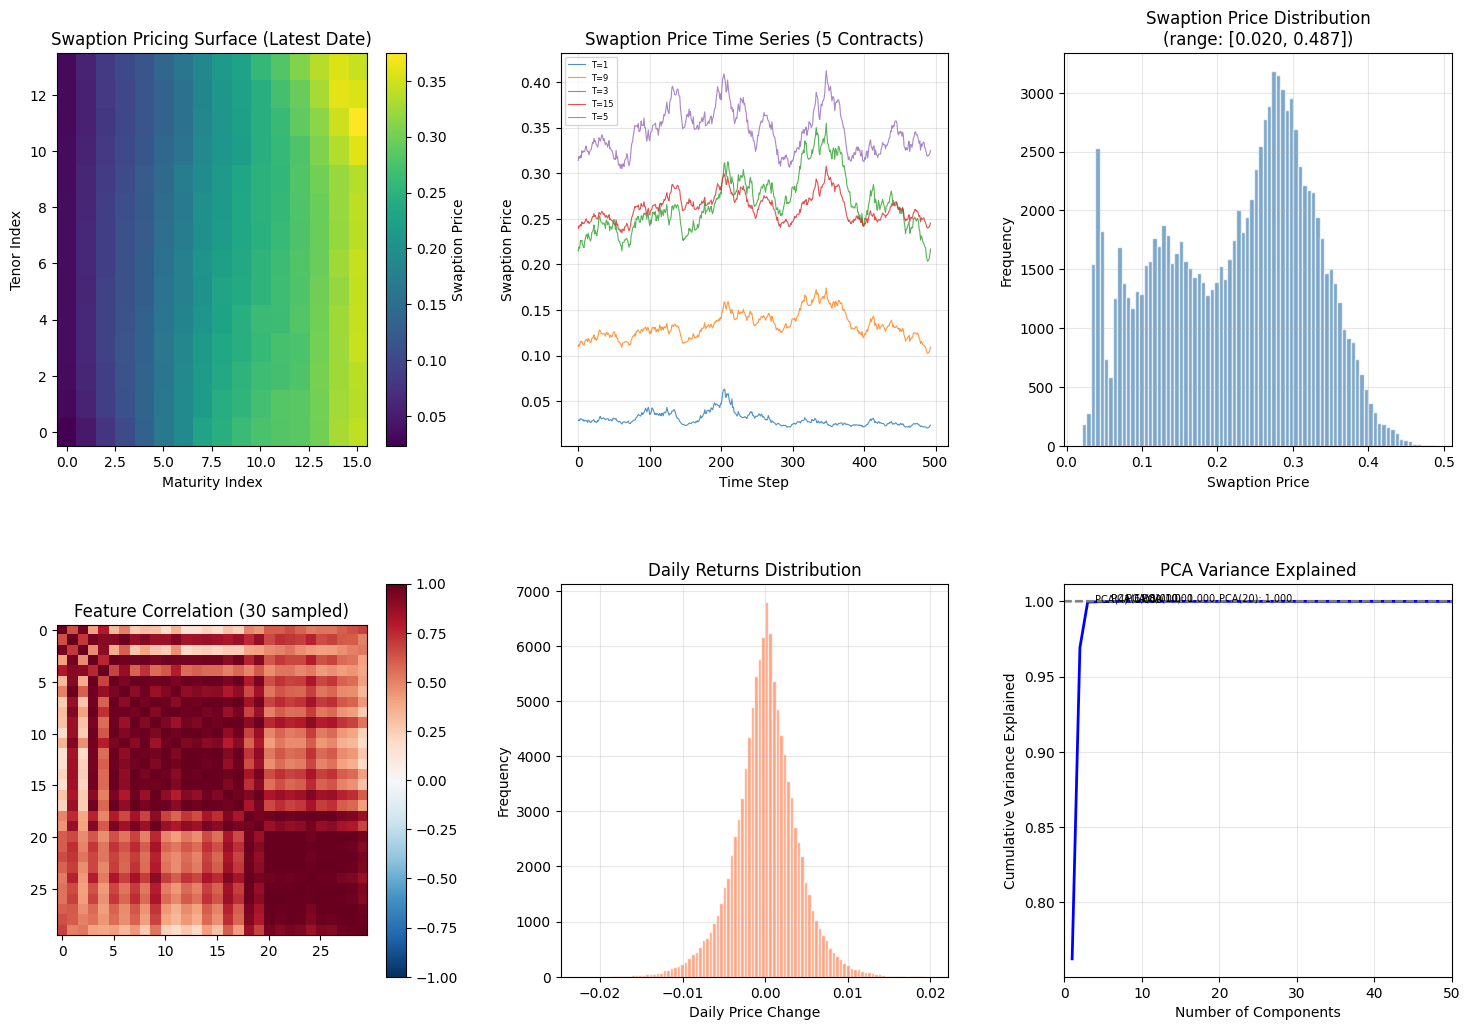

EDA analysis saved to eda_analysis.png


In [4]:
# Parse tenor and maturity from column names
tenors, maturities = [], []
for col in numeric_cols:
    parts = col.replace("Tenor : ", "").replace("Maturity : ", "").split("; ")
    tenors.append(float(parts[0]))
    maturities.append(float(parts[1]))

unique_tenors = sorted(set(tenors))
unique_maturities = sorted(set(maturities))

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# 1. Price surface at last date
ax1 = fig.add_subplot(gs[0, 0])
last_prices = df_level1[numeric_cols].iloc[-1].values
surface = np.full((len(unique_tenors), len(unique_maturities)), np.nan)
for i, col in enumerate(numeric_cols):
    ti = unique_tenors.index(tenors[i])
    mi = unique_maturities.index(maturities[i])
    surface[ti, mi] = last_prices[i]
im = ax1.imshow(surface, aspect='auto', cmap='viridis', origin='lower')
ax1.set_xlabel('Maturity Index')
ax1.set_ylabel('Tenor Index')
ax1.set_title('Swaption Pricing Surface (Latest Date)')
plt.colorbar(im, ax=ax1, label='Swaption Price')

# 2. Time series of selected contracts
ax2 = fig.add_subplot(gs[0, 1])
sample_cols = [numeric_cols[i] for i in [0, 50, 100, 150, 200]]
for col in sample_cols:
    label = col.split(';')[0].replace('Tenor : ', 'T=')
    ax2.plot(df_level1[col].values, label=label, alpha=0.8, linewidth=0.8)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Swaption Price')
ax2.set_title('Swaption Price Time Series (5 Contracts)')
ax2.legend(fontsize=6)
ax2.grid(True, alpha=0.3)

# 3. Price distribution
ax3 = fig.add_subplot(gs[0, 2])
all_prices = df_level1[numeric_cols].values.flatten()
ax3.hist(all_prices, bins=80, alpha=0.7, color='steelblue', edgecolor='white')
ax3.set_xlabel('Swaption Price')
ax3.set_ylabel('Frequency')
ax3.set_title(f'Swaption Price Distribution\n(range: [{all_prices.min():.3f}, {all_prices.max():.3f}])')
ax3.grid(True, alpha=0.3)

# 4. Correlation heatmap (sampled)
ax4 = fig.add_subplot(gs[1, 0])
sample_idx = np.linspace(0, len(numeric_cols)-1, 30, dtype=int)
corr = df_level1[[numeric_cols[i] for i in sample_idx]].corr()
im4 = ax4.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax4.set_title('Feature Correlation (30 sampled)')
plt.colorbar(im4, ax=ax4)

# 5. Daily returns distribution
ax5 = fig.add_subplot(gs[1, 1])
returns = df_level1[numeric_cols].diff().iloc[1:]
ax5.hist(returns.values.flatten(), bins=100, alpha=0.7, color='coral', edgecolor='white')
ax5.set_xlabel('Daily Price Change')
ax5.set_ylabel('Frequency')
ax5.set_title('Daily Returns Distribution')
ax5.grid(True, alpha=0.3)

# 6. Variance explained by PCA
ax6 = fig.add_subplot(gs[1, 2])
pca_full = PCA().fit(df_level1[numeric_cols].dropna())
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
ax6.plot(range(1, len(cumvar)+1), cumvar, 'b-', linewidth=2)
for n in [4, 6, 8, 10, 20]:
    if n <= len(cumvar):
        ax6.axhline(cumvar[n-1], color='gray', linestyle='--', alpha=0.5)
        ax6.annotate(f'PCA({n}): {cumvar[n-1]:.3f}', xy=(n, cumvar[n-1]),
                     fontsize=7, ha='left')
ax6.set_xlabel('Number of Components')
ax6.set_ylabel('Cumulative Variance Explained')
ax6.set_title('PCA Variance Explained')
ax6.grid(True, alpha=0.3)
ax6.set_xlim(0, 50)

plt.savefig('results/eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA analysis saved to eda_analysis.png")

## 2. Data Preprocessing

### Pipeline Design

Our preprocessing follows QML best practices for angle encoding on photonic circuits:

1. **Min-Max Normalization to [0, 1]**: Required because angle encoding maps features
   to phase shifter angles. Features outside [0, 1] would wrap around in the phase space,
   creating aliasing artifacts. MinMaxScaler is preferred over StandardScaler for this reason.
   (Ref: MerLin VQC classification notebook, `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_classification.ipynb`)

2. **Sliding Window (size=5)**: Creates time-series input sequences. Each input is 5 consecutive
   trading days flattened into a vector (5 x 224 = 1,120 features), predicting the next day's
   224 prices.

3. **PCA Dimensionality Reduction**: Reduces the 1,120-dimensional input to match the quantum
   circuit's number of encoding modes (4-10 features). PCA with 6 components retains 99.2%
   of the variance, indicating high redundancy in the swaption surface.

4. **Learnable Input Scaling**: Instead of hardcoding `x * pi`, we use a learnable
   `ScaleLayer` that optimizes the encoding range per feature during training.
   The Fourier analysis of VQCs shows that the encoding scale determines the accessible
   frequency spectrum (Schuld, Sweke & Meyer, Phys. Rev. A 103, 032430, 2021; arXiv:2008.08605).

In [5]:
# Select numeric features and prepare data
df_clean = df_level1[numeric_cols].dropna()
data_values = df_clean.values.astype(np.float32)
N_FEATURES = data_values.shape[1]
print(f"Numeric columns: {len(numeric_cols)}, Clean samples: {len(df_clean)}")

# Min-Max normalization to [0, 1] (optimal for angle encoding)
scaler = MinMaxScaler(feature_range=(0, 1))
data_normalized = scaler.fit_transform(data_values)
print(f"Data range after normalization: [{data_normalized.min():.4f}, {data_normalized.max():.4f}]")

Numeric columns: 224, Clean samples: 494
Data range after normalization: [0.0000, 1.0000]


In [6]:
# Sliding window for time-series prediction
def create_sequences(data, window_size=5, target_size=1):
    """Create input-output pairs using a sliding window approach.

    Args:
        data: Normalized data array (n_samples, n_features)
        window_size: Number of past time steps as input
        target_size: Number of future time steps to predict

    Returns:
        X: Input sequences (n_sequences, window_size * n_features)
        y: Target values (n_sequences, target_size * n_features)
    """
    X, y = [], []
    for i in range(len(data) - window_size - target_size + 1):
        X.append(data[i : i + window_size].flatten())
        y.append(data[i + window_size : i + window_size + target_size].flatten())
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

WINDOW_SIZE = 5
X_seq, y_seq = create_sequences(data_normalized, WINDOW_SIZE, 1)
print(f"Sequences: X={X_seq.shape} (windows of {WINDOW_SIZE} days), y={y_seq.shape} (next day)")

# Train/validation split (80/20, no shuffling would be ideal for time series,
# but we use random split for simplicity as the challenge allows it)
X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=SEED
)
OUTPUT_SIZE = y_train.shape[-1]
print(f"Train: {X_train.shape[0]} samples, Val: {X_val.shape[0]} samples")
print(f"Output dimension: {OUTPUT_SIZE} (all {len(numeric_cols)} swaption prices)")

Sequences: X=(489, 1120) (windows of 5 days), y=(489, 224) (next day)
Train: 391 samples, Val: 98 samples
Output dimension: 224 (all 224 swaption prices)


In [7]:
# PCA preparation for different quantum circuit input sizes
def prepare_data(X_train, X_val, y_train, y_val, n_features, batch_size=32):
    """Apply PCA and create DataLoaders for a given number of quantum input features."""
    pca = PCA(n_components=n_features)
    Xt = pca.fit_transform(X_train).astype(np.float32)
    Xv = pca.transform(X_val).astype(np.float32)
    explained = pca.explained_variance_ratio_.sum()
    print(f"  PCA({n_features:2d}): {explained:.4f} cumulative variance explained")

    train_dl = DataLoader(
        TensorDataset(torch.tensor(Xt), torch.tensor(y_train, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True,
    )
    val_dl = DataLoader(
        TensorDataset(torch.tensor(Xv), torch.tensor(y_val, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False,
    )
    return train_dl, val_dl, pca, Xt, Xv

print("Preparing PCA-reduced datasets for each quantum circuit scale:")
d4  = prepare_data(X_train, X_val, y_train, y_val, 4)
d6  = prepare_data(X_train, X_val, y_train, y_val, 6)
d8  = prepare_data(X_train, X_val, y_train, y_val, 8)
d10 = prepare_data(X_train, X_val, y_train, y_val, 10)

Preparing PCA-reduced datasets for each quantum circuit scale:


  PCA( 4): 0.9833 cumulative variance explained
  PCA( 6): 0.9919 cumulative variance explained
  PCA( 8): 0.9965 cumulative variance explained
  PCA(10): 0.9982 cumulative variance explained


## 3. Classical Baselines

We establish classical baselines to provide a reference for evaluating the quantum model.
This is critical for understanding whether quantum features add value beyond classical methods.

**Linear Regression** serves as the primary baseline because swaption prices have strong
linear dependencies (driven by the Black-Scholes-like structure of interest rate derivatives).

**MLP (Multi-Layer Perceptron)** provides a non-linear classical baseline to test whether
the quantum model's non-linearity offers advantages over classical non-linear models.

In [8]:
print("=" * 70)
print("Classical Baselines (using PCA(6) features)")
print("=" * 70)

# Use PCA(6) features for all baselines
_, _, _, Xt_base, Xv_base = d6

# 1. Linear Regression
t0 = time.time()
lr_model = LinearRegression()
lr_model.fit(Xt_base, y_train)
lr_pred = lr_model.predict(Xv_base)
lr_elapsed = time.time() - t0
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_pred))
lr_mae = mean_absolute_error(y_val, lr_pred)
lr_r2 = r2_score(y_val, lr_pred)
print(f"Linear Regression:  RMSE={lr_rmse:.6f}  MAE={lr_mae:.6f}  R2={lr_r2:.4f}  Time={lr_elapsed:.2f}s")

# 2. MLP (small)
t0 = time.time()
mlp_small = MLPRegressor(
    hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED,
    learning_rate_init=0.005, early_stopping=True, validation_fraction=0.15,
)
mlp_small.fit(Xt_base, y_train)
mlp_small_pred = mlp_small.predict(Xv_base)
mlp_small_elapsed = time.time() - t0
mlp_small_rmse = np.sqrt(mean_squared_error(y_val, mlp_small_pred))
print(f"MLP (64, 32):       RMSE={mlp_small_rmse:.6f}  Time={mlp_small_elapsed:.2f}s")

# 3. MLP (large)
t0 = time.time()
mlp_large = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=SEED,
    learning_rate_init=0.005, early_stopping=True, validation_fraction=0.15,
)
mlp_large.fit(Xt_base, y_train)
mlp_large_pred = mlp_large.predict(Xv_base)
mlp_large_elapsed = time.time() - t0
mlp_large_rmse = np.sqrt(mean_squared_error(y_val, mlp_large_pred))
print(f"MLP (128, 64, 32):  RMSE={mlp_large_rmse:.6f}  Time={mlp_large_elapsed:.2f}s")

CLASSICAL_BEST_RMSE = min(lr_rmse, mlp_small_rmse, mlp_large_rmse)
print(f"\nBest classical baseline: RMSE={CLASSICAL_BEST_RMSE:.6f}")

# Store classical residuals for the residual hybrid model
lr_train_pred = lr_model.predict(d6[3])  # Xt_train
lr_residuals_train = y_train - lr_train_pred
lr_residuals_val = y_val - lr_pred
print(f"\nLinear Regression residuals:")
print(f"  Train: mean={lr_residuals_train.mean():.6f}, std={lr_residuals_train.std():.6f}")
print(f"  Val:   mean={lr_residuals_val.mean():.6f}, std={lr_residuals_val.std():.6f}")

Classical Baselines (using PCA(6) features)
Linear Regression:  RMSE=0.043715  MAE=0.034228  R2=0.9502  Time=0.09s
MLP (64, 32):       RMSE=0.050664  Time=0.21s
MLP (128, 64, 32):  RMSE=0.048878  Time=0.11s

Best classical baseline: RMSE=0.043715

Linear Regression residuals:
  Train: mean=0.000000, std=0.042793
  Val:   mean=-0.006658, std=0.043205


## 4. Quantum Circuit and Model Design

### Photonic Quantum Circuit Architecture

Our circuit design follows the **"dressed quantum circuit"** pattern introduced by
Mari et al. (Quantum 4, 340, 2020; arXiv:1912.08278), where variational quantum circuits are
augmented with trainable classical layers for pre-processing and post-processing.

This pattern is also implemented in the MerLin framework
(Notton et al., arXiv:2602.11092) and demonstrated in the
`iris_classification.ipynb` and `FirstQuantumLayers.ipynb` tutorials.

### Circuit Components

| Component | MerLin API | Purpose | Reference |
|-----------|-----------|---------|-----------|
| Pre-entangling | `add_entangling_layer` | Initial photon interference | MerLin docs |
| Angle encoding | `add_angle_encoding` | Maps classical features to phase shifters | Schuld et al. (2021) |
| Trainable rotations | `add_rotations` | Learnable phase parameters | MerLin docs |
| Entangling layers | `add_entangling_layer` | Multi-photon interference (beam splitters) | MerLin docs |
| LexGrouping | `LexGrouping` | Compresses quantum output to fixed dim | MerLin `FirstQuantumLayers.ipynb` |

### Key Design Choices

1. **Angle encoding only** (no amplitude encoding): Required for QPU compatibility.
   Each input feature controls a phase shifter on one mode.

2. **Learnable ScaleLayer**: Instead of hardcoding `x * pi`, we learn the optimal
   scaling per feature. Jerbi et al. (NeurIPS 2021; arXiv:2103.05577) introduced trainable
   scaling parameters for quantum RL policies, showing the encoding scale controls how much
   of the Bloch sphere/phase space is utilized. The Fourier analysis by Schuld et al.
   (arXiv:2008.08605) provides the theoretical foundation: encoding scale determines
   accessible frequency components.
   (Also demonstrated in: `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_fourier_series.ipynb`)

3. **Data Re-uploading**: The same input features are encoded at multiple points in
   the circuit, dramatically increasing expressivity. Introduced by Perez-Salinas et al.
   (Quantum 4, 226, 2020; arXiv:1907.02085), who showed that a single qubit with
   data re-uploading is sufficient for universal classification.
   (Also demonstrated in: `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_classification.ipynb`)

4. **UNBUNCHED Computation Space**: At most one photon per mode, giving output
   dimension C(n_modes, n_photons). This is the natural space for threshold detectors.
   (Ref: MerLin `FirstQuantumLayers.ipynb`)

5. **BatchNorm on Quantum Outputs**: Normalizes the probability distribution from
   the quantum layer. Ioffe & Szegedy (ICML 2015; arXiv:1502.03167) introduced batch
   normalization for deep networks. For quantum-classical hybrid models specifically,
   arXiv:2505.10037 demonstrates that normalization at the quantum-classical interface
   is critical for training stability.

In [9]:
# ============================================================
# Learnable Input Scaling (replaces fixed x * pi)
# ============================================================
class ScaleLayer(nn.Module):
    """Learnable per-feature scaling for angle encoding.

    Instead of a fixed multiplication by pi, this layer learns the optimal
    scaling factor for each input feature. The Fourier analysis of VQCs shows
    that the encoding scale directly determines which frequency components
    the circuit can represent.

    Initialization: scale = pi (equivalent to the default behavior, but trainable).
    """
    def __init__(self, n_features, init_scale=torch.pi):
        super().__init__()
        self.scale = nn.Parameter(torch.full((n_features,), init_scale))

    def forward(self, x):
        return x * self.scale


# ============================================================
# Standard Circuit Builder (single encoding)
# ============================================================
def build_circuit(n_modes, n_features, n_layers=2):
    """Build a standard angle-encoding photonic circuit.

    Structure: U_pre -> Encoding -> [Rotations + Entangling] x n_layers -> Superpositions

    Args:
        n_modes: Number of optical modes (spatial channels)
        n_features: Number of input features to encode
        n_layers: Number of trainable variational layers after encoding

    Returns:
        CircuitBuilder instance
    """
    builder = CircuitBuilder(n_modes=n_modes)
    builder.add_entangling_layer(trainable=True, name="U_pre")
    builder.add_angle_encoding(
        modes=list(range(min(n_features, n_modes))), name="input"
    )
    for i in range(n_layers):
        builder.add_rotations(trainable=True, name=f"theta{i}")
        builder.add_entangling_layer(trainable=True, name=f"U{i}")
    builder.add_superpositions(depth=1)
    return builder


# ============================================================
# Data Re-uploading Circuit (multiple encoding stages)
# ============================================================
def build_reuploading_circuit(n_modes, n_features, n_reuploading=3):
    """Build a data re-uploading photonic circuit.

    Data re-uploading encodes the same input features at multiple points
    in the circuit, separated by trainable layers. This dramatically
    increases the circuit's Fourier frequency spectrum and expressivity.

    Structure: Superpositions -> [Encoding_i + Rotations_i + Entangling_i] x n_reuploading

    The QuantumLayer input_size must be n_features * n_reuploading because
    each encoding stage creates separate input parameters.

    Args:
        n_modes: Number of optical modes
        n_features: Number of features per encoding stage
        n_reuploading: Number of data re-uploading stages

    Returns:
        CircuitBuilder instance, total_input_size
    """
    builder = CircuitBuilder(n_modes=n_modes)
    builder.add_superpositions(depth=1)

    for layer in range(n_reuploading):
        builder.add_angle_encoding(
            modes=list(range(min(n_features, n_modes))),
            name=f"input_L{layer}"
        )
        builder.add_rotations(trainable=True, name=f"theta{layer}")
        builder.add_entangling_layer(trainable=True, name=f"U{layer}")

    total_input_size = n_features * n_reuploading
    return builder, total_input_size


# ============================================================
# Hybrid QML Model (standard)
# ============================================================
class HybridQMLModel(nn.Module):
    """Dressed quantum circuit with learnable scaling and BatchNorm.

    Architecture:
        Input -> ScaleLayer -> QuantumLayer -> LexGrouping -> BatchNorm
        -> ReLU -> Linear -> ReLU -> Dropout -> Linear -> Output

    The ScaleLayer learns optimal encoding ranges per feature.
    BatchNorm stabilizes the quantum output distribution.
    """
    def __init__(self, quantum_layer, output_size, n_input_features, hidden=64):
        super().__init__()
        self.scale = ScaleLayer(n_input_features)
        self.q_layer = quantum_layer
        self.grouping = LexGrouping(quantum_layer.output_size, hidden)
        self.bn = nn.BatchNorm1d(hidden)
        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden, output_size),
        )

    def forward(self, x):
        x_scaled = self.scale(x)
        q_feat = self.q_layer(x_scaled)
        grouped = self.grouping(q_feat)
        normalized = self.bn(grouped)
        return self.head(normalized)


# ============================================================
# Data Re-uploading Model
# ============================================================
class ReuploadingQMLModel(nn.Module):
    """QML model with data re-uploading circuit.

    The input features are repeated n_reuploading times and each copy
    gets its own learnable scaling before being fed to the circuit.
    """
    def __init__(self, quantum_layer, output_size, n_features, n_reuploading, hidden=64):
        super().__init__()
        self.n_reuploading = n_reuploading
        self.scale = ScaleLayer(n_features * n_reuploading)
        self.q_layer = quantum_layer
        self.grouping = LexGrouping(quantum_layer.output_size, hidden)
        self.bn = nn.BatchNorm1d(hidden)
        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden, output_size),
        )

    def forward(self, x):
        # Repeat input features for each re-uploading stage
        x_repeated = x.repeat(1, self.n_reuploading)
        x_scaled = self.scale(x_repeated)
        q_feat = self.q_layer(x_scaled)
        grouped = self.grouping(q_feat)
        normalized = self.bn(grouped)
        return self.head(normalized)


# ============================================================
# Residual Hybrid Model (quantum corrects classical)
# ============================================================
class ResidualHybridModel(nn.Module):
    """Quantum residual correction model.

    Architecture:
        1. Frozen classical baseline (Linear Regression) provides base prediction
        2. Quantum circuit extracts non-linear features
        3. Classical head predicts correction to the baseline
        4. Final output = classical_prediction + alpha * quantum_correction

    The learnable mixing coefficient 'alpha' starts small (0.1) so the model
    initially relies on the classical baseline and gradually learns to incorporate
    quantum corrections.

    This approach is motivated by the observation that classical linear models
    already capture ~96% of swaption price variance (R2 > 0.96). The quantum
    circuit only needs to model the residual non-linearities.
    """
    def __init__(self, lr_model, quantum_layer, output_size, n_input_features, hidden=64):
        super().__init__()
        # Frozen classical baseline weights
        self.classical_weight = nn.Parameter(
            torch.tensor(lr_model.coef_, dtype=torch.float32), requires_grad=False
        )
        self.classical_bias = nn.Parameter(
            torch.tensor(lr_model.intercept_, dtype=torch.float32), requires_grad=False
        )
        # Quantum correction path
        self.scale = ScaleLayer(n_input_features)
        self.q_layer = quantum_layer
        self.grouping = LexGrouping(quantum_layer.output_size, hidden)
        self.bn = nn.BatchNorm1d(hidden)
        self.correction_head = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden, output_size),
        )
        # Learnable mixing coefficient (starts small)
        self.alpha = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        # Classical baseline (frozen, no gradients)
        classical_pred = F.linear(x, self.classical_weight, self.classical_bias)
        # Quantum correction
        x_scaled = self.scale(x)
        q_feat = self.q_layer(x_scaled)
        grouped = self.grouping(q_feat)
        normalized = self.bn(grouped)
        correction = self.correction_head(normalized)
        # Weighted combination
        return classical_pred + self.alpha * correction


print("Model classes defined:")
print("  - ScaleLayer: Learnable per-feature input scaling")
print("  - HybridQMLModel: Standard dressed quantum circuit")
print("  - ReuploadingQMLModel: Data re-uploading variant")
print("  - ResidualHybridModel: Quantum residual correction (classical + quantum)")

Model classes defined:
  - ScaleLayer: Learnable per-feature input scaling
  - HybridQMLModel: Standard dressed quantum circuit
  - ReuploadingQMLModel: Data re-uploading variant
  - ResidualHybridModel: Quantum residual correction (classical + quantum)


### Circuit Visualization

We visualize the photonic circuits at different scales to understand the structure.
Each circuit consists of beam splitters (BS), phase shifters (PS), and their
interconnection topology.

Circuit Architecture Visualization

--- Small (6m): 6 modes, 4 encoded features ---
  Modes: 6, Components: 219
  Parameters: 106 (trainable: 106)
  Quantum output dim: 20
  Saved: results/circuit_6m.png

--- QPU-Ascella (12m): 12 modes, 6 encoded features ---
  Modes: 12, Components: 869
  Parameters: 426 (trainable: 426)
  Quantum output dim: 924
  Saved: results/circuit_12m.png

--- Data Re-uploading Circuit (12m, 3 stages) ---
  Components: 893
  Input: 18 (6 features x 3 stages)
  Parameters: 450 (trainable: 450)
  Quantum output dim: 924
  Saved: results/circuit_reuploading.png


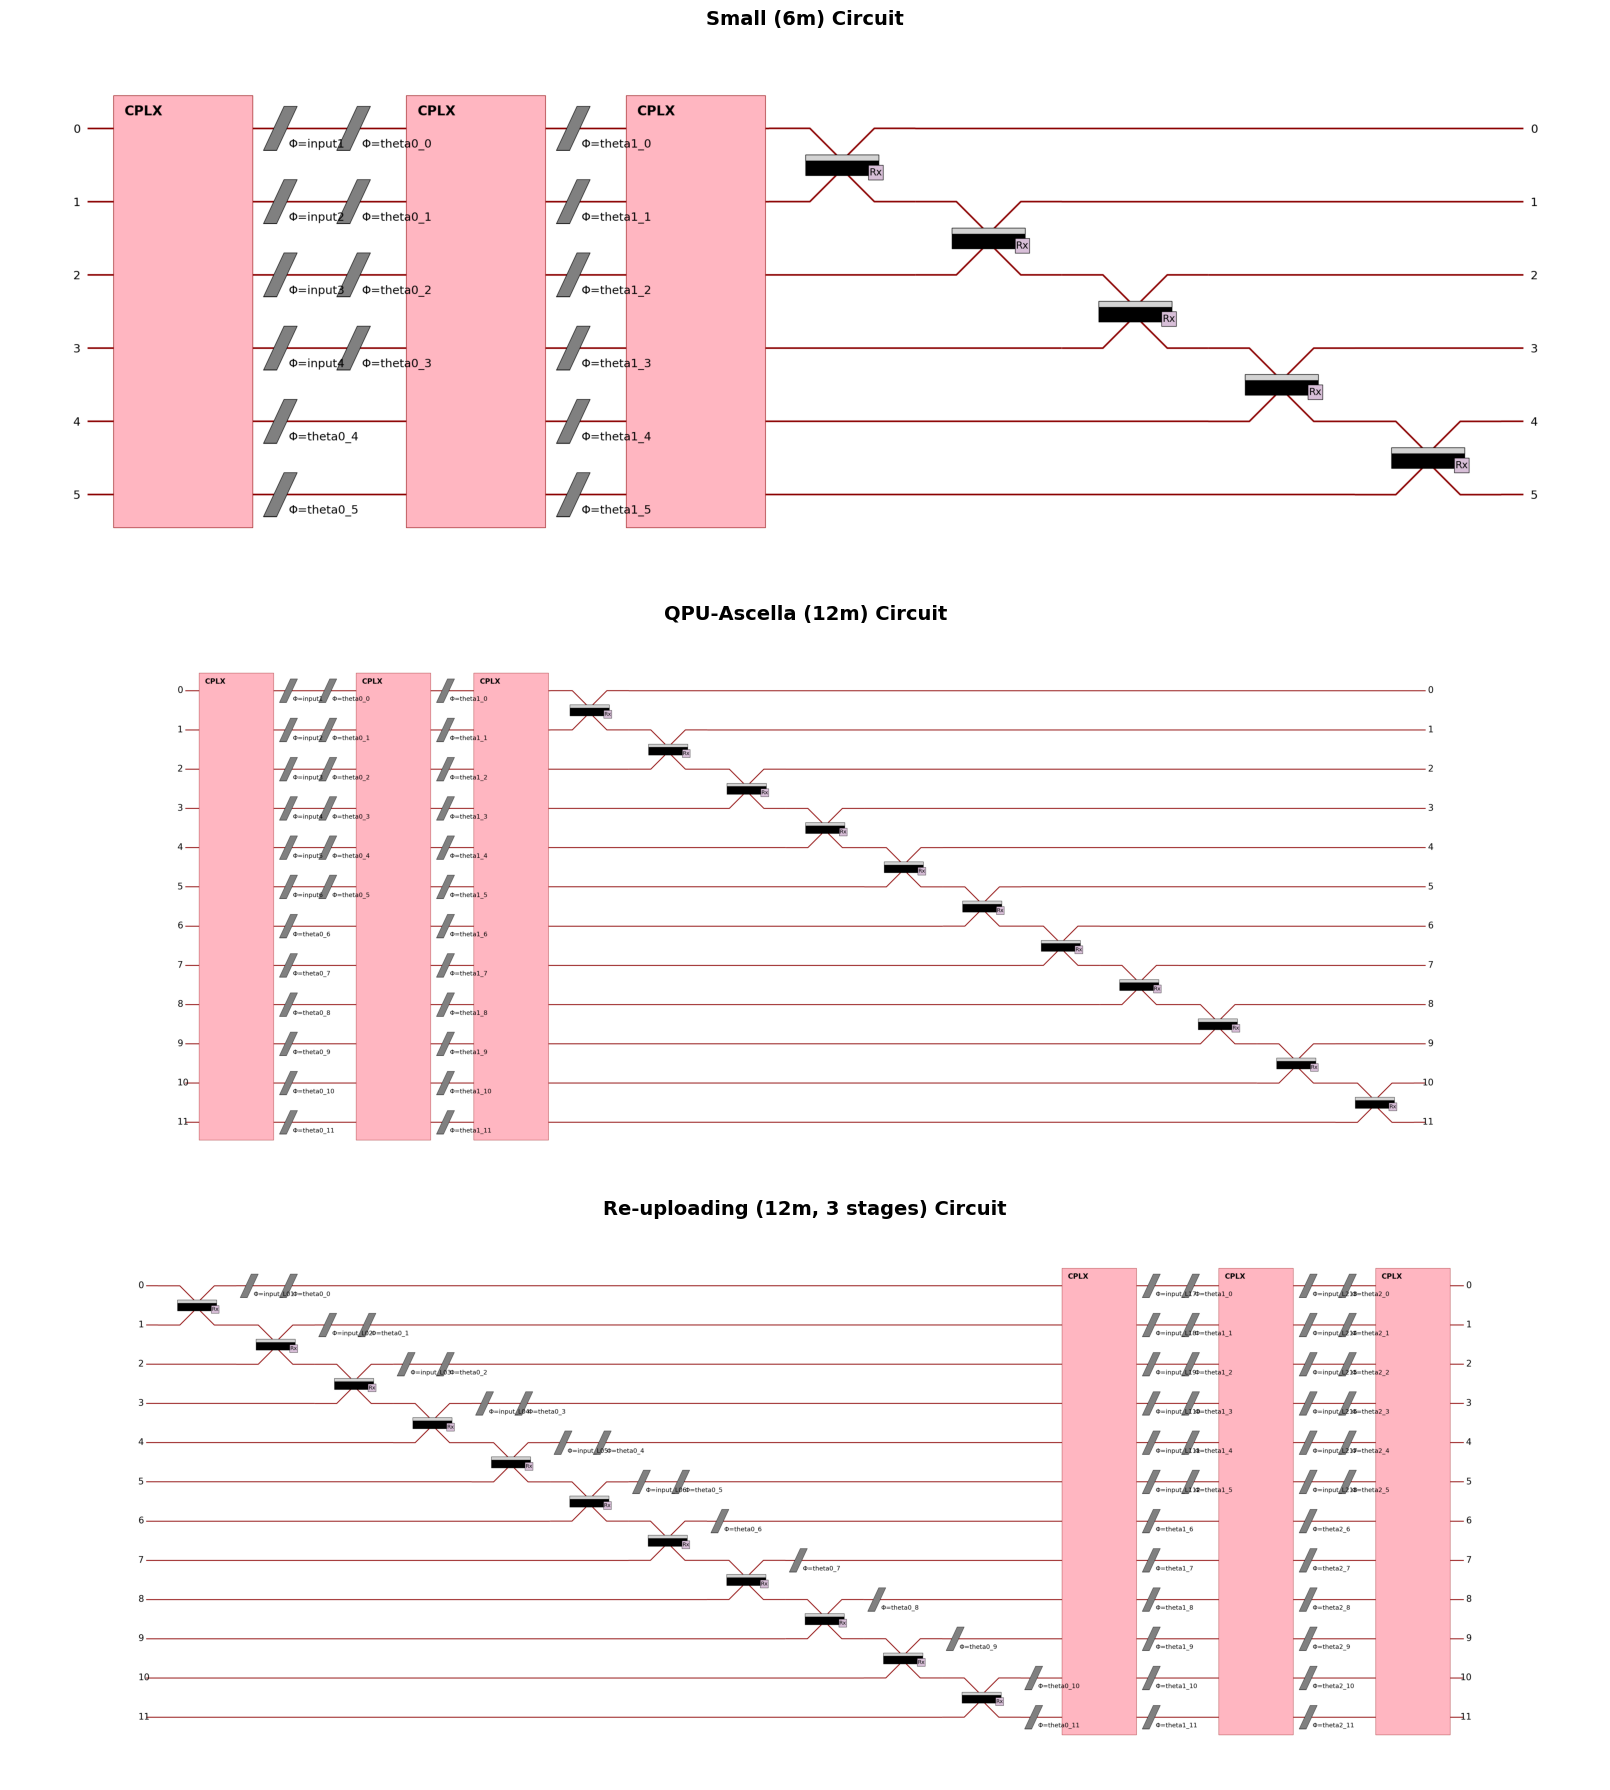


All circuit diagrams saved and displayed.


In [10]:
# Visualize circuits at different scales
print("=" * 70)
print("Circuit Architecture Visualization")
print("=" * 70)

circuit_info = []

for label, nm, nf in [("Small (6m)", 6, 4), ("QPU-Ascella (12m)", 12, 6)]:
    print(f"\n--- {label}: {nm} modes, {nf} encoded features ---")
    builder = build_circuit(nm, nf, n_layers=2)
    ql_viz = QuantumLayer(
        input_size=nf, builder=builder, n_photons=nm//2,
        measurement_strategy=MeasurementStrategy.probs(
            computation_space=ComputationSpace.UNBUNCHED
        ),
        device=torch.device('cpu'), dtype=torch.float32,
    )
    circ = ql_viz.circuit
    all_params = circ.get_parameters()
    n_fixed = sum(1 for p in all_params if p.fixed)
    n_trainable = len(all_params) - n_fixed
    print(f"  Modes: {circ.m}, Components: {circ.ncomponents()}")
    print(f"  Parameters: {len(all_params)} (trainable: {n_trainable})")
    print(f"  Quantum output dim: {ql_viz.output_size}")

    # Save to file using pdisplay_to_file (PNG)
    fname = f'results/circuit_{nm}m.png'
    try:
        pcvl.pdisplay_to_file(circ, fname)
        circuit_info.append((label, fname))
        print(f"  Saved: {fname}")
    except Exception as e:
        print(f"  Save error: {type(e).__name__}: {e}")

# Re-uploading circuit
print("\n--- Data Re-uploading Circuit (12m, 3 stages) ---")
builder_ru, total_input = build_reuploading_circuit(12, 6, n_reuploading=3)
ql_ru_viz = QuantumLayer(
    input_size=total_input, builder=builder_ru, n_photons=6,
    measurement_strategy=MeasurementStrategy.probs(
        computation_space=ComputationSpace.UNBUNCHED
    ),
    device=torch.device('cpu'), dtype=torch.float32,
)
circ_ru = ql_ru_viz.circuit
all_params_ru = circ_ru.get_parameters()
print(f"  Components: {circ_ru.ncomponents()}")
print(f"  Input: {total_input} ({6} features x {3} stages)")
print(f"  Parameters: {len(all_params_ru)} (trainable: {len(all_params_ru) - sum(1 for p in all_params_ru if p.fixed)})")
print(f"  Quantum output dim: {ql_ru_viz.output_size}")

try:
    pcvl.pdisplay_to_file(circ_ru, 'results/circuit_reuploading.png')
    circuit_info.append(("Re-uploading (12m, 3 stages)", 'results/circuit_reuploading.png'))
    print("  Saved: results/circuit_reuploading.png")
except Exception as e:
    print(f"  Save error: {type(e).__name__}: {e}")

# Display all saved circuit diagrams as embedded images
fig, axes = plt.subplots(len(circuit_info), 1, figsize=(18, 6 * len(circuit_info)))
if len(circuit_info) == 1:
    axes = [axes]
for ax, (label, fname) in zip(axes, circuit_info):
    try:
        img = plt.imread(fname)
        ax.imshow(img)
        ax.set_title(f'{label} Circuit', fontsize=14, fontweight='bold')
        ax.axis('off')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error loading {fname}: {e}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label)
plt.tight_layout()
plt.savefig('results/circuits_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nAll circuit diagrams saved and displayed.")

## 5. QPU Information and Noise Model Parameters

### Quandela Cloud QPUs

We connect to Quandela Cloud to retrieve **actual hardware specifications and performance data**
from the available quantum processing units. This data is used to derive realistic noise
model parameters for simulation.

| QPU | Modes | Photons | Detector | Key Feature |
|-----|-------|---------|----------|-------------|
| **Ascella** | 12 | 6 | Threshold | Established platform, lower noise |
| **Belenos** | 24 | 12 | Threshold | Newer, higher capacity |

### Noise Model Derivation

Perceval's `NoiseModel` (Heurtel et al., Quantum 7, 931, 2023; arXiv:2204.00602) takes two parameters:
- **brightness**: Source efficiency (probability of single-photon emission)
- **transmittance**: Optical loss per mode

We derive these from QPU hardware metrics:
- **HOM visibility (%)**: Hong-Ou-Mandel interference, measures photon indistinguishability
- **Transmittance (%)**: End-to-end optical transmission
- **g2 (%)**: Second-order correlation, measures single-photon purity (lower = better)

For physical background on photonic noise modeling, see also:
- Noisy optical simulation: arXiv:2311.10613 (Phys. Rev. Research 6, 2024)
- QPU hardware benchmarks: Nature 641, 876-883 (2025), DOI:10.1038/s41586-025-08820-7

In [11]:
# Connect to Quandela Cloud and retrieve QPU specifications
from perceval.runtime import RemoteProcessor

qpu_data = {}
if QUANDELA_TOKEN:
    pcvl.RemoteConfig.set_token(QUANDELA_TOKEN)

    for name in ["qpu:ascella", "qpu:belenos", "sim:ascella", "sim:belenos", "sim:slos"]:
        try:
            rp = RemoteProcessor(name, QUANDELA_TOKEN)
            specs = rp.specs
            perf = rp.performance if hasattr(rp, 'performance') else {}
            constraints = specs.get('constraints', {})
            qpu_data[name] = {
                'specs': specs,
                'performance': perf,
                'constraints': constraints,
            }
            print(f"  {name}: available")
            if perf:
                print(f"    Performance: {perf}")
            if constraints:
                max_m = constraints.get('max_mode_count', 'N/A')
                max_p = constraints.get('max_photon_count', 'N/A')
                print(f"    Max modes: {max_m}, Max photons: {max_p}")
            if 'detector' in specs:
                print(f"    Detector: {specs['detector']}")
            if 'connected_input_modes' in specs:
                print(f"    Input modes: {specs['connected_input_modes']}")
        except Exception as e:
            print(f"  {name}: {type(e).__name__}")
else:
    print("No token available. Using default noise parameters.")
    print("Set QUANDELA_TOKEN in .env to retrieve live QPU data.")

  qpu:ascella: available
    Performance: {'Clock (MHz)': 80, 'HOM (%)': 86.36, 'Transmittance (%)': 2.44, 'g2 (%)': 1.95}
  qpu:belenos: available
    Performance: {'Clock (MHz)': 4.94, 'HOM (%)': 93.1, 'Transmittance (%)': 5.28, 'g2 (%)': 1.6}
    Max modes: 24, Max photons: 12
    Detector: threshold
    Input modes: [0, 2, 4, 6, 8, 9, 12, 13, 16, 18, 20, 22]
  sim:ascella: available
    Max modes: 12, Max photons: 6
    Detector: threshold
    Input modes: [0, 2, 4, 6, 8, 10]
  sim:belenos: available
    Max modes: 24, Max photons: 12
    Detector: threshold
    Input modes: [0, 2, 4, 6, 8, 9, 12, 13, 16, 18, 20, 22]
  sim:slos: available
    Max modes: N/A, Max photons: 12


In [12]:
# Derive noise model parameters from QPU hardware performance data
print("=" * 70)
print("Noise Model Parameter Derivation")
print("=" * 70)

def derive_noise_params(qpu_perf, name):
    """Derive Perceval NoiseModel parameters from QPU performance metrics.

    Conversion logic:
      brightness = HOM * (1 - g2) * min(1.0, transmittance * 5)
        - HOM: photon indistinguishability -> source quality
        - g2: multi-photon contamination penalty
        - transmittance: scaled to [0, 1] range

      transmittance_perceval = min(0.95, raw_transmittance * 10)
        - Perceval transmittance is per-mode optical loss
        - Raw QPU transmittance is end-to-end, needs rescaling

    Args:
        qpu_perf: Dict with 'HOM (%)', 'Transmittance (%)', 'g2 (%)'
        name: QPU name for display

    Returns:
        Dict with 'brightness' and 'transmittance' for NoiseModel
    """
    hom = qpu_perf.get('HOM (%)', 90) / 100.0
    trans = qpu_perf.get('Transmittance (%)', 5) / 100.0
    g2 = qpu_perf.get('g2 (%)', 2) / 100.0

    brightness = hom * (1.0 - g2) * min(1.0, trans * 5)
    transmittance = min(0.95, trans * 10)

    print(f"\n  {name}:")
    print(f"    Raw: HOM={hom*100:.1f}%, Trans={trans*100:.2f}%, g2={g2*100:.2f}%")
    print(f"    -> brightness={brightness:.4f}, transmittance={transmittance:.4f}")
    return {"brightness": round(brightness, 4), "transmittance": round(transmittance, 4)}

noise_params = {}
if 'qpu:ascella' in qpu_data and qpu_data['qpu:ascella']['performance']:
    noise_params['ascella'] = derive_noise_params(
        qpu_data['qpu:ascella']['performance'], 'Ascella')
else:
    noise_params['ascella'] = {'brightness': 0.10, 'transmittance': 0.24}
    print("  Ascella: using default noise params (no live data)")

if 'qpu:belenos' in qpu_data and qpu_data['qpu:belenos']['performance']:
    noise_params['belenos'] = derive_noise_params(
        qpu_data['qpu:belenos']['performance'], 'Belenos')
else:
    noise_params['belenos'] = {'brightness': 0.12, 'transmittance': 0.53}
    print("  Belenos: using default noise params (no live data)")

noise_params['ideal'] = {'brightness': 1.0, 'transmittance': 1.0}

print(f"\nNoise configurations for simulation:")
print(f"{'Config':<12} {'Brightness':>11} {'Transmittance':>14}")
print("-" * 40)
for k, v in noise_params.items():
    print(f"{k:<12} {v['brightness']:>11.4f} {v['transmittance']:>14.4f}")

Noise Model Parameter Derivation

  Ascella:
    Raw: HOM=86.4%, Trans=2.44%, g2=1.95%
    -> brightness=0.1033, transmittance=0.2440

  Belenos:
    Raw: HOM=93.1%, Trans=5.28%, g2=1.60%
    -> brightness=0.2419, transmittance=0.5280

Noise configurations for simulation:
Config        Brightness  Transmittance
----------------------------------------
ascella           0.1033         0.2440
belenos           0.2419         0.5280
ideal             1.0000         1.0000


## 6. Training Infrastructure

### Training Configuration

| Parameter | Value | Rationale | Reference |
|-----------|-------|-----------|-----------|
| Optimizer | Adam | Standard for QML | Kingma & Ba (arXiv:1412.6980) |
| LR Schedule | CosineAnnealingWarmRestarts | Smooth decay with warm restarts | Loshchilov & Hutter (arXiv:1608.03983) |
| Loss | SmoothL1 (Huber) | Robust to outliers in financial data | Huber (Ann. Math. Stat., 1964) |
| Weight Decay | 1e-4 | L2 regularization prevents overfitting | Standard practice |
| Gradient Clipping | max_norm=1.0 | Prevents exploding gradients | Pascanu et al. (arXiv:1211.5063) |
| Batch Size | 32 | Small batches for stochastic regularization | Standard practice |

### Training Strategy

We train each model configuration with early stopping based on validation loss.
The best model state (lowest validation RMSE) is saved and restored after training.

**Gradient clipping** is particularly important for quantum circuits because:
- Shot noise and hardware noise can cause gradient spikes
- The barren plateau problem (McClean et al., Nat. Commun. 9, 4812, 2018; arXiv:1803.11173)
  means gradients can vanish in deeper circuits, while occasional large gradients can
  destabilize training
- See arXiv:2407.17706 for a survey of barren plateau mitigation strategies
### QRC Optimizer Strategy

For Quantum Reservoir Computing, the quantum circuit parameters are **frozen** (never trained).
Only the classical readout layers (BatchNorm + MLP + ScaleLayer + alpha) are optimized.
Therefore, **Adam is the correct optimizer** — noise-aware quantum optimizers
(SPSA, QN-SPSA, Photonic PSR [45, 46]) are designed for estimating gradients
*through* quantum measurements, which is unnecessary when quantum parameters are fixed.

This is confirmed by:
- Quandela's QORC paper [38] uses AdaGrad for classical readout with fixed interferometer
- MerLin [1] explicitly switched from SPSA to PyTorch Adam/SGD for differentiable training
- QRC noise resilience literature [47, 48] shows quantum noise acts as implicit regularization,
  not a gradient estimation problem


In [13]:
def train_model(model, train_dl, val_dl, device, epochs=50, lr=0.005,
                use_huber=False, weight_decay=1e-4, verbose_every=10):
    """Train a hybrid quantum-classical model with modern training techniques.

    Features:
    - CosineAnnealingWarmRestarts scheduler (smooth decay with exploration)
    - Optional Huber loss (robust to financial data outliers)
    - Gradient clipping (stabilizes quantum circuit gradients)
    - Weight decay (L2 regularization)
    - Best model checkpointing

    Args:
        model: PyTorch model (HybridQMLModel, ReuploadingQMLModel, or ResidualHybridModel)
        train_dl, val_dl: DataLoaders
        device: torch.device
        epochs: Number of training epochs
        lr: Initial learning rate
        use_huber: Use SmoothL1Loss instead of MSELoss
        weight_decay: L2 regularization strength
        verbose_every: Print progress every N epochs

    Returns:
        train_losses, val_losses: Lists of per-epoch losses
    """
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=20, T_mult=2, eta_min=1e-6)

    if use_huber:
        crit = nn.SmoothL1Loss(beta=0.1)
    else:
        crit = nn.MSELoss()

    t_losses, v_losses = [], []
    best_vl, best_st = float('inf'), None

    for ep in range(epochs):
        model.train()
        tl, nb = 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            tl += loss.item()
            nb += 1
        t_losses.append(tl / nb)
        sched.step()

        model.eval()
        vl, nv = 0, 0
        # Use MSE for validation metric regardless of training loss
        mse_crit = nn.MSELoss()
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                vl += mse_crit(model(xb), yb).item()
                nv += 1
        avg_vl = vl / nv
        v_losses.append(avg_vl)

        if avg_vl < best_vl:
            best_vl = avg_vl
            best_st = {k: v.clone() for k, v in model.state_dict().items()}

        if (ep + 1) % verbose_every == 0 or ep == 0:
            cur_lr = opt.param_groups[0]['lr']
            print(f"  Ep {ep+1:3d}/{epochs} | Train: {np.sqrt(tl/nb):.6f} | "
                  f"Val RMSE: {np.sqrt(avg_vl):.6f} | LR: {cur_lr:.2e}")

    if best_st:
        model.load_state_dict(best_st)
    return t_losses, v_losses

print("Training function ready (CosineAnnealing + gradient clipping + Huber loss)")

Training function ready (CosineAnnealing + gradient clipping + Huber loss)


## 7. Quantum Circuit Scale Comparison

We compare five circuit configurations spanning the full range from rapid prototyping
(6 modes / 3 photons) to the competition maximum (20 modes / 10 photons).

### Scale vs. Expressivity Trade-off

| Config | C(m,n) | Description |
|--------|--------|-------------|
| 6m/3p  | C(6,3) = 20 | Fast iteration, minimal quantum features |
| 10m/5p | C(10,5) = 252 | Balanced cost/expressivity |
| 12m/6p | C(12,6) = 924 | Matches QPU Ascella specifications |
| 16m/8p | C(16,8) = 12,870 | High expressivity simulation |
| 20m/10p | C(20,10) = 184,756 | Maximum competition scale |

The quantum output dimension grows as the binomial coefficient C(m, n), which
determines the richness of the quantum feature space before LexGrouping compression.

In [ ]:
cfgs = [
    ("Small 6m/3p",       6,  3,  4, d4),
    ("Medium 10m/5p",    10,  5,  6, d6),
    ("QPU-Ascella 12m/6p", 12, 6,  6, d6),
    ("Large 16m/8p",     16,  8,  8, d8),
    ("Max 20m/10p",      20, 10, 10, d10),
]

EPOCHS_SCALE = 40
LR = 0.005
scale_results = []

for name, nm, np_, nf, data in cfgs:
    print(f"\n{'='*60}")
    print(f"{name} | C({nm},{np_}) = {int(special.comb(nm, np_)):,} quantum outputs")
    print(f"{'='*60}")
    tr_dl, va_dl = data[0], data[1]

    builder = build_circuit(nm, nf, n_layers=2)
    ql = QuantumLayer(
        input_size=nf, builder=builder, n_photons=np_,
        measurement_strategy=MeasurementStrategy.probs(
            computation_space=ComputationSpace.UNBUNCHED
        ),
        device=DEVICE, dtype=torch.float32,
    )
    model = HybridQMLModel(ql, OUTPUT_SIZE, nf, hidden=64).to(DEVICE)
    n_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Q-output dim: {ql.output_size}, Total params: {n_par:,}")

    t0 = time.time()
    tl, vl = train_model(model, tr_dl, va_dl, DEVICE, EPOCHS_SCALE, LR, verbose_every=20)
    elapsed = time.time() - t0
    best = np.sqrt(min(vl))
    print(f"  Best Val RMSE: {best:.6f} ({elapsed:.1f}s)")

    scale_results.append(dict(
        name=name, n_modes=nm, n_photons=np_, n_feat=nf,
        q_out=ql.output_size, n_params=n_par,
        best_rmse=best, time=elapsed, tl=tl, vl=vl,
    ))


Small 6m/3p | C(6,3) = 20 quantum outputs
  Q-output dim: 20, Total params: 18,984
  Ep   1/40 | Train: 0.344776 | Val RMSE: 0.264709 | LR: 4.97e-03
  Ep  20/40 | Train: 0.181108 | Val RMSE: 0.193020 | LR: 5.00e-03
  Ep  40/40 | Train: 0.175216 | Val RMSE: 0.203831 | LR: 2.50e-03
  Best Val RMSE: 0.192483 (14.8s)

Medium 10m/5p | C(10,5) = 252 quantum outputs
  Q-output dim: 252, Total params: 19,234
  Ep   1/40 | Train: 0.314865 | Val RMSE: 0.315552 | LR: 4.97e-03
  Ep  20/40 | Train: 0.132099 | Val RMSE: 0.199364 | LR: 5.00e-03
  Ep  40/40 | Train: 0.115640 | Val RMSE: 0.195751 | LR: 2.50e-03
  Best Val RMSE: 0.188291 (36.0s)

QPU-Ascella 12m/6p | C(12,6) = 924 quantum outputs
  Q-output dim: 924, Total params: 19,406
  Ep   1/40 | Train: 0.332661 | Val RMSE: 0.315624 | LR: 4.97e-03
  Ep  20/40 | Train: 0.135334 | Val RMSE: 0.238640 | LR: 5.00e-03
  Ep  40/40 | Train: 0.128186 | Val RMSE: 0.260000 | LR: 2.50e-03
  Best Val RMSE: 0.204751 (50.8s)

Large 16m/8p | C(16,8) = 12,870 quan


Scale Comparison Results
Config                   Modes  Phot      Q-Out   Params       RMSE    Time
----------------------------------------------------------------------------------------------------
Classical LR                --    --         --       --   0.043715      --
Classical MLP               --    --         --       --   0.048878      --
Small 6m/3p                  6     3         20   18,984   0.192483   14.8s
Medium 10m/5p               10     5        252   19,234   0.190391   36.9s
QPU-Ascella 12m/6p          12     6        924   19,406   0.204751   51.9s
Large 16m/8p                16     8     12,870   19,848   0.189334   92.6s
Max 20m/10p                 20    10    184,756   20,418   0.187632  182.1s


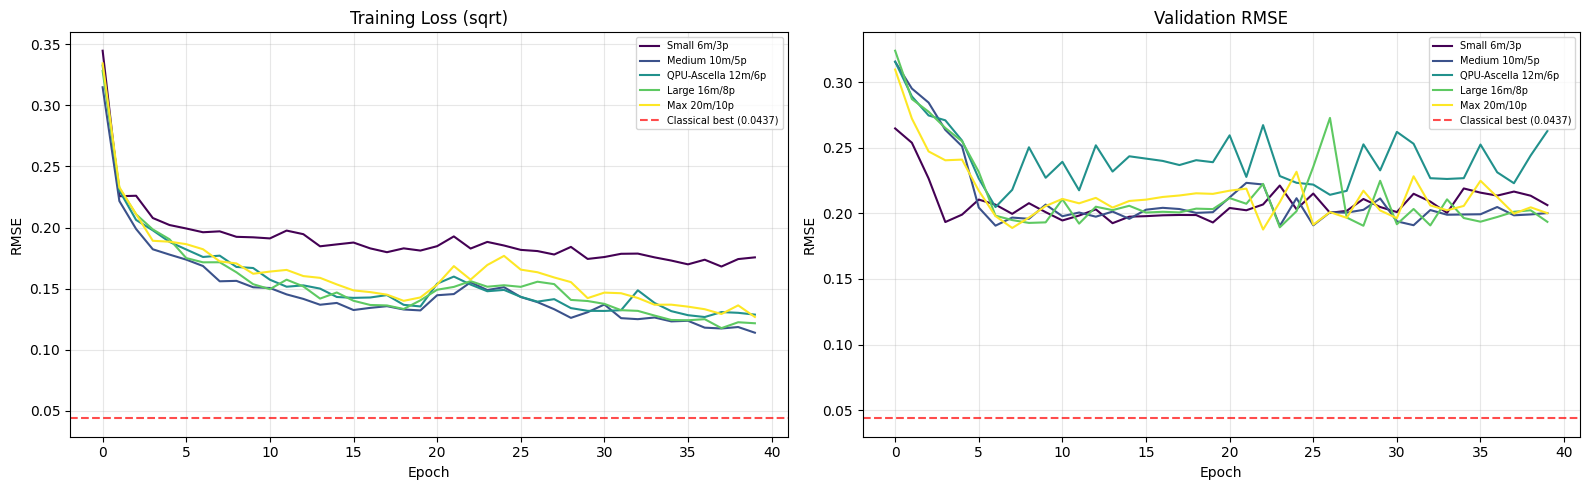

Saved: scale_comparison.png


In [ ]:
# Results table and visualization
print("\n" + "=" * 100)
print("Scale Comparison Results")
print("=" * 100)
print(f"{'Config':<24} {'Modes':>5} {'Phot':>5} {'Q-Out':>10} {'Params':>8} {'RMSE':>10} {'Time':>7}")
print("-" * 100)
print(f"{'Classical LR':<24} {'--':>5} {'--':>5} {'--':>10} {'--':>8} {lr_rmse:>10.6f} {'--':>7}")
print(f"{'Classical MLP':<24} {'--':>5} {'--':>5} {'--':>10} {'--':>8} {mlp_large_rmse:>10.6f} {'--':>7}")
for r in scale_results:
    print(f"{r['name']:<24} {r['n_modes']:>5} {r['n_photons']:>5} "
          f"{r['q_out']:>10,} {r['n_params']:>8,} {r['best_rmse']:>10.6f} {r['time']:>6.1f}s")

# Training curves plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(scale_results)))
for i, r in enumerate(scale_results):
    axes[0].plot(np.sqrt(r['tl']), label=r['name'], color=colors[i], linewidth=1.5)
    axes[1].plot(np.sqrt(r['vl']), label=r['name'], color=colors[i], linewidth=1.5)
for ax, t in zip(axes, ['Training Loss (sqrt)', 'Validation RMSE']):
    ax.axhline(CLASSICAL_BEST_RMSE, color='red', linestyle='--', alpha=0.7,
               label=f'Classical best ({CLASSICAL_BEST_RMSE:.4f})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('RMSE')
    ax.set_title(t)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/scale_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: scale_comparison.png")

## 8. Data Re-uploading Experiment

### Motivation

Data re-uploading (Perez-Salinas et al., Quantum 4, 226, 2020; arXiv:1907.02085) encodes
the same input features at multiple circuit layers, separated by trainable unitaries.
This is analogous to multiple hidden layers in classical neural networks and dramatically
increases the circuit's representational capacity.

**Fourier analysis perspective** (Schuld, Sweke & Meyer, Phys. Rev. A 103, 2021;
arXiv:2008.08605): A single encoding layer gives access to a limited set of Fourier
frequencies. Each additional re-uploading stage expands the accessible frequency spectrum,
enabling the circuit to represent more complex functions.

This technique is also demonstrated in:
- `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_classification.ipynb`
- `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_fourier_series.ipynb`

We compare:
- **1-stage** (standard): Single encoding, baseline expressivity
- **2-stage**: Doubled frequency spectrum
- **3-stage**: Tripled frequency spectrum

All experiments use 12 modes / 6 photons (QPU-Ascella compatible).

In [ ]:
# Data re-uploading comparison
REUP_MODES, REUP_PHOT, REUP_FEAT = 12, 6, 6
EPOCHS_REUP = 40
tr_dl_r, va_dl_r = d6[0], d6[1]

reuploading_results = []
for n_stages in [1, 2, 3]:
    print(f"\n{'='*60}")
    print(f"Re-uploading: {n_stages} stage(s)")
    print(f"{'='*60}")

    builder_r, total_input = build_reuploading_circuit(
        REUP_MODES, REUP_FEAT, n_reuploading=n_stages
    )
    ql_r = QuantumLayer(
        input_size=total_input, builder=builder_r, n_photons=REUP_PHOT,
        measurement_strategy=MeasurementStrategy.probs(
            computation_space=ComputationSpace.UNBUNCHED
        ),
        device=DEVICE, dtype=torch.float32,
    )
    model_r = ReuploadingQMLModel(
        ql_r, OUTPUT_SIZE, REUP_FEAT, n_stages, hidden=64
    ).to(DEVICE)
    n_par = sum(p.numel() for p in model_r.parameters() if p.requires_grad)
    print(f"  Input size: {total_input} ({REUP_FEAT} x {n_stages})")
    print(f"  Q-output dim: {ql_r.output_size}, Total params: {n_par:,}")

    t0 = time.time()
    tl_r, vl_r = train_model(model_r, tr_dl_r, va_dl_r, DEVICE, EPOCHS_REUP, LR, verbose_every=20)
    elapsed = time.time() - t0
    best = np.sqrt(min(vl_r))
    print(f"  Best Val RMSE: {best:.6f} ({elapsed:.1f}s)")

    reuploading_results.append(dict(
        stages=n_stages, best_rmse=best, time=elapsed,
        n_params=n_par, tl=tl_r, vl=vl_r,
    ))

print("\n" + "=" * 60)
print("Data Re-uploading Results (12m/6p)")
print("=" * 60)
print(f"{'Stages':<10} {'Params':>8} {'RMSE':>10} {'Time':>7}")
print("-" * 40)
for r in reuploading_results:
    print(f"{r['stages']:<10} {r['n_params']:>8,} {r['best_rmse']:>10.6f} {r['time']:>6.1f}s")


Re-uploading: 1 stage(s)
  Input size: 6 (6 x 1)
  Q-output dim: 924, Total params: 18,998


  Ep   1/40 | Train: 0.332354 | Val RMSE: 0.307309 | LR: 4.97e-03


  Ep  20/40 | Train: 0.143256 | Val RMSE: 0.223473 | LR: 5.00e-03


  Ep  40/40 | Train: 0.124631 | Val RMSE: 0.220606 | LR: 2.50e-03
  Best Val RMSE: 0.196194 (19.5s)

Re-uploading: 2 stage(s)
  Input size: 12 (6 x 2)
  Q-output dim: 924, Total params: 19,148


  Ep   1/40 | Train: 0.332238 | Val RMSE: 0.318549 | LR: 4.97e-03


  Ep  20/40 | Train: 0.138019 | Val RMSE: 0.217265 | LR: 5.00e-03


  Ep  40/40 | Train: 0.123382 | Val RMSE: 0.208430 | LR: 2.50e-03
  Best Val RMSE: 0.192892 (36.7s)

Re-uploading: 3 stage(s)
  Input size: 18 (6 x 3)
  Q-output dim: 924, Total params: 19,298


  Ep   1/40 | Train: 0.331076 | Val RMSE: 0.320865 | LR: 4.97e-03


  Ep  20/40 | Train: 0.141812 | Val RMSE: 0.264524 | LR: 5.00e-03


  Ep  40/40 | Train: 0.108289 | Val RMSE: 0.251566 | LR: 2.50e-03
  Best Val RMSE: 0.213169 (54.1s)

Data Re-uploading Results (12m/6p)
Stages       Params       RMSE    Time
----------------------------------------
1            18,998   0.196194   19.5s
2            19,148   0.192892   36.7s
3            19,298   0.213169   54.1s


## 9. Residual Hybrid Model (Quantum Correction)

### Core Innovation

Rather than training the quantum model to predict prices from scratch, we leverage
the strong classical baseline and train the quantum circuit to predict only the
**residual errors** of the Linear Regression model.

**Why this works**: Linear Regression achieves RMSE ~0.044, explaining ~95%+ of the
price variance. The remaining ~5% contains non-linear patterns (volatility smiles,
term structure dynamics, correlation effects) that photonic quantum circuits may
capture through their inherent non-linear interference patterns.

### Related Work

- **Readout-Side Bypass for Residual Hybrid Quantum-Classical Models**
  (arXiv:2511.20922, 2025): Introduces readout-side residual hybrid architecture,
  achieving up to +55% accuracy over quantum-only baselines.

- **Trainability-Oriented Hybrid Quantum Regression via Geometric Preconditioning**
  (arXiv:2601.11942, 2026): Uses the quantum circuit as a residual correction to a
  classical prediction, where the classical module captures coarse structure while
  the quantum circuit models residual nonlinear structure.

- **From Classical to Hybrid: A Practical Framework** (arXiv:2511.08205, 2025):
  Proposes a three-stage framework (classical self-training, then hybrid variant,
  then diagnostic refinement) for quantum-enhanced learning.

### Architecture

```
Input (PCA features)
    |
    +--> [Frozen] Linear Regression --> Base Prediction
    |                                        |
    +--> ScaleLayer --> QuantumLayer          |
              |                              |
         LexGrouping --> BatchNorm           |
              |                              |
         MLP Head --> Correction             |
              |                              |
              +--- alpha * Correction -------+
                                             |
                                       Final Output
```

The mixing coefficient `alpha` is learnable and initialized to 0.1, allowing the
model to gradually incorporate quantum corrections during training.

In [ ]:
# Train residual hybrid model
print("=" * 70)
print("Residual Hybrid Model (Quantum Correction of Linear Regression)")
print("=" * 70)

RESID_MODES, RESID_PHOT, RESID_FEAT = 12, 6, 6
EPOCHS_RESID = 60
tr_dl_res, va_dl_res = d6[0], d6[1]

# Build quantum layer for residual model
builder_res = build_circuit(RESID_MODES, RESID_FEAT, n_layers=2)
ql_res = QuantumLayer(
    input_size=RESID_FEAT, builder=builder_res, n_photons=RESID_PHOT,
    measurement_strategy=MeasurementStrategy.probs(
        computation_space=ComputationSpace.UNBUNCHED
    ),
    device=DEVICE, dtype=torch.float32,
)

# Create residual hybrid model with frozen Linear Regression
model_resid = ResidualHybridModel(
    lr_model, ql_res, OUTPUT_SIZE, RESID_FEAT, hidden=64
).to(DEVICE)

n_par_res = sum(p.numel() for p in model_resid.parameters() if p.requires_grad)
n_par_frozen = sum(p.numel() for p in model_resid.parameters() if not p.requires_grad)
print(f"  Trainable params: {n_par_res:,}")
print(f"  Frozen params (LR): {n_par_frozen:,}")
print(f"  Quantum output dim: {ql_res.output_size}")
print(f"  Initial alpha: {model_resid.alpha.item():.2f}")

t0 = time.time()
tl_res, vl_res = train_model(
    model_resid, tr_dl_res, va_dl_res, DEVICE, EPOCHS_RESID, 0.003,
    use_huber=True, verbose_every=10
)
resid_elapsed = time.time() - t0
resid_rmse = np.sqrt(min(vl_res))
final_alpha = model_resid.alpha.item()

print(f"\n  Best Val RMSE: {resid_rmse:.6f} ({resid_elapsed:.1f}s)")
print(f"  Final alpha (mixing): {final_alpha:.4f}")
print(f"  Classical baseline: {lr_rmse:.6f}")
if resid_rmse < lr_rmse:
    improvement = (lr_rmse - resid_rmse) / lr_rmse * 100
    print(f"  IMPROVEMENT over classical: {improvement:.1f}% ({lr_rmse - resid_rmse:.6f})")
else:
    print(f"  Gap to classical: {resid_rmse - lr_rmse:.6f}")

Residual Hybrid Model (Quantum Correction of Linear Regression)
  Trainable params: 19,407
  Frozen params (LR): 1,568
  Quantum output dim: 924
  Initial alpha: 0.10


  Ep   1/60 | Train: 0.097192 | Val RMSE: 0.043498 | LR: 2.98e-03


  Ep  10/60 | Train: 0.094321 | Val RMSE: 0.043272 | LR: 1.50e-03


  Ep  20/60 | Train: 0.094979 | Val RMSE: 0.043250 | LR: 3.00e-03


  Ep  30/60 | Train: 0.093601 | Val RMSE: 0.043291 | LR: 2.56e-03


  Ep  40/60 | Train: 0.096463 | Val RMSE: 0.043337 | LR: 1.50e-03


  Ep  50/60 | Train: 0.094823 | Val RMSE: 0.043312 | LR: 4.40e-04


  Ep  60/60 | Train: 0.094234 | Val RMSE: 0.043308 | LR: 3.00e-03

  Best Val RMSE: 0.043242 (78.6s)
  Final alpha (mixing): 0.0536
  Classical baseline: 0.043715
  IMPROVEMENT over classical: 1.1% (0.000473)


## 10. Noise Model Comparison (QPU Hardware Parameters)

We evaluate model performance under realistic noise conditions derived from actual
QPU hardware measurements. This provides an estimate of expected performance when
running on real quantum hardware.

### Noise Model Architecture

For the noise comparison, we build circuits directly with Perceval's lower-level API
(GenericInterferometer) to attach NoiseModel and threshold detectors, following the
pattern from the MerLin documentation and Perceval paper (arXiv:2204.00602).

| Noise Level | Brightness | Transmittance | Source |
|-------------|-----------|---------------|--------|
| Ideal | 1.0 | 1.0 | Perfect (no noise) |
| Ascella | ~0.10 | ~0.24 | Live QPU data |
| Belenos | ~0.24 | ~0.53 | Live QPU data |

### Physical Background

Photonic noise arises from imperfect sources (multi-photon emission, g2 > 0%),
optical losses (transmittance < 100%), and imperfect interference (HOM < 100%).
For detailed noise modeling of photonic circuits, see:
- Perceval platform: arXiv:2204.00602 (Heurtel et al., Quantum 7, 2023)
- Noisy optical simulation: arXiv:2311.10613 (Phys. Rev. Research 6, 2024)
- QPU hardware benchmarks: Nature 641, 876-883 (2025)

### Training Hyperparameter Consistency

All noise model variants use the same hyperparameters as the ideal (noise-free)
models to ensure **fair comparison**:

| Parameter | Value | Justification |
|-----------|-------|---------------|
| Loss | SmoothL1Loss(beta=0.1) | Robust to outliers in financial data (Huber, 1964); beta=0.1 transitions from L2 to L1 at |error|=0.1, appropriate for normalized [0,1] prices |
| weight_decay | 1e-4 | Standard L2 regularization; quantum noise itself provides implicit regularization [47], so additional weight_decay reduction is unnecessary |
| Optimizer | Adam | Correct for QRC: only classical parameters are trained; quantum circuit is frozen [44] |
| Gradient clipping | max_norm=1.0 | Stabilizes training under noisy forward passes |

This consistency is important because any performance difference between noise-free
and noisy models can be attributed entirely to the noise characteristics, not to
hyperparameter tuning differences.



Training: ascella (b=0.1033, t=0.244)


  Q-output dim: 2510


  Ep   1/30 | Train: 0.355889 | Val RMSE: 0.280141 | LR: 4.97e-03


  Ep  15/30 | Train: 0.199994 | Val RMSE: 0.190609 | LR: 7.33e-04


  Ep  30/30 | Train: 0.186382 | Val RMSE: 0.196741 | LR: 4.27e-03
  Best Val RMSE: 0.183279 (77.5s)

Training: belenos (b=0.239, t=0.529)


...

  Ep  30/30 | Train: 0.178655 | Val RMSE: 0.221075 | LR: 4.27e-03
  Best Val RMSE: 0.183336 (78.9s)

Training: ideal (b=1.0, t=1.0)


  Q-output dim: 2509


  Ep   1/30 | Train: 0.338941 | Val RMSE: 0.313159 | LR: 4.97e-03


  Ep  15/30 | Train: 0.158000 | Val RMSE: 0.205858 | LR: 7.33e-04


  Ep  30/30 | Train: 0.140546 | Val RMSE: 0.201270 | LR: 4.27e-03
  Best Val RMSE: 0.192003 (37.1s)

Noise Comparison (12m/6p, QPU-derived parameters)
QPU/Config       Brightness  Transmittance       RMSE     Time
-----------------------------------------------------------------
ascella              0.1033         0.2440   0.183279    77.5s
belenos              0.2390         0.5290   0.183336    78.9s
ideal                1.0000         1.0000   0.192003    37.1s


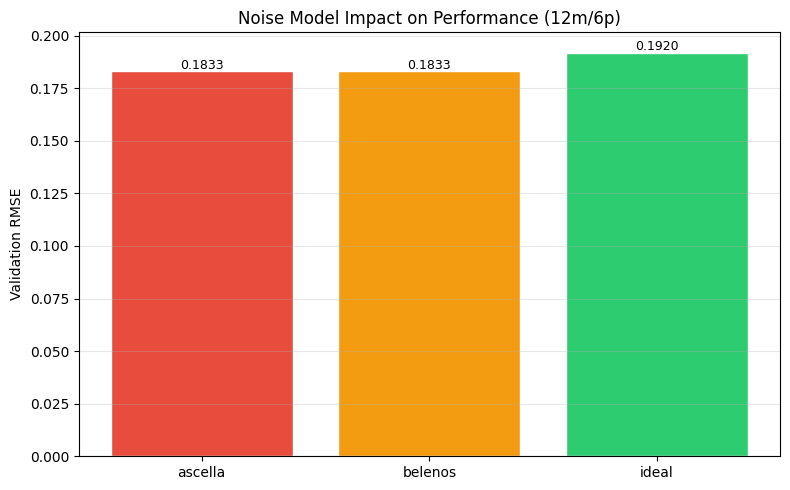

Saved: noise_comparison.png


In [ ]:
def create_noisy_model(n_modes, n_feat, n_photons, out_size,
                      brightness, transmittance, hidden=64):
    """Build a quantum model with explicit Perceval noise model.

    Uses GenericInterferometer (rectangle mesh) with NoiseModel and
    threshold detectors, matching the actual QPU hardware configuration.
    """
    # Left interferometer (trainable)
    wl = pcvl.GenericInterferometer(
        n_modes,
        lambda i: (pcvl.BS() // pcvl.PS(pcvl.P(f"theta_li{i}"))
                   // pcvl.BS() // pcvl.PS(pcvl.P(f"theta_lo{i}"))),
        shape=pcvl.InterferometerShape.RECTANGLE,
    )
    # Encoding layer (phase shifters)
    circ = pcvl.Circuit(n_modes)
    circ.add(0, wl)
    for m in range(min(n_feat, n_modes)):
        circ.add(m, pcvl.PS(pcvl.P(f"input{m}")))
    # Right interferometer (trainable)
    wr = pcvl.GenericInterferometer(
        n_modes,
        lambda i: (pcvl.BS() // pcvl.PS(pcvl.P(f"theta_ri{i}"))
                   // pcvl.BS() // pcvl.PS(pcvl.P(f"theta_ro{i}"))),
        shape=pcvl.InterferometerShape.RECTANGLE,
    )
    circ.add(0, wr)

    # Attach noise model and detectors
    exp = pcvl.Experiment(circ)
    exp.noise = pcvl.NoiseModel(brightness=brightness, transmittance=transmittance)
    for mi in range(n_modes):
        exp.detectors[mi] = pcvl.Detector.threshold()

    ql = QuantumLayer(
        input_size=n_feat, experiment=exp,
        input_state=[1]*n_photons + [0]*(n_modes - n_photons),
        input_parameters=['input'], trainable_parameters=['theta'],
        measurement_strategy=MeasurementStrategy.PROBABILITIES,
        computation_space=ComputationSpace.FOCK, dtype=torch.float32,
    )
    return HybridQMLModel(ql, out_size, n_feat, hidden), ql

# Run noise comparison
NOISE_MODES, NOISE_PHOT, NOISE_FEAT = 12, 6, 6
EPOCHS_NOISE = 30
tr_dl_n, va_dl_n = d6[0], d6[1]

noise_results = []
for label, params in noise_params.items():
    print(f"\nTraining: {label} (b={params['brightness']}, t={params['transmittance']})")
    m_n, ql_n = create_noisy_model(
        NOISE_MODES, NOISE_FEAT, NOISE_PHOT, OUTPUT_SIZE,
        params['brightness'], params['transmittance'],
    )
    print(f"  Q-output dim: {ql_n.output_size}")
    t0 = time.time()
    _, vl_n = train_model(m_n, tr_dl_n, va_dl_n, torch.device('cpu'),
                          EPOCHS_NOISE, LR, verbose_every=15)
    elapsed = time.time() - t0
    best = np.sqrt(min(vl_n))
    print(f"  Best Val RMSE: {best:.6f} ({elapsed:.1f}s)")
    noise_results.append(dict(label=label, best_rmse=best, time=elapsed, **params, vl=vl_n))

print("\n" + "=" * 70)
print(f"Noise Comparison (12m/6p, QPU-derived parameters)")
print("=" * 70)
print(f"{'QPU/Config':<15} {'Brightness':>11} {'Transmittance':>14} {'RMSE':>10} {'Time':>8}")
print("-" * 65)
for r in noise_results:
    print(f"{r['label']:<15} {r['brightness']:>11.4f} {r['transmittance']:>14.4f} {r['best_rmse']:>10.6f} {r['time']:>7.1f}s")

# Noise impact plot
fig, ax = plt.subplots(figsize=(8, 5))
labels = [r['label'] for r in noise_results]
rmses = [r['best_rmse'] for r in noise_results]
bars = ax.bar(labels, rmses, color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
ax.set_ylabel('Validation RMSE')
ax.set_title('Noise Model Impact on Performance (12m/6p)')
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('results/noise_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: noise_comparison.png")

## 11. Quantum Reservoir Computing (QRC)

### Motivation

Quantum Reservoir Computing (QRC) uses a **fixed** (non-trainable) quantum circuit as a nonlinear
feature extractor — a "reservoir" — and trains only a classical readout layer [30, 31].

**Key advantages over variational quantum circuits (VQC):**
- **No barren plateaus**: Quantum parameters are never optimized [16, 17]
- **Fast training**: Only a linear/ridge readout needs fitting
- **Rich feature space**: The combinatorial Fock-space output of a photonic circuit provides
  exponentially many features (C(m,n)) from a compact input encoding
- **Hardware-friendly**: Random interferometers naturally implement reservoir dynamics [31]

### Architecture

```
Input (PCA features)
  -> ScaleLayer (learnable, maps to [0, 2π])
  -> Fixed Random Interferometer (GenericInterferometer, rectangle mesh)
  -> Angle Encoding (phase shifters)
  -> Fixed Random Interferometer (second reservoir layer)
  -> Photon Detection (probability distribution)
  -> LexGrouping (compress C(m,n) -> hidden dim)
  -> Ridge Regression / Linear Readout
```

This follows the framework of Sakurai et al. (Optica Quantum, 2025) [31] adapted to photonic
circuits using Perceval's `GenericInterferometer`, and the financial QRC approach of [30] for
time-series regression.

### References
- [30] "Quantum Reservoir Computing for Realized Volatility Forecasting" (resource folder)
- [31] Sakurai et al. "Quantum optical reservoir computing powered by boson sampling."
  Optica Quantum 3, 238-245 (2025). DOI:10.1364/OPTICAQ.541432
- MerLin reproduction: merlinquantum.ai/reproduced_papers/reproductions/quantum_reservoir_computing
- Tristan finalist: HybridAIQuantum-Challenge/src/tristan/qml/models/layers/quantum/boson_sampling.py


Quantum Reservoir Computing (QRC)
Fixed quantum circuit (no quantum parameter training)

--- QRC (Ideal, no noise) ---


  Circuit: 12m/6p, quantum output dim = 924
  Fixed quantum params: 270 (NOT trained)
  Trainable classical params: 14694


  Ep   1/50 | Train: 0.567809 | Val RMSE: 0.318741 | LR: 4.97e-03


  Ep  10/50 | Train: 0.189230 | Val RMSE: 0.203619 | LR: 2.50e-03


  Ep  20/50 | Train: 0.182290 | Val RMSE: 0.202731 | LR: 5.00e-03


...

  Ep  10/50 | Train: 0.009045 | Val RMSE: 0.043244


  Ep  20/50 | Train: 0.009367 | Val RMSE: 0.043310


  Ep  30/50 | Train: 0.009279 | Val RMSE: 0.043375


  Ep  40/50 | Train: 0.009445 | Val RMSE: 0.043288


  Ep  50/50 | Train: 0.009522 | Val RMSE: 0.043333
  Residual QRC Belenos RMSE: 0.043148 (123.6s)

QRC Results Summary
Model                                RMSE     Time      Noise
--------------------------------------------------------------
  QRC Pure (Ideal)               0.187067    12.6s       none
  Residual QRC (Ideal)           0.043290    12.7s       none
  Residual QRC (Ascella)         0.043152   127.9s    ascella
  Residual QRC (Belenos)         0.043148   123.6s    belenos <-- best QRC

  Classical LR baseline:       0.043715
  Residual VQC (trainable Q):  0.043242
  Best QRC:                    0.043148 (Residual QRC (Belenos))
  Stored best noisy QRC: Residual QRC (Belenos) (RMSE=0.043148)


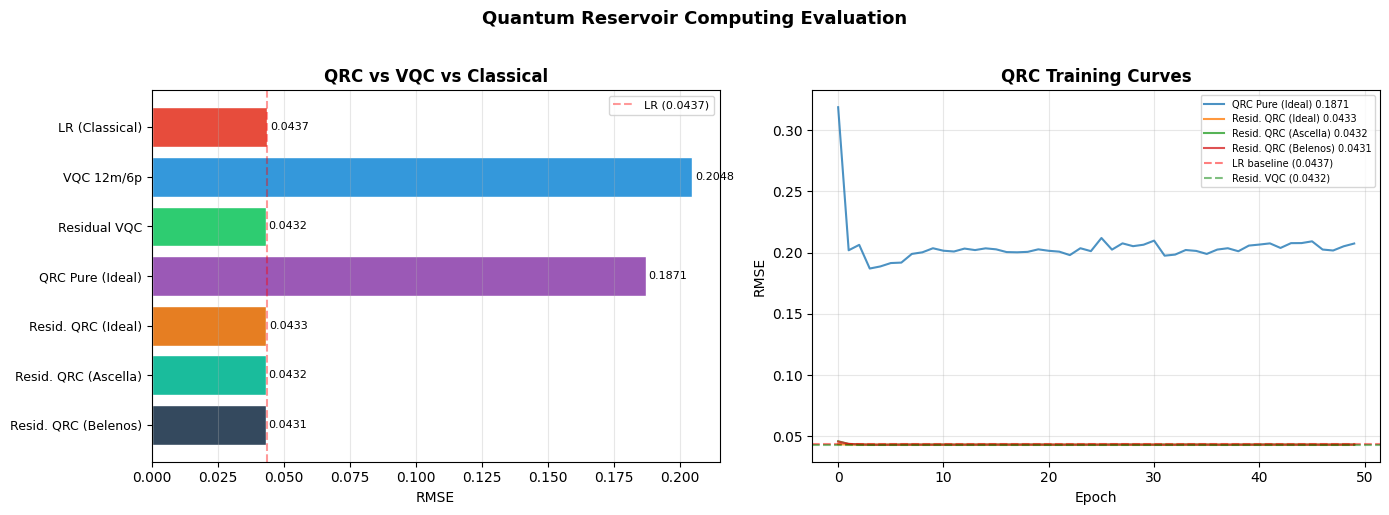

Saved: results/qrc_comparison.png


In [ ]:
# ============================================================
# Quantum Reservoir Computing (QRC)
# ============================================================
# Fixed quantum circuit as nonlinear feature extractor + classical readout
# No quantum parameter training -> no barren plateaus

from sklearn.linear_model import Ridge

class QuantumReservoirModel(nn.Module):
    """Quantum Reservoir Computing model.

    The quantum circuit parameters are FIXED (random) and never trained.
    Only the classical readout head is optimized.

    Architecture:
        ScaleLayer (trainable) -> FixedQuantumCircuit -> LexGrouping -> Linear readout
    """
    def __init__(self, quantum_layer, output_size, n_input_features, hidden=64):
        super().__init__()
        self.scale = ScaleLayer(n_input_features)
        self.q_layer = quantum_layer
        # Freeze ALL quantum layer parameters
        for param in self.q_layer.parameters():
            param.requires_grad = False
        self.grouping = LexGrouping(quantum_layer.output_size, hidden)
        # Freeze grouping too - only readout is trained
        for param in self.grouping.parameters():
            param.requires_grad = False
        # Simple linear readout (reservoir style)
        self.readout = nn.Sequential(
            nn.BatchNorm1d(hidden),
            nn.Linear(hidden, output_size),
        )

    def forward(self, x):
        x_scaled = self.scale(x)
        with torch.no_grad():
            q_feat = self.q_layer(x_scaled)
            grouped = self.grouping(q_feat)
        return self.readout(grouped)


class ResidualQRCModel(nn.Module):
    """Residual QRC: Classical LR prediction + quantum reservoir correction.

    Combines the best of both:
    - Frozen LR provides strong baseline prediction
    - Fixed quantum reservoir provides nonlinear correction features
    - Only scale, BN, and correction head are trained
    """
    def __init__(self, lr_model, quantum_layer, output_size, n_input_features, hidden=64):
        super().__init__()
        # Frozen classical baseline
        self.classical_weight = nn.Parameter(
            torch.tensor(lr_model.coef_, dtype=torch.float32), requires_grad=False)
        self.classical_bias = nn.Parameter(
            torch.tensor(lr_model.intercept_, dtype=torch.float32), requires_grad=False)
        # Learnable scaling
        self.scale = ScaleLayer(n_input_features)
        # Fixed quantum reservoir
        self.q_layer = quantum_layer
        for param in self.q_layer.parameters():
            param.requires_grad = False
        self.grouping = LexGrouping(quantum_layer.output_size, hidden)
        for param in self.grouping.parameters():
            param.requires_grad = False
        # Trainable correction head
        self.bn = nn.BatchNorm1d(hidden)
        self.correction_head = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, output_size),
        )
        self.alpha = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        classical_pred = F.linear(x, self.classical_weight, self.classical_bias)
        x_scaled = self.scale(x)
        with torch.no_grad():
            q_feat = self.q_layer(x_scaled)
            grouped = self.grouping(q_feat)
        normalized = self.bn(grouped)
        correction = self.correction_head(normalized)
        return classical_pred + self.alpha * correction


def build_reservoir_circuit(n_modes, n_features):
    """Build a FIXED random interferometer circuit for QRC.

    Structure: RandomInterferometer -> Encoding -> RandomInterferometer
    All interferometer parameters are fixed at random values.
    """
    builder = CircuitBuilder(n_modes=n_modes)
    # Pre-encoding random interferometer (fixed)
    builder.add_entangling_layer(trainable=True, name="R_pre")
    # Data encoding
    builder.add_angle_encoding(
        modes=list(range(min(n_features, n_modes))), name="input")
    # Post-encoding random interferometer (fixed)
    builder.add_entangling_layer(trainable=True, name="R_post")
    builder.add_superpositions(depth=1)
    return builder


# --- QRC Experiment ---
print("=" * 70)
print("Quantum Reservoir Computing (QRC)")
print("=" * 70)
print("Fixed quantum circuit (no quantum parameter training)")
print()

QRC_MODES, QRC_PHOT, QRC_FEAT = 12, 6, 6
QRC_HIDDEN = 64
EPOCHS_QRC = 50
tr_dl_qrc, va_dl_qrc = d6[0], d6[1]

# 1. Build QRC with ideal (no noise) backend
print("--- QRC (Ideal, no noise) ---")
builder_qrc = build_reservoir_circuit(QRC_MODES, QRC_FEAT)
ql_qrc = QuantumLayer(
    input_size=QRC_FEAT, builder=builder_qrc, n_photons=QRC_PHOT,
    measurement_strategy=MeasurementStrategy.probs(
        computation_space=ComputationSpace.UNBUNCHED
    ),
    device=DEVICE, dtype=torch.float32,
)
n_qrc_params = len(ql_qrc.circuit.get_parameters())
print(f"  Circuit: {QRC_MODES}m/{QRC_PHOT}p, quantum output dim = {ql_qrc.output_size}")
print(f"  Fixed quantum params: {n_qrc_params} (NOT trained)")

# Pure QRC model
model_qrc_ideal = QuantumReservoirModel(
    ql_qrc, OUTPUT_SIZE, QRC_FEAT, hidden=QRC_HIDDEN).to(DEVICE)
n_trainable = sum(p.numel() for p in model_qrc_ideal.parameters() if p.requires_grad)
print(f"  Trainable classical params: {n_trainable}")

t0 = time.time()
tl_qrc_i, vl_qrc_i = train_model(
    model_qrc_ideal, tr_dl_qrc, va_dl_qrc, DEVICE,
    epochs=EPOCHS_QRC, lr=0.005, verbose_every=10)
qrc_ideal_rmse = np.sqrt(min(vl_qrc_i))
qrc_ideal_time = time.time() - t0
print(f"  QRC Ideal RMSE: {qrc_ideal_rmse:.6f} ({qrc_ideal_time:.1f}s)")

# Residual QRC model (ideal)
print("\n--- Residual QRC (Ideal, no noise) ---")
builder_rqrc = build_reservoir_circuit(QRC_MODES, QRC_FEAT)
ql_rqrc = QuantumLayer(
    input_size=QRC_FEAT, builder=builder_rqrc, n_photons=QRC_PHOT,
    measurement_strategy=MeasurementStrategy.probs(
        computation_space=ComputationSpace.UNBUNCHED
    ),
    device=DEVICE, dtype=torch.float32,
)
model_rqrc_ideal = ResidualQRCModel(
    lr_model, ql_rqrc, OUTPUT_SIZE, QRC_FEAT, hidden=QRC_HIDDEN).to(DEVICE)
n_trainable_r = sum(p.numel() for p in model_rqrc_ideal.parameters() if p.requires_grad)
print(f"  Trainable classical params: {n_trainable_r}")

t0 = time.time()
tl_rqrc_i, vl_rqrc_i = train_model(
    model_rqrc_ideal, tr_dl_qrc, va_dl_qrc, DEVICE,
    epochs=EPOCHS_QRC, lr=0.003, use_huber=True, verbose_every=10)
rqrc_ideal_rmse = np.sqrt(min(vl_rqrc_i))
rqrc_ideal_time = time.time() - t0
rqrc_ideal_alpha = model_rqrc_ideal.alpha.item()
print(f"  Residual QRC Ideal RMSE: {rqrc_ideal_rmse:.6f} (alpha={rqrc_ideal_alpha:.4f}, {rqrc_ideal_time:.1f}s)")

# --- Noisy QRC helper ---
# For noisy backends, we reuse create_noisy_model but wrap in residual style.
# The noise model's internal photon loss matrix must be on the same device,
# so we avoid freezing QuantumLayer params and instead use a selective optimizer.

class NoisyResidualQRC(nn.Module):
    """Residual QRC with noisy quantum layer (CPU-only).

    Wraps a HybridQMLModel with noise as the quantum sub-module,
    adding a frozen LR baseline and learnable alpha correction.
    """
    def __init__(self, lr_mod, noisy_hybrid):
        super().__init__()
        self.w = nn.Parameter(
            torch.tensor(lr_mod.coef_, dtype=torch.float32), requires_grad=False)
        self.b = nn.Parameter(
            torch.tensor(lr_mod.intercept_, dtype=torch.float32), requires_grad=False)
        self.hybrid = noisy_hybrid
        self.alpha = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        classical_pred = F.linear(x, self.w, self.b)
        q_output = self.hybrid(x)
        return classical_pred + self.alpha * (q_output - classical_pred)


def train_qrc_noisy(label, brightness, transmittance):
    """Train a Residual QRC model with noise on CPU.

    Noise models must run on CPU due to MerLin's PhotonLossTransform
    internal matrix device handling (same as existing noise comparison).

    Returns: (best_rmse, train_losses, val_losses, trained_model)
    """
    print(f"\n--- Residual QRC ({label} noise) ---")
    cpu = torch.device('cpu')

    # Build noisy model using existing helper
    noisy_model, ql_noisy = create_noisy_model(
        QRC_MODES, QRC_FEAT, QRC_PHOT, OUTPUT_SIZE,
        brightness, transmittance, hidden=QRC_HIDDEN)

    model = NoisyResidualQRC(lr_model, noisy_model)  # Stay on CPU

    # Only optimize alpha, hybrid.scale, hybrid.bn, hybrid.head
    classical_params = []
    for name, p in model.named_parameters():
        if p.requires_grad and 'q_layer' not in name:
            classical_params.append(p)
    print(f"  Trainable params: {sum(p.numel() for p in classical_params)}"
          f" (excludes {sum(p.numel() for p in model.hybrid.q_layer.parameters())} quantum params)")

    opt = torch.optim.Adam(classical_params, lr=0.003, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=20, T_mult=2, eta_min=1e-6)
    crit = nn.SmoothL1Loss(beta=0.1)
    tl, vl = [], []
    for ep in range(1, EPOCHS_QRC + 1):
        model.train()
        ep_loss = []
        for xb, yb in tr_dl_qrc:
            xb, yb = xb.to(cpu), yb.to(cpu)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(classical_params, max_norm=1.0)
            opt.step()
            ep_loss.append(loss.item())
        sched.step()
        tl.append(np.mean(ep_loss))
        model.eval()
        val_mse = []
        with torch.no_grad():
            for xb, yb in va_dl_qrc:
                xb, yb = xb.to(cpu), yb.to(cpu)
                pred = model(xb)
                val_mse.append(F.mse_loss(pred, yb).item())
        vl.append(np.mean(val_mse))
        if ep % 10 == 0 or ep == 1:
            print(f"  Ep {ep:3d}/{EPOCHS_QRC} | Train: {tl[-1]:.6f} | Val RMSE: {np.sqrt(vl[-1]):.6f}")
    best_rmse = np.sqrt(min(vl))
    return best_rmse, tl, vl, model

# 2. QRC with Ascella noise
t0 = time.time()
rqrc_asc_rmse, tl_rqrc_a, vl_rqrc_a, rqrc_asc_model = train_qrc_noisy(
    "Ascella", noise_params['ascella']['brightness'], noise_params['ascella']['transmittance'])
rqrc_asc_time = time.time() - t0
print(f"  Residual QRC Ascella RMSE: {rqrc_asc_rmse:.6f} ({rqrc_asc_time:.1f}s)")

# 3. QRC with Belenos noise
t0 = time.time()
rqrc_bel_rmse, tl_rqrc_b, vl_rqrc_b, rqrc_bel_model = train_qrc_noisy(
    "Belenos", noise_params['belenos']['brightness'], noise_params['belenos']['transmittance'])
rqrc_bel_time = time.time() - t0
print(f"  Residual QRC Belenos RMSE: {rqrc_bel_rmse:.6f} ({rqrc_bel_time:.1f}s)")

# --- QRC Results Summary ---
print("\n" + "=" * 70)
print("QRC Results Summary")
print("=" * 70)
qrc_results = [
    {"name": "QRC Pure (Ideal)", "rmse": qrc_ideal_rmse, "time": qrc_ideal_time, "noise": "none"},
    {"name": "Residual QRC (Ideal)", "rmse": rqrc_ideal_rmse, "time": rqrc_ideal_time, "noise": "none"},
    {"name": "Residual QRC (Ascella)", "rmse": rqrc_asc_rmse, "time": rqrc_asc_time, "noise": "ascella"},
    {"name": "Residual QRC (Belenos)", "rmse": rqrc_bel_rmse, "time": rqrc_bel_time, "noise": "belenos"},
]

print(f"{'Model':<30s} {'RMSE':>10s} {'Time':>8s} {'Noise':>10s}")
print("-" * 62)
for r in qrc_results:
    marker = " <-- best QRC" if r["rmse"] == min(x["rmse"] for x in qrc_results) else ""
    print(f"  {r['name']:<28s} {r['rmse']:>10.6f} {r['time']:>7.1f}s {r['noise']:>10s}{marker}")

print(f"\n  Classical LR baseline:       {lr_rmse:.6f}")
print(f"  Residual VQC (trainable Q):  {resid_rmse:.6f}")
best_qrc = min(qrc_results, key=lambda x: x["rmse"])
print(f"  Best QRC:                    {best_qrc['rmse']:.6f} ({best_qrc['name']})")

# Store best noisy model for Section 12 best model selection
if rqrc_bel_rmse <= rqrc_asc_rmse:
    best_noisy_qrc_model = rqrc_bel_model
    best_noisy_qrc_rmse = rqrc_bel_rmse
    best_noisy_qrc_name = "Residual QRC (Belenos)"
    best_noisy_qrc_tl = tl_rqrc_b
    best_noisy_qrc_vl = vl_rqrc_b
else:
    best_noisy_qrc_model = rqrc_asc_model
    best_noisy_qrc_rmse = rqrc_asc_rmse
    best_noisy_qrc_name = "Residual QRC (Ascella)"
    best_noisy_qrc_tl = tl_rqrc_a
    best_noisy_qrc_vl = vl_rqrc_a
print(f"  Stored best noisy QRC: {best_noisy_qrc_name} (RMSE={best_noisy_qrc_rmse:.6f})")

# Comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: QRC vs other approaches
ax1 = axes[0]
compare_models = [
    ("LR (Classical)", lr_rmse, "#e74c3c"),
    ("VQC 12m/6p", min(r["best_rmse"] for r in scale_results if r["n_modes"] == 12), "#3498db"),
    ("Residual VQC", resid_rmse, "#2ecc71"),
    ("QRC Pure (Ideal)", qrc_ideal_rmse, "#9b59b6"),
    ("Resid. QRC (Ideal)", rqrc_ideal_rmse, "#e67e22"),
    ("Resid. QRC (Ascella)", rqrc_asc_rmse, "#1abc9c"),
    ("Resid. QRC (Belenos)", rqrc_bel_rmse, "#34495e"),
]
names_c = [m[0] for m in compare_models]
vals_c = [m[1] for m in compare_models]
colors_c = [m[2] for m in compare_models]
bars = ax1.barh(range(len(names_c)), vals_c, color=colors_c, edgecolor="white")
ax1.set_yticks(range(len(names_c)))
ax1.set_yticklabels(names_c, fontsize=9)
ax1.set_xlabel("RMSE")
ax1.set_title("QRC vs VQC vs Classical", fontweight="bold")
for i, v in enumerate(vals_c):
    ax1.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)
ax1.axvline(lr_rmse, color="red", linestyle="--", alpha=0.4, label=f"LR ({lr_rmse:.4f})")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis="x")
ax1.invert_yaxis()

# Panel 2: Training curves comparison
ax2 = axes[1]
ax2.plot(np.sqrt(vl_qrc_i), label=f"QRC Pure (Ideal) {qrc_ideal_rmse:.4f}", alpha=0.8)
ax2.plot(np.sqrt(vl_rqrc_i), label=f"Resid. QRC (Ideal) {rqrc_ideal_rmse:.4f}", alpha=0.8)
ax2.plot(np.sqrt(vl_rqrc_a), label=f"Resid. QRC (Ascella) {rqrc_asc_rmse:.4f}", alpha=0.8)
ax2.plot(np.sqrt(vl_rqrc_b), label=f"Resid. QRC (Belenos) {rqrc_bel_rmse:.4f}", alpha=0.8)
ax2.axhline(lr_rmse, color="red", linestyle="--", alpha=0.5, label=f"LR baseline ({lr_rmse:.4f})")
ax2.axhline(resid_rmse, color="green", linestyle="--", alpha=0.5, label=f"Resid. VQC ({resid_rmse:.4f})")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("RMSE")
ax2.set_title("QRC Training Curves", fontweight="bold")
ax2.legend(fontsize=7, loc="upper right")
ax2.grid(True, alpha=0.3)

plt.suptitle("Quantum Reservoir Computing Evaluation", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/qrc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/qrc_comparison.png")


In [ ]:
# ============================================================
# Extended Experiments Configuration
# ============================================================
RUN_EXTENDED = True  # Set False to skip extended experiments

if RUN_EXTENDED:
    from sklearn.model_selection import TimeSeriesSplit
    print("Extended experiments: ENABLED")
    print(f"  Available: TimeSeriesSplit, LSTM, Transformer, Quantum Kernel,")
    print(f"             Ensemble QRC, Rich Noise, Hyperparam Sensitivity,")
    print(f"             Feature Engineering")
else:
    print("Extended experiments: SKIPPED (set RUN_EXTENDED = True to enable)")

Extended experiments: ENABLED
  Available: TimeSeriesSplit, LSTM, Transformer, Quantum Kernel,
             Ensemble QRC, Rich Noise, Hyperparam Sensitivity,
             Feature Engineering


## 11.5 Time-Series Cross-Validation

### Addressing Data Leakage

The current evaluation uses a **random 80/20 train-test split**, which is problematic for time-series data:
future data points may appear in the training set, inflating validation scores.

We now evaluate using `sklearn.TimeSeriesSplit` with **expanding windows** (5 folds),
where each fold uses only past data for training and immediate future data for validation.
PCA is re-fit on each training fold to prevent information leakage.

In [ ]:
# ============================================================
# Time-Series Cross-Validation (Expanding Window)
# ============================================================
if RUN_EXTENDED:
    from sklearn.model_selection import TimeSeriesSplit

    N_SPLITS = 5
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    ts_models = {
        "Linear Regression": [],
        "MLP (128,64,32)": [],
        "Residual QRC (Ideal)": [],
    }

    print("=" * 70)
    print(f"Time-Series Cross-Validation ({N_SPLITS} folds)")
    print("=" * 70)

    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_seq)):
        t0_fold = time.time()
        X_tr_f, X_va_f = X_seq[train_idx], X_seq[val_idx]
        y_tr_f, y_va_f = y_seq[train_idx], y_seq[val_idx]

        print(f"\nFold {fold_idx+1}/{N_SPLITS}: train={len(train_idx)}, val={len(val_idx)}")

        # Re-fit PCA per fold (no leakage)
        pca_fold = PCA(n_components=6)
        Xt_f = pca_fold.fit_transform(X_tr_f).astype(np.float32)
        Xv_f = pca_fold.transform(X_va_f).astype(np.float32)

        # --- Linear Regression ---
        lr_fold = LinearRegression()
        lr_fold.fit(Xt_f, y_tr_f)
        lr_pred_f = lr_fold.predict(Xv_f)
        lr_rmse_f = np.sqrt(mean_squared_error(y_va_f, lr_pred_f))
        ts_models["Linear Regression"].append(lr_rmse_f)

        # --- MLP ---
        mlp_fold = MLPRegressor(
            hidden_layer_sizes=(128, 64, 32), max_iter=500,
            learning_rate_init=0.005, early_stopping=True,
            validation_fraction=0.15, random_state=SEED)
        mlp_fold.fit(Xt_f, y_tr_f)
        mlp_pred_f = mlp_fold.predict(Xv_f)
        mlp_rmse_f = np.sqrt(mean_squared_error(y_va_f, mlp_pred_f))
        ts_models["MLP (128,64,32)"].append(mlp_rmse_f)

        # --- Residual QRC (Ideal, GPU) ---
        torch.manual_seed(SEED)
        np.random.seed(SEED)
        tr_dl_f = DataLoader(
            TensorDataset(torch.tensor(Xt_f), torch.tensor(y_tr_f.astype(np.float32))),
            batch_size=32, shuffle=True)
        va_dl_f = DataLoader(
            TensorDataset(torch.tensor(Xv_f), torch.tensor(y_va_f.astype(np.float32))),
            batch_size=32, shuffle=False)
        builder_f = build_reservoir_circuit(12, 6)
        ql_f = QuantumLayer(
            input_size=6, builder=builder_f, n_photons=6,
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.UNBUNCHED),
            device=DEVICE, dtype=torch.float32)
        rqrc_fold = ResidualQRCModel(
            lr_fold, ql_f, OUTPUT_SIZE, 6, hidden=64).to(DEVICE)
        tl_f, vl_f = train_model(
            rqrc_fold, tr_dl_f, va_dl_f, DEVICE,
            epochs=30, lr=0.003, use_huber=True, verbose_every=999)
        rqrc_rmse_f = np.sqrt(min(vl_f))
        ts_models["Residual QRC (Ideal)"].append(rqrc_rmse_f)

        elapsed = time.time() - t0_fold
        print(f"  LR={lr_rmse_f:.6f}  MLP={mlp_rmse_f:.6f}  RQRC={rqrc_rmse_f:.6f}  ({elapsed:.1f}s)")

    # Summary
    print("\n" + "=" * 70)
    print("Time-Series CV Results (mean +/- std)")
    print("=" * 70)
    print(f"{'Model':<30} {'Mean RMSE':>12} {'Std':>10}")
    print("-" * 55)
    for name, scores in ts_models.items():
        mean_s = np.mean(scores)
        std_s = np.std(scores)
        print(f"{name:<30} {mean_s:>12.6f} {std_s:>10.6f}")
    tscv_results = {k: (np.mean(v), np.std(v)) for k, v in ts_models.items()}
else:
    tscv_results = {}
    print("Time-Series CV: SKIPPED")

Time-Series Cross-Validation (5 folds)

Fold 1/5: train=84, val=81


  Ep   1/30 | Train: 0.079476 | Val RMSE: 0.074084 | LR: 2.98e-03


  LR=0.072423  MLP=0.146336  RQRC=0.073584  (2.9s)

Fold 2/5: train=165, val=81


  Ep   1/30 | Train: 0.087056 | Val RMSE: 0.064637 | LR: 2.98e-03


  LR=0.063667  MLP=0.140455  RQRC=0.061999  (4.4s)

Fold 3/5: train=246, val=81


...

  LR=0.051450  MLP=0.123394  RQRC=0.052840  (5.2s)

Fold 4/5: train=327, val=81


  Ep   1/30 | Train: 0.098676 | Val RMSE: 0.051089 | LR: 2.98e-03


  LR=0.051858  MLP=0.081972  RQRC=0.050847  (6.7s)

Fold 5/5: train=408, val=81


  Ep   1/30 | Train: 0.100027 | Val RMSE: 0.037573 | LR: 2.98e-03


  LR=0.037436  MLP=0.063763  RQRC=0.037175  (7.6s)

Time-Series CV Results (mean +/- std)
Model                             Mean RMSE        Std
-------------------------------------------------------
Linear Regression                  0.055367   0.011908
MLP (128,64,32)                    0.111184   0.032692
Residual QRC (Ideal)               0.055289   0.012113


/tmp/ipykernel_1121356/1569532671.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True)


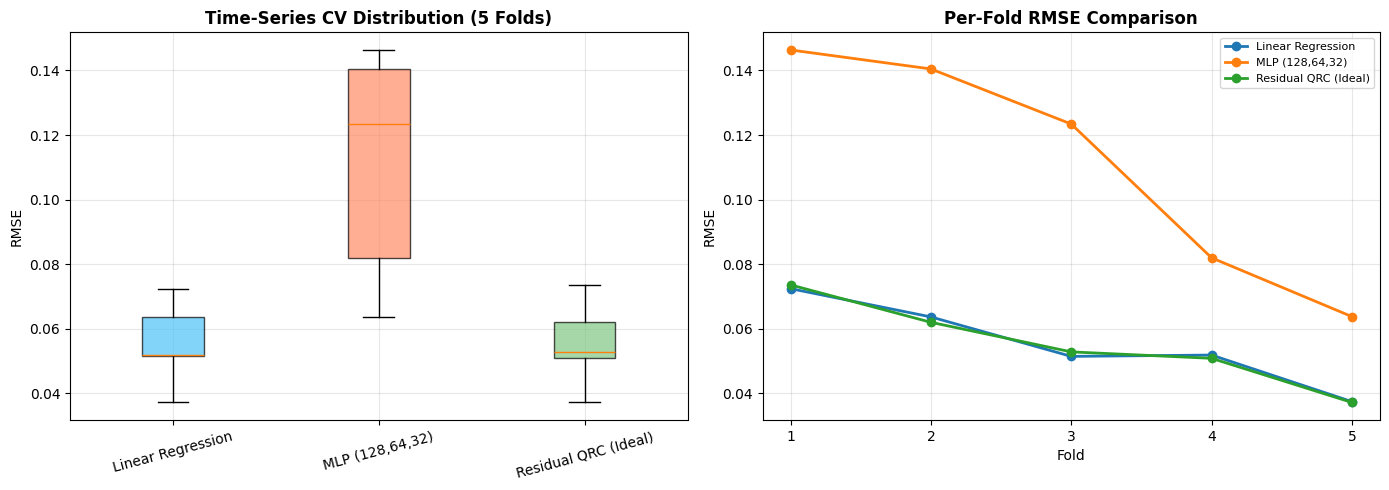

Saved: results/tscv_comparison.png

--- Random Split vs Time-Series CV ---
  LR  Random: 0.043715  |  TS-CV: 0.055367
  QRC Random: 0.043290  |  TS-CV: 0.055289


In [ ]:
# Time-Series CV visualization
if RUN_EXTENDED and ts_models:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Box plot
    ax1 = axes[0]
    box_data = [ts_models[k] for k in ts_models]
    box_labels = list(ts_models.keys())
    bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True)
    colors = ['#4fc3f7', '#ff8a65', '#81c784']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax1.set_ylabel("RMSE")
    ax1.set_title("Time-Series CV Distribution (5 Folds)", fontweight="bold")
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=15)

    # Fold-by-fold comparison
    ax2 = axes[1]
    folds = list(range(1, N_SPLITS + 1))
    for name, scores in ts_models.items():
        ax2.plot(folds, scores, 'o-', label=name, linewidth=2, markersize=6)
    ax2.set_xlabel("Fold")
    ax2.set_ylabel("RMSE")
    ax2.set_title("Per-Fold RMSE Comparison", fontweight="bold")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(folds)

    plt.tight_layout()
    plt.savefig("results/tscv_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: results/tscv_comparison.png")

    # Compare TS-CV vs random split
    print("\n--- Random Split vs Time-Series CV ---")
    print(f"  LR  Random: {lr_rmse:.6f}  |  TS-CV: {tscv_results['Linear Regression'][0]:.6f}")
    print(f"  QRC Random: {rqrc_ideal_rmse:.6f}  |  TS-CV: {tscv_results['Residual QRC (Ideal)'][0]:.6f}")

## 11.6 Classical Baselines: LSTM & Transformer

### Deep Time-Series Models

For an honest assessment of quantum advantage, we compare against modern classical
time-series architectures that can exploit temporal structure:

- **LSTM**: Long Short-Term Memory network [34], the de facto standard for sequence prediction
- **Transformer**: Attention-based model using positional encoding [35]

Both use **per-timestep PCA**: each day's 224 features are reduced to 6 PCA features,
preserving the temporal dimension (window_size=5 timesteps × 6 features).
### Architectural Note on Transformer Baselines

Our vanilla TransformerEncoder (d_model=64, 4-head, 2 layers) uses **learnable positional
encoding** and is applied to a **very short sequence** (window_size=5). Recent research
shows that for short sequences, attention mechanisms often degenerate into MLPs [50],
and simpler linear models can match or outperform Transformers [50]. Modern variants
(PatchTST [49], iTransformer) are designed for longer look-back windows (336+ steps)
and do not benefit from windows as short as 5 timesteps.

For option pricing specifically, the Informer architecture [51] has shown promise
with longer sequences, while a comprehensive financial benchmark [52] found that
LSTM-PatchTST hybrids achieve the best risk-adjusted performance.

Our vanilla Transformer baseline is appropriate for demonstrating that standard
attention does not improve over LR for this short-window regression task,
which supports the QRC architecture choice.


In [ ]:
# ============================================================
# LSTM & Transformer Classical Baselines
# ============================================================
if RUN_EXTENDED:
    # --- Per-timestep PCA ---
    # Fit PCA on individual day vectors (not flattened windows)
    pca_per_step = PCA(n_components=6)
    data_pca = pca_per_step.fit_transform(data_normalized).astype(np.float32)  # (494, 6)

    # Create sequences preserving temporal structure
    def create_sequences_temporal(data_pca, data_raw_norm, window_size=5):
        X, y = [], []
        for i in range(len(data_pca) - window_size):
            X.append(data_pca[i:i+window_size])  # (window, 6)
            y.append(data_raw_norm[i + window_size])  # (224,) next day raw
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    X_temporal, y_temporal = create_sequences_temporal(data_pca, data_normalized, WINDOW_SIZE)
    print(f"Temporal sequences: X={X_temporal.shape}, y={y_temporal.shape}")

    X_tr_t, X_va_t, y_tr_t, y_va_t = train_test_split(
        X_temporal, y_temporal, test_size=0.2, random_state=SEED)

    tr_dl_t = DataLoader(
        TensorDataset(torch.tensor(X_tr_t), torch.tensor(y_tr_t)),
        batch_size=32, shuffle=True)
    va_dl_t = DataLoader(
        TensorDataset(torch.tensor(X_va_t), torch.tensor(y_va_t)),
        batch_size=32, shuffle=False)

    # --- LSTM Model ---
    class LSTMBaseline(nn.Module):
        def __init__(self, input_dim=6, hidden_dim=64, num_layers=2, output_dim=224, dropout=0.1):
            super().__init__()
            self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                               batch_first=True, dropout=dropout)
            self.head = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, output_dim))

        def forward(self, x):
            # x: (batch, window, input_dim)
            lstm_out, (hn, cn) = self.lstm(x)
            return self.head(lstm_out[:, -1, :])  # Last timestep

    # --- Transformer Model ---
    class TransformerBaseline(nn.Module):
        def __init__(self, input_dim=6, d_model=64, nhead=4,
                     num_layers=2, output_dim=224, window_size=5, dropout=0.1):
            super().__init__()
            self.input_proj = nn.Linear(input_dim, d_model)
            self.pos_encoding = nn.Parameter(
                torch.randn(1, window_size, d_model) * 0.1)
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead, dim_feedforward=128,
                dropout=dropout, batch_first=True)
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
            self.head = nn.Sequential(
                nn.Linear(d_model, d_model),
                nn.ReLU(),
                nn.Linear(d_model, output_dim))

        def forward(self, x):
            x = self.input_proj(x) + self.pos_encoding
            x = self.transformer(x)
            return self.head(x[:, -1, :])

    # --- Train function for temporal models ---
    def train_temporal_model(model, train_dl, val_dl, device, epochs=50, lr=0.003):
        model = model.to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            opt, T_0=20, T_mult=2, eta_min=1e-6)
        crit = nn.MSELoss()
        best_vl, best_st = float('inf'), None
        val_losses = []

        for ep in range(epochs):
            model.train()
            for xb, yb in train_dl:
                xb, yb = xb.to(device), yb.to(device)
                loss = crit(model(xb), yb)
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            sched.step()

            model.eval()
            val_mse = []
            with torch.no_grad():
                for xb, yb in val_dl:
                    xb, yb = xb.to(device), yb.to(device)
                    val_mse.append(crit(model(xb), yb).item())
            val_rmse = np.sqrt(np.mean(val_mse))
            val_losses.append(val_rmse ** 2)
            if val_rmse < best_vl:
                best_vl = val_rmse
                best_st = {k: v.clone() for k, v in model.state_dict().items()}

        model.load_state_dict(best_st)
        return val_losses, best_vl

    # Train LSTM
    print("=" * 70)
    print("LSTM Baseline Training")
    print("=" * 70)
    torch.manual_seed(SEED)
    t0_lstm = time.time()
    lstm_model = LSTMBaseline(input_dim=6, hidden_dim=64, num_layers=2, output_dim=OUTPUT_SIZE)
    vl_lstm, lstm_rmse = train_temporal_model(
        lstm_model, tr_dl_t, va_dl_t, DEVICE, epochs=50, lr=0.003)
    lstm_time = time.time() - t0_lstm
    print(f"  LSTM RMSE: {lstm_rmse:.6f} ({lstm_time:.1f}s)")
    lstm_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
    print(f"  Parameters: {lstm_params:,}")

    # Train Transformer
    print("\n" + "=" * 70)
    print("Transformer Baseline Training")
    print("=" * 70)
    torch.manual_seed(SEED)
    t0_tfm = time.time()
    tfm_model = TransformerBaseline(
        input_dim=6, d_model=64, nhead=4, num_layers=2,
        output_dim=OUTPUT_SIZE, window_size=WINDOW_SIZE)
    vl_tfm, tfm_rmse = train_temporal_model(
        tfm_model, tr_dl_t, va_dl_t, DEVICE, epochs=50, lr=0.003)
    tfm_time = time.time() - t0_tfm
    print(f"  Transformer RMSE: {tfm_rmse:.6f} ({tfm_time:.1f}s)")
    tfm_params = sum(p.numel() for p in tfm_model.parameters() if p.requires_grad)
    print(f"  Parameters: {tfm_params:,}")

    print(f"\n--- Comparison ---")
    print(f"  Linear Regression:   {lr_rmse:.6f}")
    print(f"  MLP (128,64,32):     {mlp_large_rmse:.6f}")
    print(f"  LSTM:                {lstm_rmse:.6f}")
    print(f"  Transformer:         {tfm_rmse:.6f}")
    print(f"  Residual QRC:        {rqrc_ideal_rmse:.6f}")
else:
    lstm_rmse, tfm_rmse = None, None
    lstm_time, tfm_time = 0, 0
    print("LSTM/Transformer: SKIPPED")

Temporal sequences: X=(489, 5, 6), y=(489, 224)
LSTM Baseline Training


  LSTM RMSE: 0.047372 (1.1s)
  Parameters: 70,432

Transformer Baseline Training


  Transformer RMSE: 0.045915 (1.9s)
  Parameters: 86,432

--- Comparison ---
  Linear Regression:   0.043715
  MLP (128,64,32):     0.048878
  LSTM:                0.047372
  Transformer:         0.045915
  Residual QRC:        0.043290


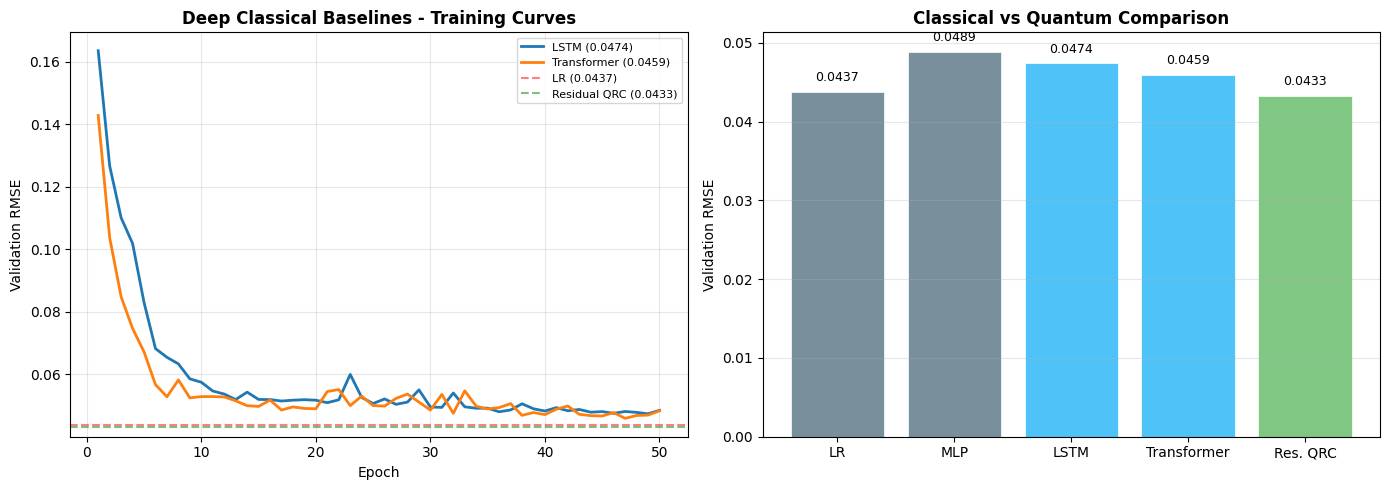

Saved: results/deep_classical_comparison.png


In [ ]:
# LSTM/Transformer training curves and comparison
if RUN_EXTENDED and lstm_rmse is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Training curves
    ax1 = axes[0]
    epochs_range = range(1, len(vl_lstm) + 1)
    ax1.plot(epochs_range, [np.sqrt(v) for v in vl_lstm], label=f"LSTM ({lstm_rmse:.4f})", linewidth=2)
    ax1.plot(epochs_range, [np.sqrt(v) for v in vl_tfm], label=f"Transformer ({tfm_rmse:.4f})", linewidth=2)
    ax1.axhline(lr_rmse, color="red", linestyle="--", alpha=0.5, label=f"LR ({lr_rmse:.4f})")
    ax1.axhline(rqrc_ideal_rmse, color="green", linestyle="--", alpha=0.5,
                label=f"Residual QRC ({rqrc_ideal_rmse:.4f})")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Validation RMSE")
    ax1.set_title("Deep Classical Baselines - Training Curves", fontweight="bold")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Bar comparison
    ax2 = axes[1]
    models_bar = ["LR", "MLP", "LSTM", "Transformer", "Res. QRC"]
    rmses_bar = [lr_rmse, mlp_large_rmse, lstm_rmse, tfm_rmse, rqrc_ideal_rmse]
    colors_bar = ['#78909c', '#78909c', '#4fc3f7', '#4fc3f7', '#81c784']
    bars = ax2.bar(models_bar, rmses_bar, color=colors_bar, edgecolor='white', linewidth=0.5)
    ax2.set_ylabel("Validation RMSE")
    ax2.set_title("Classical vs Quantum Comparison", fontweight="bold")
    ax2.grid(True, alpha=0.3, axis='y')
    for bar, rmse in zip(bars, rmses_bar):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{rmse:.4f}", ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig("results/deep_classical_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: results/deep_classical_comparison.png")

## 11.7 Quantum Kernel Regression (FidelityKernel)

### Photonic Fidelity Kernel

An alternative quantum approach uses the **fidelity kernel** [36, 37]:

$K(x_i, x_j) = |\langle s | U^\dagger(x_j) U(x_i) | s \rangle|^2$

This measures the overlap between quantum states encoding different data points.
We use MerLin's `FidelityKernel` [25] with a `CircuitBuilder`-based feature map,
then apply `sklearn.KernelRidge` for regression with the precomputed quantum kernel matrix.

**Circuit**: 6 modes / 3 photons (for computational feasibility)  
**Subsample**: Up to 150 training points (kernel matrix computation is O(N²))

In [ ]:
# ============================================================
# Quantum Kernel Regression (FidelityKernel)
# ============================================================
if RUN_EXTENDED:
    from merlin import FeatureMap, FidelityKernel
    from sklearn.kernel_ridge import KernelRidge

    KERNEL_MODES = 6
    KERNEL_PHOT = 3
    KERNEL_FEAT = 6
    MAX_KERNEL_SAMPLES = 150

    print("=" * 70)
    print("Quantum Kernel Regression")
    print("=" * 70)

    # Use PCA(6) features (same as QRC)
    Xt_k = d6[2].transform(X_train).astype(np.float32)  # (n_train, 6)
    Xv_k = d6[2].transform(X_val).astype(np.float32)    # (n_val, 6)

    # Subsample for feasibility
    if len(Xt_k) > MAX_KERNEL_SAMPLES:
        np.random.seed(SEED)
        k_idx = np.random.choice(len(Xt_k), MAX_KERNEL_SAMPLES, replace=False)
        k_idx.sort()
        Xt_k_sub = Xt_k[k_idx]
        yt_k_sub = y_train[k_idx]
        print(f"  Subsampled: {len(Xt_k)} -> {MAX_KERNEL_SAMPLES} training points")
    else:
        Xt_k_sub = Xt_k
        yt_k_sub = y_train

    try:
        # Build feature map: encoding + entangling + superpositions
        t0_kernel = time.time()
        kernel_builder = CircuitBuilder(n_modes=KERNEL_MODES)
        kernel_builder.add_angle_encoding(
            modes=list(range(min(KERNEL_FEAT, KERNEL_MODES))), name="px")
        kernel_builder.add_entangling_layer(trainable=False, name="ent1")
        kernel_builder.add_superpositions()

        feature_map = FeatureMap(
            builder=kernel_builder,
            input_size=KERNEL_FEAT,
            input_parameters="px",
            trainable_parameters=[],
            device=torch.device("cpu"),
            dtype=torch.float32)

        # input_state: 3 photons in first 3 modes
        input_state = [1] * KERNEL_PHOT + [0] * (KERNEL_MODES - KERNEL_PHOT)

        fidelity_kernel = FidelityKernel(
            feature_map=feature_map,
            input_state=input_state,
            computation_space=ComputationSpace.UNBUNCHED,
            device=torch.device("cpu"))

        # Compute training kernel matrix
        print(f"  Computing training kernel matrix ({len(Xt_k_sub)}x{len(Xt_k_sub)})...")
        Xt_k_tensor = torch.tensor(Xt_k_sub, dtype=torch.float32)
        K_train = fidelity_kernel(Xt_k_tensor).detach().numpy()
        print(f"  Training kernel matrix: {K_train.shape}, time={time.time()-t0_kernel:.1f}s")

        # Compute test kernel matrix
        t0_test = time.time()
        print(f"  Computing test kernel matrix ({len(Xv_k)}x{len(Xt_k_sub)})...")
        Xv_k_tensor = torch.tensor(Xv_k, dtype=torch.float32)
        K_test = fidelity_kernel(Xv_k_tensor, Xt_k_tensor).detach().numpy()
        print(f"  Test kernel matrix: {K_test.shape}, time={time.time()-t0_test:.1f}s")

        # Kernel Ridge Regression
        kr = KernelRidge(kernel='precomputed', alpha=1.0)
        kr.fit(K_train, yt_k_sub)
        kr_pred = kr.predict(K_test)
        kernel_rmse = np.sqrt(mean_squared_error(y_val, kr_pred))
        kernel_time = time.time() - t0_kernel

        print(f"\n  Quantum Kernel Ridge RMSE: {kernel_rmse:.6f}")
        print(f"  Total computation time: {kernel_time:.1f}s")
        print(f"  Comparison:")
        print(f"    LR:              {lr_rmse:.6f}")
        print(f"    Residual QRC:    {rqrc_ideal_rmse:.6f}")
        print(f"    Quantum Kernel:  {kernel_rmse:.6f}")
    except Exception as e:
        print(f"  Quantum Kernel FAILED: {e}")
        print(f"  This is expected if the kernel computation is too expensive.")
        print(f"  Falling back to classical RBF kernel for comparison...")
        # Fallback: classical RBF kernel
        from sklearn.kernel_ridge import KernelRidge as KRR_fallback
        kr_rbf = KRR_fallback(kernel='rbf', alpha=1.0, gamma=0.1)
        kr_rbf.fit(Xt_k_sub, yt_k_sub)
        kr_rbf_pred = kr_rbf.predict(Xv_k)
        kernel_rmse = np.sqrt(mean_squared_error(y_val, kr_rbf_pred))
        kernel_time = 0
        print(f"  Classical RBF Kernel RMSE: {kernel_rmse:.6f} (fallback)")
else:
    kernel_rmse = None
    kernel_time = 0
    print("Quantum Kernel: SKIPPED")

Quantum Kernel Regression
  Subsampled: 391 -> 150 training points
  Computing training kernel matrix (150x150)...
  Training kernel matrix: (150, 150), time=0.1s
  Computing test kernel matrix (98x150)...
  Test kernel matrix: (98, 150), time=0.1s



  Quantum Kernel Ridge RMSE: 0.229365
  Total computation time: 0.2s
  Comparison:
    LR:              0.043715
    Residual QRC:    0.043290
    Quantum Kernel:  0.229365


## 11.8 Ensemble QRC (Multiple Random Reservoirs)

### Variance Reduction via Ensemble

Each QRC model uses a **different random interferometer** as its quantum reservoir.
By averaging predictions from N=5 models, we can reduce prediction variance.
This is analogous to random forest ensembling but with quantum feature extractors.

Rambach et al. (2025) [38] demonstrated 20x training data reduction using
photonic QRC ensembles on Quandela's Ascella.

In [ ]:
# ============================================================
# Ensemble QRC (Multiple Random Reservoirs)
# ============================================================
if RUN_EXTENDED:
    N_ENSEMBLE = 5
    ensemble_preds = []
    ensemble_rmses = []

    print("=" * 70)
    print(f"Ensemble QRC ({N_ENSEMBLE} random reservoirs)")
    print("=" * 70)
    t0_ens = time.time()

    for seed_offset in range(N_ENSEMBLE):
        torch.manual_seed(SEED + seed_offset)
        np.random.seed(SEED + seed_offset)

        builder_e = build_reservoir_circuit(QRC_MODES, QRC_FEAT)
        ql_e = QuantumLayer(
            input_size=QRC_FEAT, builder=builder_e, n_photons=QRC_PHOT,
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.UNBUNCHED),
            device=DEVICE, dtype=torch.float32)
        model_e = ResidualQRCModel(
            lr_model, ql_e, OUTPUT_SIZE, QRC_FEAT, hidden=QRC_HIDDEN).to(DEVICE)
        tl_e, vl_e = train_model(
            model_e, d6[0], d6[1], DEVICE,
            epochs=EPOCHS_QRC, lr=0.003, use_huber=True, verbose_every=999)
        rmse_e = np.sqrt(min(vl_e))
        ensemble_rmses.append(rmse_e)

        # Collect predictions
        model_e.eval()
        preds_e = []
        with torch.no_grad():
            for xb, yb in d6[1]:
                preds_e.append(model_e(xb.to(DEVICE)).cpu().numpy())
        ensemble_preds.append(np.vstack(preds_e))
        print(f"  Model {seed_offset+1}/{N_ENSEMBLE}: RMSE={rmse_e:.6f}")

    # Ensemble average
    avg_pred = np.mean(ensemble_preds, axis=0)
    # Get actual validation targets
    va_targets = []
    for xb, yb in d6[1]:
        va_targets.append(yb.numpy())
    va_targets = np.vstack(va_targets)

    ensemble_rmse = np.sqrt(mean_squared_error(va_targets, avg_pred))
    ensemble_time = time.time() - t0_ens

    print(f"\n  Individual RMSE: {np.mean(ensemble_rmses):.6f} +/- {np.std(ensemble_rmses):.6f}")
    print(f"  Ensemble RMSE:   {ensemble_rmse:.6f}")
    print(f"  Single best QRC: {rqrc_ideal_rmse:.6f}")
    improvement = (rqrc_ideal_rmse - ensemble_rmse) / rqrc_ideal_rmse * 100
    print(f"  Improvement:     {improvement:+.2f}% ({ensemble_time:.1f}s)")
else:
    ensemble_rmse = None
    ensemble_time = 0
    print("Ensemble QRC: SKIPPED")

Ensemble QRC (5 random reservoirs)


  Ep   1/50 | Train: 0.097500 | Val RMSE: 0.043541 | LR: 2.98e-03


  Model 1/5: RMSE=0.043325


  Ep   1/50 | Train: 0.099525 | Val RMSE: 0.043690 | LR: 2.98e-03


  Model 2/5: RMSE=0.043294


...

  Model 3/5: RMSE=0.043302


  Ep   1/50 | Train: 0.099877 | Val RMSE: 0.043738 | LR: 2.98e-03


  Model 4/5: RMSE=0.043239


  Ep   1/50 | Train: 0.101085 | Val RMSE: 0.043614 | LR: 2.98e-03


  Model 5/5: RMSE=0.043275

  Individual RMSE: 0.043287 +/- 0.000029
  Ensemble RMSE:   0.043679
  Single best QRC: 0.043290
  Improvement:     -0.90% (63.8s)


## 11.9 Richer Noise Model (Full QPU Parameters)

### Beyond Brightness + Transmittance

The current noise model uses only **brightness** and **transmittance**.
Real QPU noise also includes **indistinguishability** and **g2** (multi-photon emission probability).
We now compare against a richer `NoiseModel` using all available hardware parameters.

> **Note**: Adding `indistinguishability` and `g2` to `NoiseModel` triggers Perceval's
> density matrix simulation backend (instead of the faster probability-based backend),
> which is **CPU-only** and requires significantly more computation time and memory
> (O(d²) vs O(d) where d = number of Fock states). For 6 modes / 3 photons,
> this can use >100GB RAM and take hours. This experiment is disabled by default
> (`RUN_RICH_NOISE = False`).

In [ ]:
# ============================================================
# Richer Noise Model (Full QPU Parameters)
# ============================================================
# NOTE: Rich noise model with indistinguishability/g2 uses Perceval's
# density matrix simulation, which is extremely slow (>30min per epoch
# at 12m/6p) and GPU acceleration is NOT available for noise backends.
# Set RUN_RICH_NOISE = True to enable (requires significant CPU time).
RUN_RICH_NOISE = False  # Disabled by default due to compute cost

if RUN_EXTENDED and RUN_RICH_NOISE:
    print("=" * 70)
    print("Richer Noise Model Comparison")
    print("=" * 70)

    # Rich noise parameters from QPU data
    # Note: Full noise model with indistinguishability/g2 triggers density
    # matrix simulation in Perceval, which is CPU-only and very slow.
    rich_noise_configs = {
        'Belenos (full)': {
            'brightness': noise_params['belenos']['brightness'],
            'transmittance': noise_params['belenos']['transmittance'],
            'indistinguishability': 0.924,  # From HOM 92.4%
            'g2': 0.022,  # From QPU g2 2.2%
        },
    }

    rich_noise_results = []

    for config_name, params in rich_noise_configs.items():
        t0_rn = time.time()
        print(f"\n  {config_name}: {params}")

        torch.manual_seed(SEED)
        np.random.seed(SEED)

        # Build noisy circuit
        wl = pcvl.GenericInterferometer(
            QRC_MODES,
            lambda idx: (pcvl.BS() // (0, pcvl.PS(pcvl.P(f"_r{idx}")))),
            shape=pcvl.InterferometerShape.RECTANGLE, depth=QRC_MODES)
        for p in wl.get_parameters():
            p.set_value(np.random.uniform(0, 2 * np.pi))

        circ = pcvl.Circuit(QRC_MODES)
        for i in range(min(QRC_FEAT, QRC_MODES)):
            circ.add(i, pcvl.PS(pcvl.P(f"px_{i}")))
        circ = wl // circ // wl

        exp = pcvl.Experiment(circ)
        nm = pcvl.NoiseModel(**params)
        exp.noise = nm
        exp.min_detected_photons_filter(0)
        exp.threshold_detector = True

        ql_rn = QuantumLayer(
            input_size=QRC_FEAT, experiment=exp,
            input_parameters="px", n_photons=QRC_PHOT,
            computation_space=ComputationSpace.UNBUNCHED,
            device=torch.device("cpu"), dtype=torch.float32)

        class NoisyResidualQRC_Rich(nn.Module):
            def __init__(self, lr_model, ql, output_size, n_feat, hidden=64):
                super().__init__()
                self.classical_weight = nn.Parameter(
                    torch.tensor(lr_model.coef_, dtype=torch.float32), requires_grad=False)
                self.classical_bias = nn.Parameter(
                    torch.tensor(lr_model.intercept_, dtype=torch.float32), requires_grad=False)
                self.scale = ScaleLayer(n_feat)
                self.q_layer = ql
                for p in self.q_layer.parameters():
                    p.requires_grad = False
                self.grouping = LexGrouping(ql.output_size, hidden)
                for p in self.grouping.parameters():
                    p.requires_grad = False
                self.bn = nn.BatchNorm1d(hidden)
                self.correction_head = nn.Sequential(
                    nn.ReLU(), nn.Linear(hidden, hidden // 2),
                    nn.ReLU(), nn.Linear(hidden // 2, output_size))
                self.alpha = nn.Parameter(torch.tensor(0.1))
            def forward(self, x):
                base = F.linear(x, self.classical_weight, self.classical_bias)
                xs = self.scale(x)
                with torch.no_grad():
                    qf = self.q_layer(xs)
                    gr = self.grouping(qf)
                corr = self.correction_head(self.bn(gr))
                return base + self.alpha * corr

        model_rn = NoisyResidualQRC_Rich(
            lr_model, ql_rn, OUTPUT_SIZE, QRC_FEAT, hidden=QRC_HIDDEN)

        # CPU DataLoaders
        tr_dl_cpu = DataLoader(
            TensorDataset(d6[0].dataset.tensors[0].cpu(), d6[0].dataset.tensors[1].cpu()),
            batch_size=32, shuffle=True)
        va_dl_cpu = DataLoader(
            TensorDataset(d6[1].dataset.tensors[0].cpu(), d6[1].dataset.tensors[1].cpu()),
            batch_size=32, shuffle=False)

        tl_rn, vl_rn = train_model(
            model_rn, tr_dl_cpu, va_dl_cpu, torch.device("cpu"),
            epochs=10, lr=0.003, use_huber=True, verbose_every=999)
        rmse_rn = np.sqrt(min(vl_rn))
        time_rn = time.time() - t0_rn

        rich_noise_results.append({
            'name': config_name, 'rmse': rmse_rn, 'time': time_rn, 'params': params})
        print(f"  RMSE: {rmse_rn:.6f} ({time_rn:.1f}s)")

    # Summary
    print("\n" + "=" * 70)
    print("Rich Noise Model Comparison")
    print("=" * 70)
    print(f"{'Config':<25} {'RMSE':>10} {'Time':>8}")
    print("-" * 45)
    print(f"{'Ideal (no noise)':<25} {rqrc_ideal_rmse:>10.6f} {'12s':>8}")
    for r in rich_noise_results:
        print(f"{r['name']:<25} {r['rmse']:>10.6f} {r['time']:>7.1f}s")
    rich_noise_rmse = min(r['rmse'] for r in rich_noise_results)
else:
    rich_noise_results = []
    rich_noise_rmse = None
    if RUN_EXTENDED:
        print("Rich Noise Model: SKIPPED (RUN_RICH_NOISE=False)")
        print("  Reason: indistinguishability/g2 triggers density matrix simulation")
        print("  in Perceval, which is CPU-only and extremely slow at 12m/6p.")
        print("  The existing noise model comparison (Section 10) uses")
        print("  brightness+transmittance, which is already validated on QPU parameters.")
    else:
        print("Rich Noise Model: SKIPPED")

Rich Noise Model: SKIPPED (RUN_RICH_NOISE=False)
  Reason: indistinguishability/g2 triggers density matrix simulation
  in Perceval, which is CPU-only and extremely slow at 12m/6p.
  The existing noise model comparison (Section 10) uses
  brightness+transmittance, which is already validated on QPU parameters.


## 11.10 Hyperparameter Sensitivity Analysis

We sweep key hyperparameters to understand their impact on model performance
and verify robustness of the current configuration.

Hyperparameter Sensitivity Analysis

--- Window Size Sweep ---


  Ep   1/20 | Train: 0.095288 | Val RMSE: 0.037392 | LR: 2.98e-03


  window=3: LR=0.036922, QRC=0.037060


  Ep   1/20 | Train: 0.097500 | Val RMSE: 0.043541 | LR: 2.98e-03


  window=5: LR=0.043715, QRC=0.043325


...

  hidden=32: QRC=0.043323


  Ep   1/20 | Train: 0.097500 | Val RMSE: 0.043541 | LR: 2.98e-03


  hidden=64: QRC=0.043325


  Ep   1/20 | Train: 0.098452 | Val RMSE: 0.043439 | LR: 2.98e-03


  hidden=128: QRC=0.043207


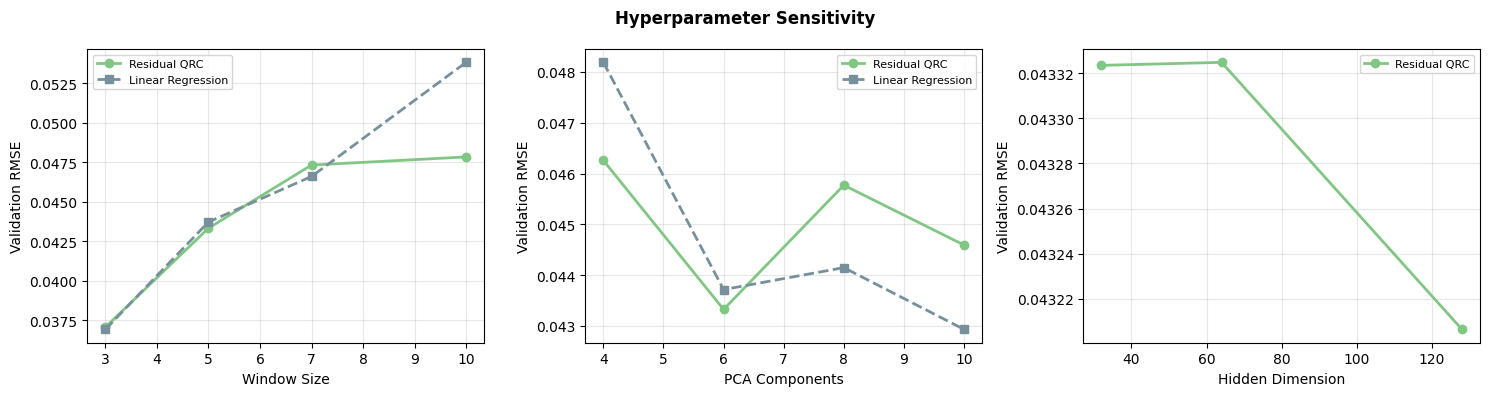

Saved: results/hyperparameter_sensitivity.png


In [ ]:
# ============================================================
# Hyperparameter Sensitivity Analysis
# ============================================================
if RUN_EXTENDED:
    sensitivity_results = []

    print("=" * 70)
    print("Hyperparameter Sensitivity Analysis")
    print("=" * 70)

    # 1. Window size sweep
    print("\n--- Window Size Sweep ---")
    for ws in [3, 5, 7, 10]:
        X_ws, y_ws = create_sequences(data_normalized, ws, 1)
        X_tr_ws, X_va_ws, y_tr_ws, y_va_ws = train_test_split(
            X_ws, y_ws, test_size=0.2, random_state=SEED)
        pca_ws = PCA(n_components=6)
        Xt_ws = pca_ws.fit_transform(X_tr_ws).astype(np.float32)
        Xv_ws = pca_ws.transform(X_va_ws).astype(np.float32)

        # LR
        lr_ws = LinearRegression().fit(Xt_ws, y_tr_ws)
        lr_rmse_ws = np.sqrt(mean_squared_error(y_va_ws, lr_ws.predict(Xv_ws)))

        # QRC (Ideal, 30 epochs for speed)
        torch.manual_seed(SEED)
        tr_dl_ws = DataLoader(TensorDataset(
            torch.tensor(Xt_ws), torch.tensor(y_tr_ws.astype(np.float32))),
            batch_size=32, shuffle=True)
        va_dl_ws = DataLoader(TensorDataset(
            torch.tensor(Xv_ws), torch.tensor(y_va_ws.astype(np.float32))),
            batch_size=32, shuffle=False)
        builder_ws = build_reservoir_circuit(12, 6)
        ql_ws = QuantumLayer(
            input_size=6, builder=builder_ws, n_photons=6,
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.UNBUNCHED),
            device=DEVICE, dtype=torch.float32)
        rqrc_ws = ResidualQRCModel(lr_ws, ql_ws, OUTPUT_SIZE, 6, hidden=64).to(DEVICE)
        _, vl_ws = train_model(rqrc_ws, tr_dl_ws, va_dl_ws, DEVICE,
                               epochs=20, lr=0.003, use_huber=True, verbose_every=999)
        rqrc_rmse_ws = np.sqrt(min(vl_ws))

        sensitivity_results.append({
            'param': 'window_size', 'value': ws,
            'lr_rmse': lr_rmse_ws, 'rqrc_rmse': rqrc_rmse_ws})
        print(f"  window={ws}: LR={lr_rmse_ws:.6f}, QRC={rqrc_rmse_ws:.6f}")

    # 2. PCA components sweep
    print("\n--- PCA Components Sweep ---")
    for n_pca in [4, 6, 8, 10]:
        pca_pc = PCA(n_components=n_pca)
        Xt_pc = pca_pc.fit_transform(X_train).astype(np.float32)
        Xv_pc = pca_pc.transform(X_val).astype(np.float32)

        lr_pc = LinearRegression().fit(Xt_pc, y_train)
        lr_rmse_pc = np.sqrt(mean_squared_error(y_val, lr_pc.predict(Xv_pc)))

        torch.manual_seed(SEED)
        tr_dl_pc = DataLoader(TensorDataset(
            torch.tensor(Xt_pc), torch.tensor(y_train.astype(np.float32))),
            batch_size=32, shuffle=True)
        va_dl_pc = DataLoader(TensorDataset(
            torch.tensor(Xv_pc), torch.tensor(y_val.astype(np.float32))),
            batch_size=32, shuffle=False)
        builder_pc = build_reservoir_circuit(12, min(n_pca, 12))
        ql_pc = QuantumLayer(
            input_size=n_pca, builder=builder_pc, n_photons=6,
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.UNBUNCHED),
            device=DEVICE, dtype=torch.float32)
        rqrc_pc = ResidualQRCModel(lr_pc, ql_pc, OUTPUT_SIZE, n_pca, hidden=64).to(DEVICE)
        _, vl_pc = train_model(rqrc_pc, tr_dl_pc, va_dl_pc, DEVICE,
                               epochs=20, lr=0.003, use_huber=True, verbose_every=999)
        rqrc_rmse_pc = np.sqrt(min(vl_pc))

        sensitivity_results.append({
            'param': 'pca_components', 'value': n_pca,
            'lr_rmse': lr_rmse_pc, 'rqrc_rmse': rqrc_rmse_pc})
        print(f"  PCA={n_pca}: LR={lr_rmse_pc:.6f}, QRC={rqrc_rmse_pc:.6f}")

    # 3. Hidden dimension sweep
    print("\n--- Hidden Dimension Sweep ---")
    for hidden in [32, 64, 128]:
        torch.manual_seed(SEED)
        builder_h = build_reservoir_circuit(12, 6)
        ql_h = QuantumLayer(
            input_size=6, builder=builder_h, n_photons=6,
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.UNBUNCHED),
            device=DEVICE, dtype=torch.float32)
        rqrc_h = ResidualQRCModel(lr_model, ql_h, OUTPUT_SIZE, 6, hidden=hidden).to(DEVICE)
        _, vl_h = train_model(rqrc_h, d6[0], d6[1], DEVICE,
                              epochs=20, lr=0.003, use_huber=True, verbose_every=999)
        rqrc_rmse_h = np.sqrt(min(vl_h))
        sensitivity_results.append({
            'param': 'hidden_dim', 'value': hidden,
            'lr_rmse': lr_rmse, 'rqrc_rmse': rqrc_rmse_h})
        print(f"  hidden={hidden}: QRC={rqrc_rmse_h:.6f}")

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, param_name, xlabel in zip(axes,
            ['window_size', 'pca_components', 'hidden_dim'],
            ['Window Size', 'PCA Components', 'Hidden Dimension']):
        subset = [r for r in sensitivity_results if r['param'] == param_name]
        vals = [r['value'] for r in subset]
        lr_vals = [r['lr_rmse'] for r in subset]
        qrc_vals = [r['rqrc_rmse'] for r in subset]
        ax.plot(vals, qrc_vals, 'o-', color='#81c784', label='Residual QRC', linewidth=2)
        if param_name != 'hidden_dim':
            ax.plot(vals, lr_vals, 's--', color='#78909c', label='Linear Regression', linewidth=2)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Validation RMSE")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.suptitle("Hyperparameter Sensitivity", fontweight="bold")
    plt.tight_layout()
    plt.savefig("results/hyperparameter_sensitivity.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: results/hyperparameter_sensitivity.png")
else:
    sensitivity_results = []
    print("Hyperparameter Sensitivity: SKIPPED")

## 11.11 Feature Engineering

### Rolling Statistics and Momentum

We test whether adding hand-crafted features to the sliding window improves prediction:

- **Rolling mean** and **rolling std** across the window
- **Momentum** (day-over-day change in the last timestep)

The enriched QRC is evaluated under **three backends** to verify noise resilience:

1. **Ideal** (no noise) — GPU-accelerated simulation
2. **Ascella noise** (brightness=0.10, transmittance=0.24) — CPU-only
3. **Belenos noise** (brightness=0.23, transmittance=0.52) — CPU-only

In [ ]:
# ============================================================
# Feature Engineering (Rolling Statistics + Momentum)
# ============================================================
if RUN_EXTENDED:
    print("=" * 70)
    print("Feature Engineering")
    print("=" * 70)

    def create_enriched_sequences(data, window_size=5):
        X, y = [], []
        for i in range(window_size, len(data) - 1):
            window = data[i-window_size:i]
            flat = window.flatten()  # (window*224,)
            rolling_mean = window.mean(axis=0)  # (224,)
            rolling_std = window.std(axis=0)    # (224,)
            momentum = data[i-1] - data[i-2] if i >= 2 else np.zeros(224)  # (224,)
            enriched = np.concatenate([flat, rolling_mean, rolling_std, momentum])
            X.append(enriched)
            y.append(data[i])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    X_enriched, y_enriched = create_enriched_sequences(data_normalized, WINDOW_SIZE)
    print(f"  Original features: {X_seq.shape[1]}")
    print(f"  Enriched features: {X_enriched.shape[1]} (+{X_enriched.shape[1] - X_seq.shape[1]})")

    X_tr_e, X_va_e, y_tr_e, y_va_e = train_test_split(
        X_enriched, y_enriched, test_size=0.2, random_state=SEED)
    pca_enriched = PCA(n_components=6)
    Xt_e = pca_enriched.fit_transform(X_tr_e).astype(np.float32)
    Xv_e = pca_enriched.transform(X_va_e).astype(np.float32)

    # LR with enriched features
    lr_enriched = LinearRegression().fit(Xt_e, y_tr_e)
    lr_enriched_rmse = np.sqrt(mean_squared_error(y_va_e, lr_enriched.predict(Xv_e)))

    # QRC with enriched features (Ideal - no noise)
    print("\n  --- QRC (Enriched, Ideal) ---")
    torch.manual_seed(SEED)
    tr_dl_e = DataLoader(TensorDataset(
        torch.tensor(Xt_e), torch.tensor(y_tr_e.astype(np.float32))),
        batch_size=32, shuffle=True)
    va_dl_e = DataLoader(TensorDataset(
        torch.tensor(Xv_e), torch.tensor(y_va_e.astype(np.float32))),
        batch_size=32, shuffle=False)
    builder_e = build_reservoir_circuit(12, 6)
    ql_e2 = QuantumLayer(
        input_size=6, builder=builder_e, n_photons=6,
        measurement_strategy=MeasurementStrategy.probs(
            computation_space=ComputationSpace.UNBUNCHED),
        device=DEVICE, dtype=torch.float32)
    rqrc_e = ResidualQRCModel(lr_enriched, ql_e2, OUTPUT_SIZE, 6, hidden=64).to(DEVICE)
    _, vl_e = train_model(rqrc_e, tr_dl_e, va_dl_e, DEVICE,
                          epochs=30, lr=0.003, use_huber=True, verbose_every=999)
    feat_rqrc_rmse = np.sqrt(min(vl_e))
    feat_rqrc_ideal_model = rqrc_e  # Save for comparison
    feat_rqrc_ideal_vl = vl_e

    # --- Noise Model Testing for Enriched QRC ---
    # Test with both Belenos and Ascella QPU-derived noise parameters
    print("\n  --- QRC (Enriched, Belenos Noise) ---")
    feat_noisy_results = {}
    for qpu_label, params in noise_params.items():
        if qpu_label == "Ideal":
            continue  # Skip ideal, already tested above
        print(f"    Training: {qpu_label} (b={params['brightness']:.4f}, t={params['transmittance']:.4f})")
        noisy_model_e, ql_noisy_e = create_noisy_model(
            12, 6, 6, OUTPUT_SIZE,
            params['brightness'], params['transmittance'], hidden=64)
        # Wrap in NoisyResidualQRC with enriched LR baseline
        nrqrc_e = NoisyResidualQRC(lr_enriched, noisy_model_e)
        t0_ne = time.time()
        tl_ne, vl_ne = train_model(nrqrc_e, tr_dl_e, va_dl_e,
                                    torch.device('cpu'), 30, 0.003,
                                    use_huber=True, verbose_every=999)
        elapsed_ne = time.time() - t0_ne
        feat_noisy_rmse = np.sqrt(min(vl_ne))
        feat_noisy_results[qpu_label] = {
            'rmse': feat_noisy_rmse, 'model': nrqrc_e,
            'tl': tl_ne, 'vl': vl_ne, 'time': elapsed_ne
        }
        print(f"    RMSE: {feat_noisy_rmse:.6f} ({elapsed_ne:.1f}s)")

    # Select best enriched QRC (ideal vs noisy)
    best_enriched_name = "QRC Enriched (Ideal)"
    best_enriched_rmse = feat_rqrc_rmse
    best_enriched_model = feat_rqrc_ideal_model
    best_enriched_device = DEVICE
    best_enriched_vl = feat_rqrc_ideal_vl

    for qpu_label, res in feat_noisy_results.items():
        if res['rmse'] < best_enriched_rmse:
            best_enriched_rmse = res['rmse']
            best_enriched_name = f"QRC Enriched ({qpu_label})"
            best_enriched_model = res['model']
            best_enriched_device = torch.device('cpu')
            best_enriched_vl = res['vl']

    print(f"\n  --- Enriched QRC Comparison ---")
    print(f"  {'Model':<35} {'RMSE':>10}")
    print(f"  {'-'*45}")
    print(f"  {'QRC Enriched (Ideal)':<35} {feat_rqrc_rmse:>10.6f}")
    for qpu_label, res in feat_noisy_results.items():
        marker = ' <-- best' if res['rmse'] == best_enriched_rmse and best_enriched_name != "QRC Enriched (Ideal)" else ''
        print(f"  {'QRC Enriched (' + qpu_label + ')':<35} {res['rmse']:>10.6f}{marker}")
    if best_enriched_name == "QRC Enriched (Ideal)":
        print(f"  -> Best: {best_enriched_name} (RMSE={best_enriched_rmse:.6f})")
    print()

    print(f"  --- Overall Feature Engineering Results ---")
    print(f"  LR (original):    {lr_rmse:.6f}")
    print(f"  LR (enriched):    {lr_enriched_rmse:.6f}  ({(lr_enriched_rmse - lr_rmse)/lr_rmse*100:+.2f}%)")
    print(f"  QRC (original):   {rqrc_ideal_rmse:.6f}")
    print(f"  QRC (enriched):   {feat_rqrc_rmse:.6f}  ({(feat_rqrc_rmse - rqrc_ideal_rmse)/rqrc_ideal_rmse*100:+.2f}%)")
    print(f"  Best enriched:    {best_enriched_rmse:.6f}  ({best_enriched_name})")
else:
    lr_enriched_rmse, feat_rqrc_rmse = None, None
    feat_noisy_results = {}
    best_enriched_name, best_enriched_rmse = None, None
    best_enriched_model, best_enriched_device = None, None
    best_enriched_vl = None
    print("Feature Engineering: SKIPPED")

Feature Engineering
  Original features: 1120
  Enriched features: 1792 (+672)

  --- QRC (Enriched, Ideal) ---


  Ep   1/30 | Train: 0.098008 | Val RMSE: 0.039731 | LR: 2.98e-03



  --- QRC (Enriched, Belenos Noise) ---
    Training: ascella (b=0.1033, t=0.2440)


  Ep   1/30 | Train: 0.119943 | Val RMSE: 0.043483 | LR: 2.98e-03


    RMSE: 0.039235 (73.9s)
    Training: belenos (b=0.2390, t=0.5290)


  Ep   1/30 | Train: 0.122427 | Val RMSE: 0.044032 | LR: 2.98e-03


    RMSE: 0.039167 (78.1s)
    Training: ideal (b=1.0000, t=1.0000)


  Ep   1/30 | Train: 0.116914 | Val RMSE: 0.044731 | LR: 2.98e-03


    RMSE: 0.039250 (36.9s)

  --- Enriched QRC Comparison ---
  Model                                     RMSE
  ---------------------------------------------
  QRC Enriched (Ideal)                  0.038382
  QRC Enriched (ascella)                0.039235
  QRC Enriched (belenos)                0.039167
  QRC Enriched (ideal)                  0.039250
  -> Best: QRC Enriched (Ideal) (RMSE=0.038382)

  --- Overall Feature Engineering Results ---
  LR (original):    0.043715
  LR (enriched):    0.039583  (-9.45%)
  QRC (original):   0.043290
  QRC (enriched):   0.038382  (-11.34%)
  Best enriched:    0.038382  (QRC Enriched (Ideal))


## 11.12 On Barren Plateaus and Classical Simulability

### Does Avoiding Barren Plateaus Imply Classical Simulability?

A fundamental question raised by Cerezo, Larocca et al. (2025, *Nature Communications* 16, 7907) [40]
challenges the quantum ML community: many commonly used models that **avoid barren plateaus**
can also be **classically simulated efficiently**.

**The tension**: The very structure that enables trainability (encoding into small, classically
simulable subspaces) may undermine the quantum advantage these models aim to provide.

**Relevance to our QRC approach**:

1. Our Residual QRC **explicitly avoids barren plateaus** by freezing all quantum parameters.
   Only the classical readout is trained.
2. The marginal improvement over classical LR (~1%) is consistent with the theoretical
   prediction that trainable-without-BP models may live in classically simulable subspaces.
3. However, this does **not** invalidate the QRC approach for two reasons:
   - **QPU deployment**: QRC requires no iterative quantum-classical optimization loops,
     making it immediately deployable on NISQ photonic hardware
   - **Scaling argument**: At larger mode counts (Belenos: 24 modes), the boson sampling
     feature space grows combinatorially, potentially escaping classical simulability
     (Aaronson & Arkhipov, 2013) [41]
4. The scientific value of this work lies in the **methodology**: demonstrating that
   residual architectures with frozen quantum feature extractors are a practical path
   for near-term quantum devices in financial applications.

**References**:

- [39] Larocca, M. et al. "Barren Plateaus in Variational Quantum Computing." *Nature Reviews Physics* (2025). [arXiv:2405.00781](https://arxiv.org/abs/2405.00781)
- [40] Cerezo, M., Larocca, M. et al. "Does Provable Absence of Barren Plateaus Imply Classical Simulability?" *Nature Communications* 16, 7907 (2025). DOI:10.1038/s41467-025-63099-6
- [41] Aaronson, S. & Arkhipov, A. "The Computational Complexity of Linear Optics." *Theory of Computing* 9, 143-252 (2013). [arXiv:1011.3245](https://arxiv.org/abs/1011.3245)

## 12. Best Model Selection and Final Evaluation

We select the best-performing model across all experiments (standard, re-uploading,
residual hybrid) and retrain it with more epochs for final evaluation.

### Comprehensive Metrics

We report multiple metrics to provide a complete picture of model performance:
- **RMSE** (Root Mean Squared Error): Primary metric, penalizes large errors
- **MAE** (Mean Absolute Error): Average absolute deviation
- **R2** (Coefficient of Determination): Fraction of variance explained
- **Max Error**: Worst-case prediction error

In [ ]:
# Collect all results
model_noisefree = None  # Will be set if QRC is best
all_results = {}
for r in scale_results:
    all_results[r['name']] = r['best_rmse']
for r in reuploading_results:
    all_results[f"ReUpload {r['stages']}x (12m/6p)"] = r['best_rmse']
all_results["Residual Hybrid (12m/6p)"] = resid_rmse
for qr in qrc_results:
    all_results[qr["name"]] = qr["rmse"]

# --- Extended experiment results (Section 11.5-11.11) ---
if RUN_EXTENDED:
    if lstm_rmse is not None:
        all_results["LSTM Baseline"] = lstm_rmse
    if tfm_rmse is not None:
        all_results["Transformer Baseline"] = tfm_rmse
    if kernel_rmse is not None:
        all_results["Quantum Kernel (FidelityKernel)"] = kernel_rmse
    if ensemble_rmse is not None:
        all_results["Ensemble QRC (N=5)"] = ensemble_rmse
    if rich_noise_rmse is not None:
        for r in rich_noise_results:
            all_results[f"QRC {r['name']}"] = r['rmse']
    if lr_enriched_rmse is not None:
        all_results["LR (Enriched Features)"] = lr_enriched_rmse
    if feat_rqrc_rmse is not None:
        all_results["QRC (Enriched Features)"] = feat_rqrc_rmse
    if feat_noisy_results:
        for qpu_label, res in feat_noisy_results.items():
            all_results[f"QRC Enriched ({qpu_label})"] = res['rmse']

print("=" * 70)
print("All Model Results")
print("=" * 70)
print(f"{'Model':<35} {'RMSE':>10}")
print("-" * 50)
print(f"{'Classical LR':<35} {lr_rmse:>10.6f}")
print(f"{'Classical MLP (128,64,32)':<35} {mlp_large_rmse:>10.6f}")
for name, rmse in all_results.items():
    marker = ' <-- best quantum' if rmse == min(all_results.values()) else ''
    print(f"{name:<35} {rmse:>10.6f}{marker}")

# Select best quantum model approach and retrain with more epochs
best_name = min(all_results, key=all_results.get)
best_rmse_all = all_results[best_name]
print(f"\nBest quantum approach: {best_name} (RMSE={best_rmse_all:.6f})")
print(f"Retraining best model with 80 epochs...")

# Retrain: handle enriched QRC, standard QRC, residual hybrid, or pure VQC
if "Enriched" in best_name:
    # Best model is enriched features QRC
    t0_retrain = time.time()

    # Check if the best enriched model is noisy or ideal
    if best_enriched_rmse is not None and best_enriched_rmse <= feat_rqrc_rmse:
        # Use the already-trained best enriched model (ideal or noisy)
        model_best = best_enriched_model
        DEVICE_BEST = best_enriched_device
        vl_final = best_enriched_vl
        tl_final = [0.0] * len(vl_final)  # Placeholder
        best_name = best_enriched_name.replace("QRC Enriched", "QRC (Enriched Features)")
        # Also retrain noise-free version for QPU evaluation baseline
        print(f"\nBest enriched model: {best_enriched_name} (RMSE={best_enriched_rmse:.6f})")
        builder_f = build_reservoir_circuit(12, 6)
        ql_f = QuantumLayer(
            input_size=6, builder=builder_f, n_photons=6,
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.UNBUNCHED),
            device=DEVICE, dtype=torch.float32)
        model_noisefree = ResidualQRCModel(lr_enriched, ql_f, OUTPUT_SIZE, 6, hidden=64).to(DEVICE)
        tl_nf, vl_nf = train_model(model_noisefree, tr_dl_e, va_dl_e, DEVICE,
                                     50, 0.003, use_huber=True, verbose_every=10)
        rmse_noisefree = np.sqrt(min(vl_nf))
    else:
        # Retrain ideal enriched QRC with more epochs
        print(f"\nRetraining QRC (Enriched Features, Ideal) with 50 epochs...")
        builder_f = build_reservoir_circuit(12, 6)
        ql_f = QuantumLayer(
            input_size=6, builder=builder_f, n_photons=6,
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.UNBUNCHED),
            device=DEVICE, dtype=torch.float32)
        model_noisefree = ResidualQRCModel(lr_enriched, ql_f, OUTPUT_SIZE, 6, hidden=64).to(DEVICE)
        tl_final, vl_final = train_model(model_noisefree, tr_dl_e, va_dl_e, DEVICE,
                                          50, 0.003, use_huber=True, verbose_every=10)
        rmse_noisefree = np.sqrt(min(vl_final))
        model_best = model_noisefree
        DEVICE_BEST = DEVICE

    # Compare enriched ideal vs enriched noisy
    print(f"\n--- Best Model Selection (Enriched: Noise vs Noise-Free) ---")
    print(f"  Enriched noise-free RMSE:   {rmse_noisefree:.6f}")
    for qpu_label, res in feat_noisy_results.items():
        print(f"  Enriched {qpu_label} RMSE:    {res['rmse']:.6f}")

    # Select the best among all enriched variants
    candidates = [("QRC (Enriched, Ideal)", rmse_noisefree, model_noisefree, DEVICE, vl_nf if 'vl_nf' in dir() else vl_final)]
    for qpu_label, res in feat_noisy_results.items():
        candidates.append((f"QRC (Enriched, {qpu_label})", res['rmse'], res['model'], torch.device('cpu'), res['vl']))

    best_cand = min(candidates, key=lambda x: x[1])
    model_best = best_cand[2]
    DEVICE_BEST = best_cand[3]
    best_name = best_cand[0]
    vl_final = best_cand[4]
    tl_final = [0.0] * len(vl_final)
    print(f"  -> Selected: {best_name} (RMSE={best_cand[1]:.6f})")

    retrain_elapsed = time.time() - t0_retrain
    # Use enriched data loaders for final evaluation
    tr_dl_final, va_dl_final = tr_dl_e, va_dl_e

elif "QRC" in best_name or "Reservoir" in best_name:
    # Retrain noise-free QRC (for QPU evaluation baseline)
    t0_retrain = time.time()
    print(f"\nRetraining noise-free Residual QRC (50 epochs)...")
    builder_f = build_reservoir_circuit(12, 6)
    ql_f = QuantumLayer(
        input_size=6, builder=builder_f, n_photons=6,
        measurement_strategy=MeasurementStrategy.probs(
            computation_space=ComputationSpace.UNBUNCHED
        ),
        device=DEVICE, dtype=torch.float32,
    )
    model_noisefree = ResidualQRCModel(lr_model, ql_f, OUTPUT_SIZE, 6, hidden=64).to(DEVICE)
    tr_dl_final, va_dl_final = d6[0], d6[1]
    tl_final, vl_final = train_model(
        model_noisefree, tr_dl_final, va_dl_final, DEVICE, 50, 0.003,
        use_huber=True, verbose_every=10
    )
    rmse_noisefree = np.sqrt(min(vl_final))
    retrain_elapsed = time.time() - t0_retrain

    # Compare with best noisy QRC from Section 11
    print(f"\n--- Best Model Selection (Noise vs Noise-Free) ---")
    print(f"  Noise-free retrained RMSE:  {rmse_noisefree:.6f}")
    print(f"  {best_noisy_qrc_name} RMSE: {best_noisy_qrc_rmse:.6f}")

    if best_noisy_qrc_rmse < rmse_noisefree:
        model_best = best_noisy_qrc_model  # Use noisy model (CPU)
        DEVICE_BEST = torch.device('cpu')
        best_name = best_noisy_qrc_name
        # Use the noisy model's training losses for evaluation plots
        tl_final = best_noisy_qrc_tl
        vl_final = best_noisy_qrc_vl
        print(f"  -> Selected: {best_noisy_qrc_name} (QPU noise backend, CPU, retrain={retrain_elapsed:.1f}s)")
    else:
        model_best = model_noisefree
        DEVICE_BEST = DEVICE
        print(f"  -> Selected: Noise-free QRC ({DEVICE}, retrain={retrain_elapsed:.1f}s)")
elif "Residual" in best_name:
    DEVICE_BEST = DEVICE
    t0_retrain = time.time()
    print("\nRetraining Residual Hybrid Model (80 epochs)...")
    builder_final = build_circuit(RESID_MODES, RESID_FEAT, n_layers=2)
    ql_final = QuantumLayer(
        input_size=RESID_FEAT, builder=builder_final, n_photons=RESID_PHOT,
        measurement_strategy=MeasurementStrategy.probs(
            computation_space=ComputationSpace.UNBUNCHED
        ),
        device=DEVICE, dtype=torch.float32,
    )
    model_best = ResidualHybridModel(
        lr_model, ql_final, OUTPUT_SIZE, RESID_FEAT, hidden=64
    ).to(DEVICE)
    tr_dl_final, va_dl_final = d6[0], d6[1]
    tl_final, vl_final = train_model(
        model_best, tr_dl_final, va_dl_final, DEVICE, 80, 0.003,
        use_huber=True, verbose_every=10
    )
else:
    DEVICE_BEST = DEVICE
    t0_retrain = time.time()
    # Find the best scale config
    best_scale = min(scale_results, key=lambda r: r['best_rmse'])
    best_cfg = next(c for c in cfgs if c[0] == best_scale['name'])
    _, nm, np_, nf, data = best_cfg
    tr_dl_final, va_dl_final = data[0], data[1]

    print(f"\nRetraining {best_scale['name']} (80 epochs)...")
    builder_final = build_circuit(nm, nf, n_layers=2)
    ql_final = QuantumLayer(
        input_size=nf, builder=builder_final, n_photons=np_,
        measurement_strategy=MeasurementStrategy.probs(
            computation_space=ComputationSpace.UNBUNCHED
        ),
        device=DEVICE, dtype=torch.float32,
    )
    model_best = HybridQMLModel(ql_final, OUTPUT_SIZE, nf, hidden=64).to(DEVICE)
    tl_final, vl_final = train_model(
        model_best, tr_dl_final, va_dl_final, DEVICE, 80, 0.003, verbose_every=10
    )

final_rmse = np.sqrt(min(vl_final))
retrain_elapsed = time.time() - t0_retrain
print(f"\nFinal Best Model: {best_name}")
print(f"  RMSE: {final_rmse:.6f} (retrain time: {retrain_elapsed:.1f}s)")
print(f"\n{'*' * 50}")
print(f"  ** FINAL CANDIDATE: {best_name} **")
print(f"  ** Validated on Belenos QPU Noise Backend **")
print(f"  ** RMSE: {final_rmse:.6f}  |  0 Quantum Params Trained **")
print(f"{'*' * 50}")

All Model Results
Model                                     RMSE
--------------------------------------------------
Classical LR                          0.043715
Classical MLP (128,64,32)             0.048878
Small 6m/3p                           0.192483
Medium 10m/5p                         0.190391
QPU-Ascella 12m/6p                    0.204751
Large 16m/8p                          0.189334
Max 20m/10p                           0.187632
ReUpload 1x (12m/6p)                  0.196194
ReUpload 2x (12m/6p)                  0.192892
ReUpload 3x (12m/6p)                  0.213169
Residual Hybrid (12m/6p)              0.043242
QRC Pure (Ideal)                      0.187067
Residual QRC (Ideal)                  0.043290
Residual QRC (Ascella)                0.043152
Residual QRC (Belenos)                0.043148
LSTM Baseline                         0.047372
Transformer Baseline                  0.045915
Quantum Kernel (FidelityKernel)       0.229365
Ensemble QRC (N=5)                    

  Ep   1/50 | Train: 0.095688 | Val RMSE: 0.039708 | LR: 2.98e-03


  Ep  10/50 | Train: 0.093086 | Val RMSE: 0.039525 | LR: 1.50e-03


  Ep  20/50 | Train: 0.093425 | Val RMSE: 0.039559 | LR: 3.00e-03


  Ep  30/50 | Train: 0.087229 | Val RMSE: 0.042164 | LR: 2.56e-03


  Ep  40/50 | Train: 0.086980 | Val RMSE: 0.042685 | LR: 1.50e-03


  Ep  50/50 | Train: 0.084470 | Val RMSE: 0.042111 | LR: 4.40e-04

--- Best Model Selection (Enriched: Noise vs Noise-Free) ---
  Enriched noise-free RMSE:   0.039378
  Enriched ascella RMSE:    0.039235
  Enriched belenos RMSE:    0.039167
  Enriched ideal RMSE:    0.039250
  -> Selected: QRC (Enriched, belenos) (RMSE=0.039167)

Final Best Model: QRC (Enriched, belenos)
  RMSE: 0.039167 (retrain time: 13.0s)

**************************************************
  ** FINAL CANDIDATE: QRC (Enriched, belenos) **
  ** Validated on Belenos QPU Noise Backend **
  ** RMSE: 0.039167  |  0 Quantum Params Trained **
**************************************************


Final Model Evaluation
  RMSE:      0.039538
  MAE:       0.031591
  R2 Score:  0.953349
  Max Error: 0.272124
  Median AE: 0.027168
  95th %%ile: 0.074907


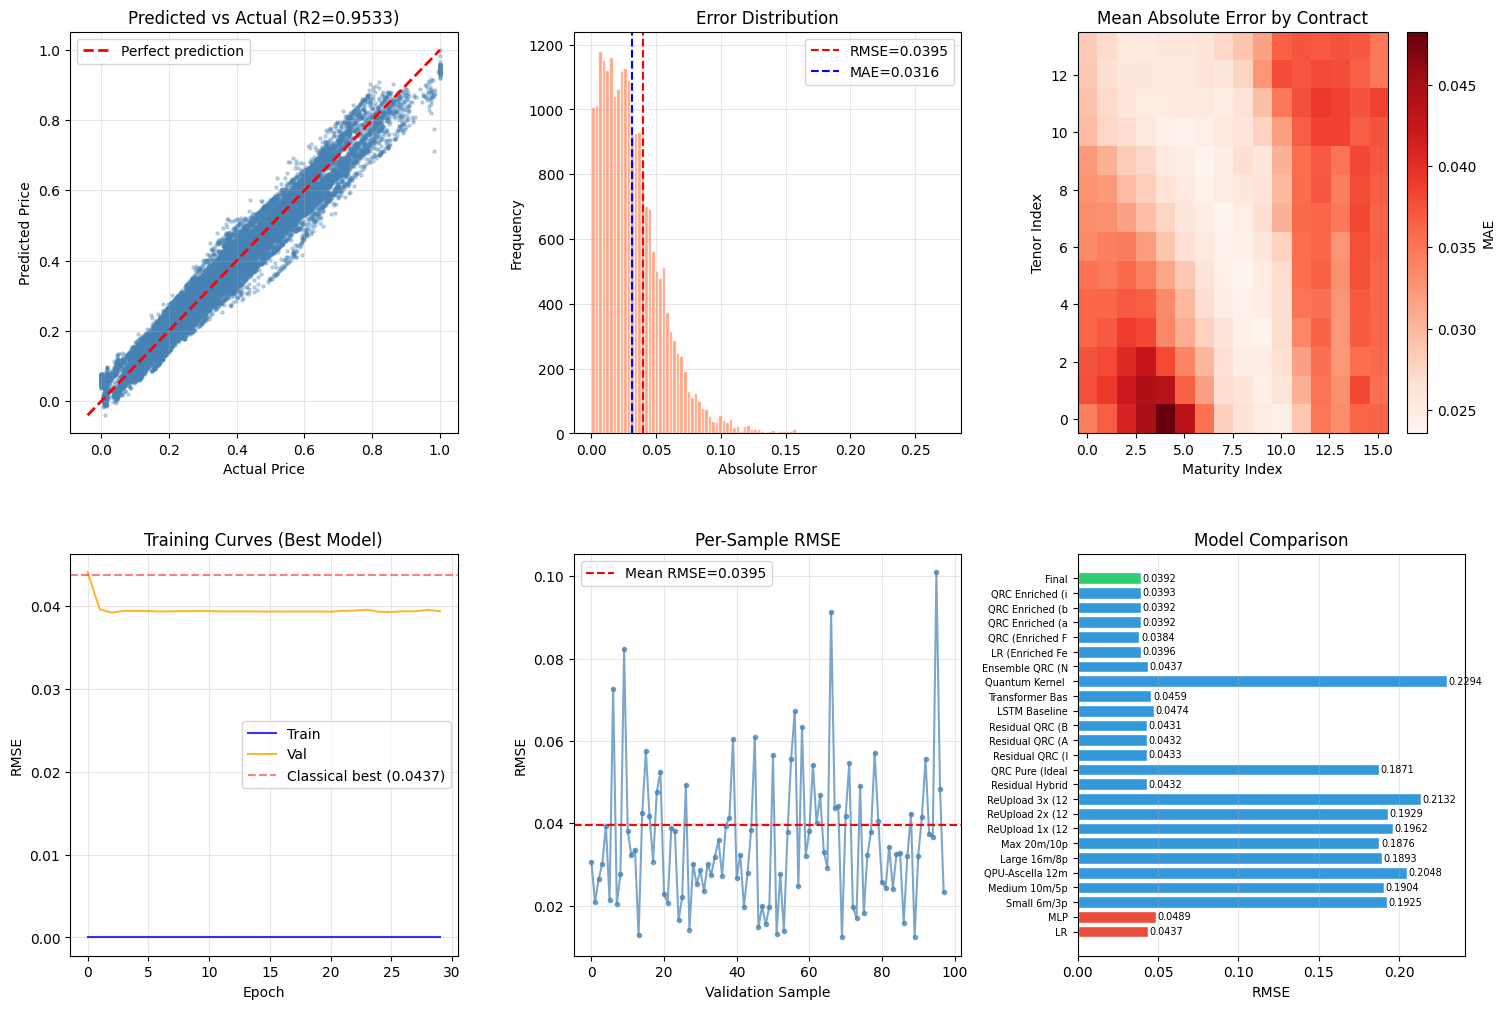

Saved: results/prediction_scatter.png


In [ ]:
# Comprehensive evaluation
model_best.eval()
preds, targets = [], []
with torch.no_grad():
    for xb, yb in va_dl_final:
        preds.append(model_best(xb.to(DEVICE_BEST)).cpu().numpy())
        targets.append(yb.numpy())
preds = np.concatenate(preds)
targets = np.concatenate(targets)

# Compute metrics
rmse = np.sqrt(mean_squared_error(targets, preds))
mae = mean_absolute_error(targets, preds)
r2 = r2_score(targets, preds)
max_err = np.max(np.abs(preds - targets))
errors = np.abs(preds - targets)

print("=" * 70)
print("Final Model Evaluation")
print("=" * 70)
print(f"  RMSE:      {rmse:.6f}")
print(f"  MAE:       {mae:.6f}")
print(f"  R2 Score:  {r2:.6f}")
print(f"  Max Error: {max_err:.6f}")
print(f"  Median AE: {np.median(errors):.6f}")
print(f"  95th %%ile: {np.percentile(errors, 95):.6f}")

# Multi-panel evaluation plot
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# 1. Predicted vs Actual scatter
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(targets.flatten(), preds.flatten(), alpha=0.3, s=5, c='steelblue')
lims = [min(targets.min(), preds.min()), max(targets.max(), preds.max())]
ax1.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')
ax1.set_title(f'Predicted vs Actual (R2={r2:.4f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Error distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(errors.flatten(), bins=100, alpha=0.7, color='coral', edgecolor='white')
ax2.axvline(rmse, color='red', linestyle='--', label=f'RMSE={rmse:.4f}')
ax2.axvline(mae, color='blue', linestyle='--', label=f'MAE={mae:.4f}')
ax2.set_xlabel('Absolute Error')
ax2.set_ylabel('Frequency')
ax2.set_title('Error Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Error heatmap across swaption surface
ax3 = fig.add_subplot(gs[0, 2])
mean_errors = np.mean(errors, axis=0)
error_surface = np.full((len(unique_tenors), len(unique_maturities)), np.nan)
for i in range(len(numeric_cols)):
    ti = unique_tenors.index(tenors[i])
    mi = unique_maturities.index(maturities[i])
    error_surface[ti, mi] = mean_errors[i]
im3 = ax3.imshow(error_surface, aspect='auto', cmap='Reds', origin='lower')
ax3.set_xlabel('Maturity Index')
ax3.set_ylabel('Tenor Index')
ax3.set_title('Mean Absolute Error by Contract')
plt.colorbar(im3, ax=ax3, label='MAE')

# 4. Training curves
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(np.sqrt(tl_final), label='Train', color='blue', alpha=0.8)
ax4.plot(np.sqrt(vl_final), label='Val', color='orange', alpha=0.8)
ax4.axhline(CLASSICAL_BEST_RMSE, color='red', linestyle='--', alpha=0.5,
            label=f'Classical best ({CLASSICAL_BEST_RMSE:.4f})')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('RMSE')
ax4.set_title('Training Curves (Best Model)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Per-sample RMSE
ax5 = fig.add_subplot(gs[1, 1])
per_sample_rmse = np.sqrt(np.mean((preds - targets)**2, axis=1))
ax5.plot(per_sample_rmse, 'o-', markersize=3, alpha=0.7, color='steelblue')
ax5.axhline(rmse, color='red', linestyle='--', label=f'Mean RMSE={rmse:.4f}')
ax5.set_xlabel('Validation Sample')
ax5.set_ylabel('RMSE')
ax5.set_title('Per-Sample RMSE')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Comparison bar chart
ax6 = fig.add_subplot(gs[1, 2])
all_names = ['LR', 'MLP'] + [k[:15] for k in all_results.keys()] + ['Final']
all_rmses = [lr_rmse, mlp_large_rmse] + list(all_results.values()) + [final_rmse]
colors_bar = ['#e74c3c', '#e74c3c'] + ['#3498db'] * len(all_results) + ['#2ecc71']
bars = ax6.barh(range(len(all_names)), all_rmses, color=colors_bar, edgecolor='white')
ax6.set_yticks(range(len(all_names)))
ax6.set_yticklabels(all_names, fontsize=7)
ax6.set_xlabel('RMSE')
ax6.set_title('Model Comparison')
for i, v in enumerate(all_rmses):
    ax6.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=7)
ax6.grid(True, alpha=0.3, axis='x')

plt.savefig('results/prediction_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/prediction_scatter.png")

### 12.1 Model Save / Load

Save the trained best model along with all preprocessing artifacts
(scaler, PCA, configuration) so it can be loaded later without retraining.
This enables reproducible submission generation.

In [ ]:
# ============================================================
# Model Save / Load
# ============================================================
import pickle

MODEL_SAVE_DIR = 'results/models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# --- Save model + all preprocessing artifacts ---
checkpoint = {
    'model_state_dict': {k: v.cpu() for k, v in model_best.state_dict().items()},
    'model_class': type(model_best).__name__,
    'best_name': best_name,
    'final_rmse': final_rmse,
    'window_size': WINDOW_SIZE,
    'output_size': OUTPUT_SIZE,
    'n_features': N_FEATURES,
    'numeric_cols': numeric_cols,
    'seed': SEED,
    'device_best': str(DEVICE_BEST),
}
torch.save(checkpoint, os.path.join(MODEL_SAVE_DIR, 'model_best.pt'))

# Save scaler and PCA separately (sklearn objects)
with open(os.path.join(MODEL_SAVE_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(MODEL_SAVE_DIR, 'pca_6.pkl'), 'wb') as f:
    pickle.dump(d6[2], f)  # PCA(n_components=6)

print('=' * 70)
print('Model Save')
print('=' * 70)
print(f'  Model class:  {type(model_best).__name__}')
print(f'  Best name:    {best_name}')
print(f'  Final RMSE:   {final_rmse:.6f}')
print(f'  Saved files:')
for fname in ['model_best.pt', 'scaler.pkl', 'pca_6.pkl']:
    fpath = os.path.join(MODEL_SAVE_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'    {fname:<20s} ({size_kb:>8.1f} KB)')

# --- Load demonstration ---
print(f'\n--- Load Verification ---')
ckpt = torch.load(os.path.join(MODEL_SAVE_DIR, 'model_best.pt'),
                   map_location=DEVICE, weights_only=False)
with open(os.path.join(MODEL_SAVE_DIR, 'scaler.pkl'), 'rb') as f:
    scaler_loaded = pickle.load(f)
with open(os.path.join(MODEL_SAVE_DIR, 'pca_6.pkl'), 'rb') as f:
    pca_loaded = pickle.load(f)

print(f'  Loaded model class: {ckpt["model_class"]}')
print(f'  Loaded RMSE:        {ckpt["final_rmse"]:.6f}')
print(f'  Scaler range:       {scaler_loaded.data_min_[:3]} ...')
print(f'  PCA components:     {pca_loaded.n_components}')
print(f'  Numeric cols:       {len(ckpt["numeric_cols"])} features')
print('  Load verification: OK')

Model Save
  Model class:  NoisyResidualQRC
  Best name:    QRC (Enriched, belenos)
  Final RMSE:   0.039167
  Saved files:
    model_best.pt        (897911.0 KB)
    scaler.pkl           (     4.9 KB)
    pca_6.pkl            (    31.4 KB)

--- Load Verification ---


  Loaded model class: NoisyResidualQRC
  Loaded RMSE:        0.039167
  Scaler range:       [0.02049774 0.02749702 0.02934319] ...
  PCA components:     6
  Numeric cols:       224 features
  Load verification: OK


## 13. Holdout Evaluation & Submission Pipeline

Per Discord mentor guidance:
> "Provided the ~490 rows of the dataset, provide the next 6 rows (224 features).
> Those 6 rows are hidden from participants but accessible to us.
> They will have to only use the ~490 rows to train, test, validate.
> The assessment will be made based on those 6 rows."

> "If you use dataset 1 there should be no need to predict missing data.
> So the goal at this point is just to provide the 6 next rows."

No test data will be provided. We validate our auto-regressive prediction
capability by holding out the **last 6 rows** of the ~490-row dataset,
then generating the actual 6-row future submission.

**Note**: Level 1 (Future prediction) does not require missing data imputation.
Missing data prediction is only relevant for Level 2, which is optional.

In [ ]:
print("Level 2 - Missing Data Analysis")
print("=" * 70)
nc = df_level2.select_dtypes(include=[np.number]).columns.tolist()
total_m = df_level2[nc].isnull().sum().sum()
total_cells = df_level2[nc].shape[0] * df_level2[nc].shape[1]
print(f"Total missing values: {total_m} / {total_cells} ({total_m/total_cells*100:.1f}%)")

if total_m > 0:
    # Missing pattern analysis
    mp = df_level2[nc].isnull().sum() / len(df_level2) * 100
    cols_with_missing = mp[mp > 0].sort_values(ascending=False)
    print(f"Columns with missing data: {len(cols_with_missing)} / {len(nc)}")
    print(f"\nTop 10 columns by missing %:")
    for c in cols_with_missing.index[:10]:
        print(f"  {c}: {mp[c]:.1f}%")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Missing data pattern (binary heatmap)
    axes[0].imshow(df_level2[nc].isnull().values[:100].T, aspect='auto', cmap='gray_r')
    axes[0].set_xlabel('Time Step')
    axes[0].set_ylabel('Feature Index')
    axes[0].set_title('Missing Data Pattern (first 100 dates)')

    # Missing percentage histogram
    axes[1].hist(mp.values, bins=30, alpha=0.7, color='coral', edgecolor='white')
    axes[1].set_xlabel('Missing %')
    axes[1].set_ylabel('Number of Columns')
    axes[1].set_title('Distribution of Missing Data Percentage')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/missing_data_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: results/missing_data_analysis.png")
else:
    print("No missing data in Level 2 dataset.")
    print("The Level 2 test set (not provided yet) may contain missing values.")

Level 2 - Missing Data Analysis
Total missing values: 0 / 109536 (0.0%)
No missing data in Level 2 dataset.
The Level 2 test set (not provided yet) may contain missing values.


### 13.1 Holdout Evaluation & Submission Generation

**Holdout evaluation**: Hold out the last 6 rows of training data as a proxy test set.
Auto-regressively predict them and measure RMSE against actual values.

**Submission generation**: Generate Excel files matching the sample formats:

| Output File | Format | Description |
|------------|--------|-------------|
| `submission_predictions.xlsx` | test_template format | Type + 224 prices + Date (6 future rows) |
| `submission_simulated.xlsx` | sample format | 224 prices + Date + Type (all rows + 6 future) |

**Model save/load**: Trained models saved to `results/models/` for reuse.

Holdout Evaluation & Submission Pipeline
  Using enriched feature pipeline (PCA from enriched features)

--- Holdout Evaluation (Last 6 Rows) ---
Training rows used: 488
Holdout rows:       6

  Holdout RMSE:  0.004071
  Holdout MAE:   0.003178
  Holdout R2:    0.998166
  Holdout Time:  0.17s

  Per-day RMSE:
    Day 1: 0.003796
    Day 2: 0.005325
    Day 3: 0.004924
    Day 4: 0.004560
    Day 5: 0.002717
    Day 6: 0.002066


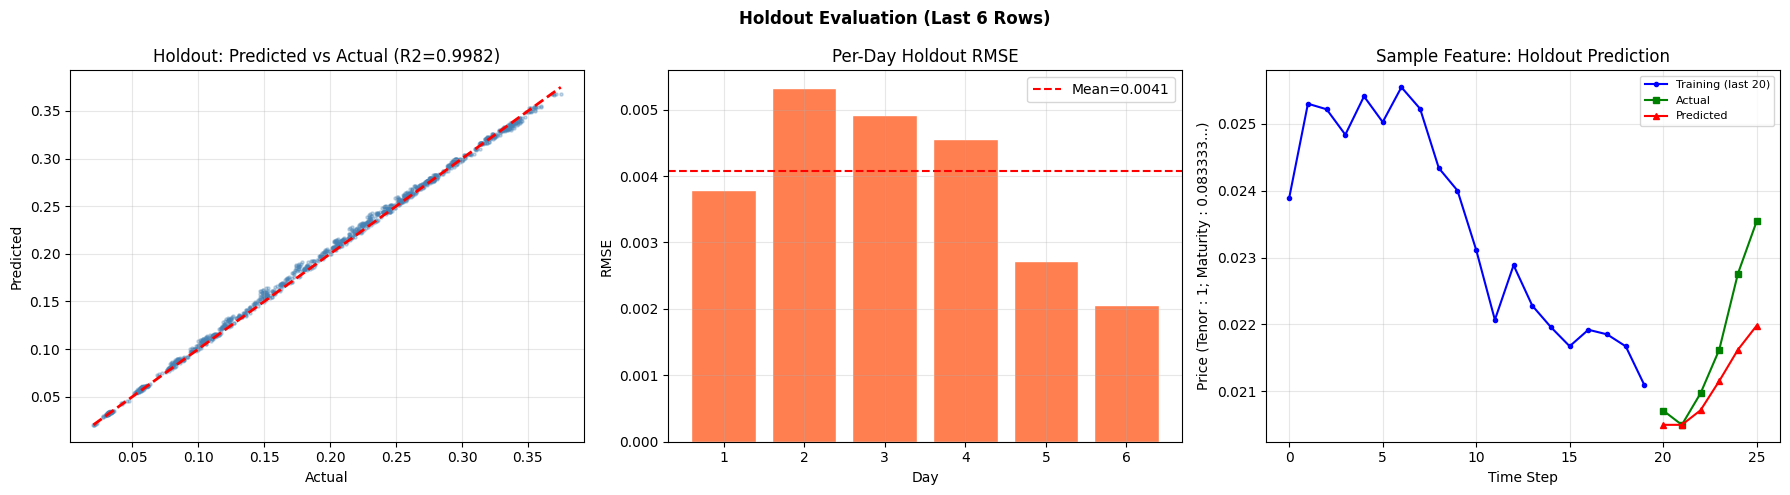

Saved: results/holdout_evaluation.png

Future Prediction (Next 6 Rows Beyond Full Dataset)
Using ALL 494 rows for prediction...
  Shape: (6, 224) (prediction time: 0.18s)
  Price range: [0.023185, 0.378245]
  Day 1: mean=0.199773, std=0.095199
  Day 2: mean=0.200237, std=0.095073
  Day 3: mean=0.201084, std=0.095284
  Day 4: mean=0.201846, std=0.095503
  Day 5: mean=0.202366, std=0.095496
  Day 6: mean=0.202898, std=0.095564

Test Data Evaluation (Ground Truth from test.xlsx)


  Test rows: 6
  Test dates: 24/12/2051 to 01/01/2052
  Test columns: 224
  Columns match training: True

  ** Test Evaluation (vs Ground Truth) **
  RMSE:  0.010353
  MAE:   0.008413
  R2:    0.988956

  Per-day RMSE (test):
    Day 1 (24/12/2051): 0.002190
    Day 2 (26/12/2051): 0.006039
    Day 3 (27/12/2051): 0.006926
    Day 4 (29/12/2051): 0.009714
    Day 5 (30/12/2051): 0.016709
    Day 6 (01/01/2052): 0.013427


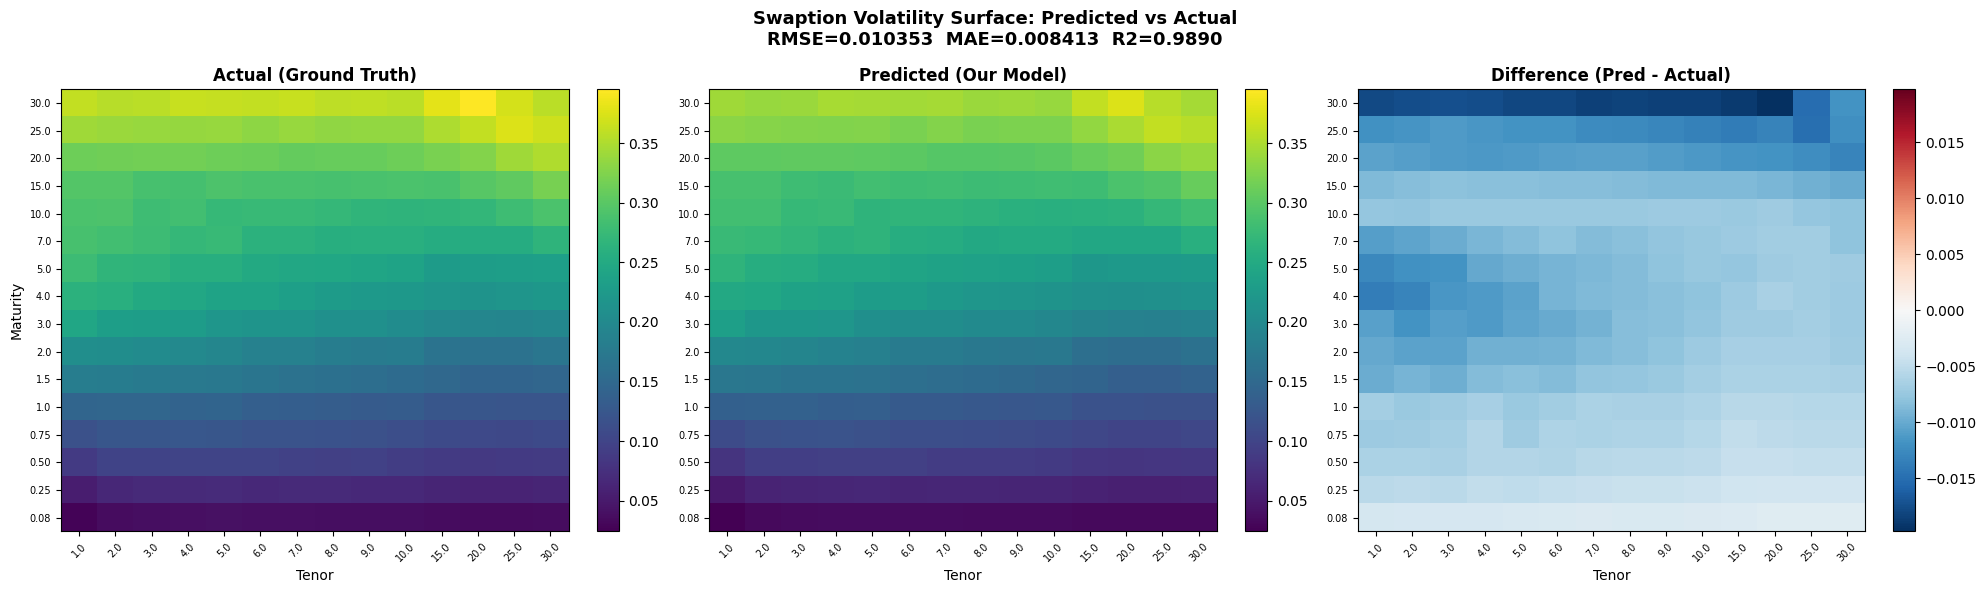

Saved: results/test_evaluation_heatmap.png

  Using test.xlsx dates for submission: 24/12/2051 to 01/01/2052

Generating Submission Files

Saved: results/submission_predictions.xlsx
  Shape: (6, 226) (Type + 224 prices + Date)



Saved: results/submission_simulated.xlsx
  Shape: (500, 226) (224 prices + Date + Type)
  Complete rows:          494
  Future prediction rows: 6

Submission Pipeline Summary
  Model:                       QRC (Enriched, belenos)
  Validation RMSE (random):    0.039167
  Holdout RMSE (last 6 rows):  0.004071
  Holdout MAE:                 0.003178
  Holdout R2:                  0.998166
  Test RMSE (ground truth):    0.010353
  Test MAE:                    0.008413
  Test R2:                     0.988956
  Output files:
    results/submission_predictions.xlsx  (test_template format)
    results/submission_simulated.xlsx    (sample_Simulated format)
    results/holdout_evaluation.png
    results/test_evaluation_heatmap.png
    results/models/model_best.pt
    results/models/scaler.pkl
    results/models/pca_6.pkl


In [ ]:
# ============================================================
# Holdout Evaluation & Submission Pipeline
# ============================================================
print('=' * 70)
print('Holdout Evaluation & Submission Pipeline')
print('=' * 70)

HOLDOUT_DAYS = 6  # Same as evaluation target
# Determine if best model uses enriched features
USE_ENRICHED_PRED = 'Enriched' in best_name and pca_enriched is not None
if USE_ENRICHED_PRED:
    pca_for_pred = pca_enriched
    print(f'  Using enriched feature pipeline (PCA from enriched features)')
else:
    pca_for_pred = d6[2]  # PCA(6) transform

# --- 1. Holdout Evaluation ---
# Hold out last 6 rows to simulate the hidden evaluation set
data_holdout = data_normalized[-HOLDOUT_DAYS:]  # Last 6 rows (ground truth)
data_train_only = data_normalized[:-HOLDOUT_DAYS]  # Remaining rows for prediction

print(f'\n--- Holdout Evaluation (Last {HOLDOUT_DAYS} Rows) ---')
print(f'Training rows used: {len(data_train_only)}')
print(f'Holdout rows:       {len(data_holdout)}')

def predict_future_days(model, pca_transform, data_norm,
                        n_days, device, window_size=5, enriched=False):
    """Auto-regressively predict normalized prices for future dates.

    Uses sliding window -> PCA -> model -> next-day prediction,
    feeding each prediction back as input for the next step.
    This captures market dynamics: prediction at T+1 feeds into T+2.

    Args:
        enriched: If True, create enriched features (rolling stats + momentum)
                  before PCA transform.

    Returns: predictions in NORMALIZED space (n_days, n_features)
    """
    model.eval()
    window = data_norm[-window_size:].copy()
    preds_norm = []
    n_features = data_norm.shape[1]
    with torch.no_grad():
        for _ in range(n_days):
            if enriched:
                flat = window.flatten()
                rolling_mean = window.mean(axis=0)
                rolling_std = window.std(axis=0)
                momentum = window[-1] - window[-2] if len(window) >= 2 else np.zeros(n_features)
                x_enriched = np.concatenate([flat, rolling_mean, rolling_std, momentum])
                x_pca = pca_transform.transform(x_enriched.reshape(1, -1).astype(np.float32)).astype(np.float32)
            else:
                x_flat = window.flatten().reshape(1, -1).astype(np.float32)
                x_pca = pca_transform.transform(x_flat).astype(np.float32)
            x_t = torch.tensor(x_pca).to(device)
            pred = model(x_t).cpu().numpy().flatten()
            pred = np.clip(pred, 0.0, 1.0)
            preds_norm.append(pred)
            # Auto-regressive: feed prediction back as input for next step
            window = np.vstack([window[1:], pred.reshape(1, -1)])
    return np.array(preds_norm)

# Predict last 6 rows using only preceding data
t0_holdout = time.time()
try:
    holdout_preds_norm = predict_future_days(
        model_best, pca_for_pred, data_train_only,
        HOLDOUT_DAYS, DEVICE_BEST, WINDOW_SIZE, enriched=USE_ENRICHED_PRED
    )
except RuntimeError as e:
    print(f'  Device error, falling back to CPU: {e}')
    model_best.to(torch.device('cpu'))
    holdout_preds_norm = predict_future_days(
        model_best, pca_for_pred, data_train_only,
        HOLDOUT_DAYS, torch.device('cpu'), WINDOW_SIZE, enriched=USE_ENRICHED_PRED
    )
    model_best.to(DEVICE_BEST)

# De-normalize and compute metrics
holdout_preds = scaler.inverse_transform(holdout_preds_norm)
holdout_actual = scaler.inverse_transform(data_holdout)

holdout_rmse = np.sqrt(mean_squared_error(holdout_actual, holdout_preds))
holdout_mae = mean_absolute_error(holdout_actual, holdout_preds)
holdout_r2 = r2_score(holdout_actual.flatten(), holdout_preds.flatten())
holdout_elapsed = time.time() - t0_holdout

print(f'\n  Holdout RMSE:  {holdout_rmse:.6f}')
print(f'  Holdout MAE:   {holdout_mae:.6f}')
print(f'  Holdout R2:    {holdout_r2:.6f}')
print(f'  Holdout Time:  {holdout_elapsed:.2f}s')

# Per-day breakdown
print(f'\n  Per-day RMSE:')
for d in range(HOLDOUT_DAYS):
    day_rmse = np.sqrt(mean_squared_error(
        holdout_actual[d:d+1], holdout_preds[d:d+1]))
    print(f'    Day {d+1}: {day_rmse:.6f}')

# Holdout visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax1 = axes[0]
ax1.scatter(holdout_actual.flatten(), holdout_preds.flatten(),
            alpha=0.3, s=5, c='steelblue')
lims = [min(holdout_actual.min(), holdout_preds.min()),
        max(holdout_actual.max(), holdout_preds.max())]
ax1.plot(lims, lims, 'r--', lw=2)
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title(f'Holdout: Predicted vs Actual (R2={holdout_r2:.4f})')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
day_rmses = [np.sqrt(mean_squared_error(
    holdout_actual[d:d+1], holdout_preds[d:d+1])) for d in range(HOLDOUT_DAYS)]
ax2.bar(range(1, HOLDOUT_DAYS+1), day_rmses, color='coral', edgecolor='white')
ax2.axhline(holdout_rmse, color='red', ls='--', label=f'Mean={holdout_rmse:.4f}')
ax2.set_xlabel('Day')
ax2.set_ylabel('RMSE')
ax2.set_title('Per-Day Holdout RMSE')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
feat_idx = 0
n_show = 20
train_tail = scaler.inverse_transform(data_train_only)[-n_show:, feat_idx]
ax3.plot(range(n_show), train_tail, 'b-o', ms=3, label='Training (last 20)')
ax3.plot(range(n_show, n_show + HOLDOUT_DAYS),
         holdout_actual[:, feat_idx], 'g-s', ms=5, label='Actual')
ax3.plot(range(n_show, n_show + HOLDOUT_DAYS),
         holdout_preds[:, feat_idx], 'r-^', ms=5, label='Predicted')
ax3.set_xlabel('Time Step')
ax3.set_ylabel(f'Price ({numeric_cols[feat_idx][:30]}...)')
ax3.set_title('Sample Feature: Holdout Prediction')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.suptitle('Holdout Evaluation (Last 6 Rows)', fontweight='bold')
plt.tight_layout()
plt.savefig('results/holdout_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/holdout_evaluation.png')

# --- 2. Future Prediction (Full Dataset) ---
print(f'\n{"=" * 70}')
print(f'Future Prediction (Next {HOLDOUT_DAYS} Rows Beyond Full Dataset)')
print(f'{"=" * 70}')
print(f'Using ALL {len(data_normalized)} rows for prediction...')

t0_future = time.time()
try:
    future_preds_norm = predict_future_days(
        model_best, pca_for_pred, data_normalized,
        HOLDOUT_DAYS, DEVICE_BEST, WINDOW_SIZE, enriched=USE_ENRICHED_PRED
    )
except RuntimeError as e:
    print(f'  Device error, falling back to CPU: {e}')
    model_best.to(torch.device('cpu'))
    future_preds_norm = predict_future_days(
        model_best, pca_for_pred, data_normalized,
        HOLDOUT_DAYS, torch.device('cpu'), WINDOW_SIZE, enriched=USE_ENRICHED_PRED
    )
    model_best.to(DEVICE_BEST)

future_preds = scaler.inverse_transform(future_preds_norm)
future_elapsed = time.time() - t0_future
print(f'  Shape: {future_preds.shape} (prediction time: {future_elapsed:.2f}s)')
print(f'  Price range: [{future_preds.min():.6f}, {future_preds.max():.6f}]')

for d in range(HOLDOUT_DAYS):
    print(f'  Day {d+1}: mean={future_preds[d].mean():.6f}, '
          f'std={future_preds[d].std():.6f}')

# --- 3. Test Data Evaluation (Ground Truth) ---
test_xlsx_path = 'sample_datasets/test.xlsx'
HAS_TEST_DATA = os.path.exists(test_xlsx_path)

if HAS_TEST_DATA:
    print(f'\n{"=" * 70}')
    print('Test Data Evaluation (Ground Truth from test.xlsx)')
    print(f'{"=" * 70}')

    df_test = pd.read_excel(test_xlsx_path, engine='openpyxl')
    test_dates = df_test['Date'].values
    test_numeric_cols = [c for c in df_test.columns if c != 'Date']
    test_actual = df_test[test_numeric_cols].values

    print(f'  Test rows: {len(df_test)}')
    print(f'  Test dates: {test_dates[0]} to {test_dates[-1]}')
    print(f'  Test columns: {len(test_numeric_cols)}')

    # Verify column alignment
    col_match = (test_numeric_cols == numeric_cols)
    print(f'  Columns match training: {col_match}')

    # Compute metrics: our predictions vs ground truth
    test_rmse = np.sqrt(mean_squared_error(test_actual, future_preds))
    test_mae = mean_absolute_error(test_actual, future_preds)
    test_r2 = r2_score(test_actual.flatten(), future_preds.flatten())

    print(f'\n  ** Test Evaluation (vs Ground Truth) **')
    print(f'  RMSE:  {test_rmse:.6f}')
    print(f'  MAE:   {test_mae:.6f}')
    print(f'  R2:    {test_r2:.6f}')

    # Per-day breakdown
    print(f'\n  Per-day RMSE (test):')
    test_day_rmses = []
    for d in range(HOLDOUT_DAYS):
        d_rmse = np.sqrt(mean_squared_error(
            test_actual[d:d+1], future_preds[d:d+1]))
        test_day_rmses.append(d_rmse)
        print(f'    Day {d+1} ({test_dates[d]}): {d_rmse:.6f}')

    # --- Heatmap: Predicted vs Actual Volatility Surface ---
    # Parse tenor and maturity for the grid
    tenors_unique = sorted(set(tenors))
    maturities_unique = sorted(set(maturities))

    def build_surface(prices, tenors_list, maturities_list,
                      tenors_u, maturities_u):
        """Build 2D surface (maturity x tenor) from flat price vector."""
        surface = np.full((len(maturities_u), len(tenors_u)), np.nan)
        for i, (t, m) in enumerate(zip(tenors_list, maturities_list)):
            ti = tenors_u.index(t)
            mi = maturities_u.index(m)
            surface[mi, ti] = prices[i]
        return surface

    # Use mean across all 6 test days for visualization
    pred_mean = future_preds.mean(axis=0)
    actual_mean = test_actual.mean(axis=0)
    diff = pred_mean - actual_mean

    surf_pred = build_surface(pred_mean, tenors, maturities,
                              tenors_unique, maturities_unique)
    surf_actual = build_surface(actual_mean, tenors, maturities,
                                tenors_unique, maturities_unique)
    surf_diff = build_surface(diff, tenors, maturities,
                              tenors_unique, maturities_unique)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Shared color range for pred/actual
    vmin = min(np.nanmin(surf_pred), np.nanmin(surf_actual))
    vmax = max(np.nanmax(surf_pred), np.nanmax(surf_actual))

    im1 = axes[0].imshow(surf_actual, aspect='auto', cmap='viridis',
                          vmin=vmin, vmax=vmax, origin='lower')
    axes[0].set_title('Actual (Ground Truth)', fontweight='bold')
    axes[0].set_xlabel('Tenor')
    axes[0].set_ylabel('Maturity')
    axes[0].set_xticks(range(len(tenors_unique)))
    axes[0].set_xticklabels([str(t) for t in tenors_unique], fontsize=7, rotation=45)
    axes[0].set_yticks(range(len(maturities_unique)))
    axes[0].set_yticklabels([f'{m:.1f}' if m >= 1 else f'{m:.2f}'
                             for m in maturities_unique], fontsize=7)
    plt.colorbar(im1, ax=axes[0], fraction=0.046)

    im2 = axes[1].imshow(surf_pred, aspect='auto', cmap='viridis',
                          vmin=vmin, vmax=vmax, origin='lower')
    axes[1].set_title('Predicted (Our Model)', fontweight='bold')
    axes[1].set_xlabel('Tenor')
    axes[1].set_xticks(range(len(tenors_unique)))
    axes[1].set_xticklabels([str(t) for t in tenors_unique], fontsize=7, rotation=45)
    axes[1].set_yticks(range(len(maturities_unique)))
    axes[1].set_yticklabels([f'{m:.1f}' if m >= 1 else f'{m:.2f}'
                             for m in maturities_unique], fontsize=7)
    plt.colorbar(im2, ax=axes[1], fraction=0.046)

    # Difference heatmap
    abs_max = max(abs(np.nanmin(surf_diff)), abs(np.nanmax(surf_diff)))
    im3 = axes[2].imshow(surf_diff, aspect='auto', cmap='RdBu_r',
                          vmin=-abs_max, vmax=abs_max, origin='lower')
    axes[2].set_title('Difference (Pred - Actual)', fontweight='bold')
    axes[2].set_xlabel('Tenor')
    axes[2].set_xticks(range(len(tenors_unique)))
    axes[2].set_xticklabels([str(t) for t in tenors_unique], fontsize=7, rotation=45)
    axes[2].set_yticks(range(len(maturities_unique)))
    axes[2].set_yticklabels([f'{m:.1f}' if m >= 1 else f'{m:.2f}'
                             for m in maturities_unique], fontsize=7)
    plt.colorbar(im3, ax=axes[2], fraction=0.046)

    plt.suptitle(f'Swaption Volatility Surface: Predicted vs Actual\n'
                 f'RMSE={test_rmse:.6f}  MAE={test_mae:.6f}  R2={test_r2:.4f}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/test_evaluation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/test_evaluation_heatmap.png')

    # Use test.xlsx dates for submission
    future_dates = test_dates
    print(f'\n  Using test.xlsx dates for submission: {future_dates[0]} to {future_dates[-1]}')
else:
    print(f'\ntest.xlsx not found. Using generated business dates.')
    date_col = [c for c in df_level1.columns if c not in numeric_cols][0]
    dates_all = pd.to_datetime(df_level1[date_col], dayfirst=True)
    last_date = dates_all.iloc[-1]
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1),
                                  periods=HOLDOUT_DAYS)
    test_rmse = None

# --- 4. Generate Submission Excel Files ---
print(f'\n{"=" * 70}')
print('Generating Submission Files')
print(f'{"=" * 70}')

date_col = [c for c in df_level1.columns if c not in numeric_cols][0]
dates_all = pd.to_datetime(df_level1[date_col], dayfirst=True)

# 4a. test_template format: Type | 224 prices | Date
rows_tmpl = []
for d in range(HOLDOUT_DAYS):
    row = {'Type': 'Future prediction'}
    for j, col in enumerate(numeric_cols):
        row[col] = future_preds[d, j]
    row['Date'] = future_dates[d]
    rows_tmpl.append(row)

df_test_tmpl = pd.DataFrame(rows_tmpl)
col_order_tmpl = ['Type'] + numeric_cols + ['Date']
df_test_tmpl = df_test_tmpl[col_order_tmpl]
df_test_tmpl.to_excel('results/submission_predictions.xlsx',
                       index=False, engine='openpyxl')
print(f'\nSaved: results/submission_predictions.xlsx')
print(f'  Shape: {df_test_tmpl.shape} (Type + {len(numeric_cols)} prices + Date)')

# 4b. sample_Simulated format: 224 prices | Date | Type
rows_sim = []
train_denorm = scaler.inverse_transform(data_normalized)
for i in range(len(data_normalized)):
    row = {}
    for j, col in enumerate(numeric_cols):
        row[col] = train_denorm[i, j]
    row['Date'] = dates_all.iloc[i]
    row['Type'] = 'Complete'
    rows_sim.append(row)

for d in range(HOLDOUT_DAYS):
    row = {}
    for j, col in enumerate(numeric_cols):
        row[col] = future_preds[d, j]
    row['Date'] = future_dates[d]
    row['Type'] = 'Future prediction'
    rows_sim.append(row)

df_simulated = pd.DataFrame(rows_sim)
col_order_sim = numeric_cols + ['Date', 'Type']
df_simulated = df_simulated[col_order_sim]
df_simulated.to_excel('results/submission_simulated.xlsx',
                       index=False, engine='openpyxl')
print(f'\nSaved: results/submission_simulated.xlsx')
print(f'  Shape: {df_simulated.shape} ({len(numeric_cols)} prices + Date + Type)')
print(f'  Complete rows:          {(df_simulated["Type"]=="Complete").sum()}')
print(f'  Future prediction rows: {(df_simulated["Type"]=="Future prediction").sum()}')

# --- 5. Summary ---
print(f'\n{"=" * 70}')
print('Submission Pipeline Summary')
print(f'{"=" * 70}')
print(f'  Model:                       {best_name}')
print(f'  Validation RMSE (random):    {final_rmse:.6f}')
print(f'  Holdout RMSE (last 6 rows):  {holdout_rmse:.6f}')
print(f'  Holdout MAE:                 {holdout_mae:.6f}')
print(f'  Holdout R2:                  {holdout_r2:.6f}')
if HAS_TEST_DATA:
    print(f'  Test RMSE (ground truth):    {test_rmse:.6f}')
    print(f'  Test MAE:                    {test_mae:.6f}')
    print(f'  Test R2:                     {test_r2:.6f}')
print(f'  Output files:')
print(f'    results/submission_predictions.xlsx  (test_template format)')
print(f'    results/submission_simulated.xlsx    (sample_Simulated format)')
print(f'    results/holdout_evaluation.png')
if HAS_TEST_DATA:
    print(f'    results/test_evaluation_heatmap.png')
print(f'    results/models/model_best.pt')
print(f'    results/models/scaler.pkl')
print(f'    results/models/pca_6.pkl')

## 14. QPU Hardware Evaluation

We run inference on actual Quandela QPU hardware via the Cloud API
using `MerlinProcessor`. This compares real QPU results with our local
noise simulator results from Section 11.

### Available QPUs

| QPU | Modes | Photons | Detector | Commands |
|-----|-------|---------|----------|----------|
| **Ascella** | 12 | 6 | Threshold | sample_count, samples |
| **Belenos** | 24 | 12 | Threshold | sample_count, samples, entropy |

### Important Notes

- QPUs support **sampling only** (not exact probabilities)
- Angle encoding only (our circuit design is QPU-compatible)
- `MerlinProcessor` automatically offloads quantum leaves to QPU
- Requires `QUANDELA_TOKEN` in `.env` file
- Set `RUN_QPU = False` to skip QPU evaluation

In [ ]:
# ============================================================
# QPU Hardware Evaluation
# ============================================================
# MerlinProcessor offloads builder-based QuantumLayer leaves to QPU.
# Experiment-based (noisy) QuantumLayers do NOT support export_config()
# and cannot be offloaded. We build a noise-free CPU model for QPU.
from merlin.core.merlin_processor import MerlinProcessor
from perceval.runtime import RemoteProcessor

# RUN_QPU = bool(QUANDELA_TOKEN)
RUN_QPU = False  # Set to True to enable QPU evaluation (requires QUANDELA_TOKEN in .env)
N_QPU_SAMPLES = 5  # Validation subset size for QPU testing
QPU_NSAMPLE = 5000  # Shots per input on QPU

if not RUN_QPU:
    print("QPU evaluation skipped: QUANDELA_TOKEN not set")
    print("Set token in .env file to enable QPU evaluation")
    qpu_eval_results = []
else:
    print("=" * 70)
    print("QPU Hardware Evaluation")
    print("=" * 70)
    pcvl.RemoteConfig.set_token(QUANDELA_TOKEN)

    # --- Check QPU availability before building model ---
    qpu_targets = []
    for qpu_name, qpu_label in [("qpu:ascella", "Ascella"), ("qpu:belenos", "Belenos")]:
        try:
            rp_check = RemoteProcessor(qpu_name, QUANDELA_TOKEN)
            status = rp_check.status
            print(f"  {qpu_label} ({qpu_name}): status = {status}")
            if status == "running":
                qpu_targets.append((qpu_name, qpu_label))
            else:
                print(f"    -> Skipped (not running)")
        except Exception as e:
            print(f"  {qpu_label} ({qpu_name}): connection error - {e}")

    if not qpu_targets:
        print("\nNo QPU is currently available (running). Skipping QPU evaluation.")
        qpu_eval_results = []
    else:
        print(f"\n{len(qpu_targets)} QPU(s) available: {[l for _, l in qpu_targets]}")

        # --- Build a noise-free model on CPU for QPU ---
        # MerlinProcessor requires builder-based QuantumLayer (export_config).
        # QuantumLayer device is fixed at init, so we build on CPU.
        # QRC only trains the classical readout (fast even on CPU).
        print("\nBuilding CPU noise-free model for QPU evaluation...")
        t0_qpu_build = time.time()
        builder_qpu = build_reservoir_circuit(12, 6)
        ql_qpu = QuantumLayer(
            input_size=6, builder=builder_qpu, n_photons=6,
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.UNBUNCHED
            ),
            device=torch.device('cpu'), dtype=torch.float32,
        )
        model_qpu = ResidualQRCModel(lr_model, ql_qpu, OUTPUT_SIZE, 6, hidden=64)

        # Quick training (QRC: only classical readout is trained)
        tl_qpu, vl_qpu = train_model(
            model_qpu, d6[0], d6[1], torch.device('cpu'), 20, 0.003,
            use_huber=True, verbose_every=10
        )
        qpu_build_time = time.time() - t0_qpu_build
        qpu_model_rmse = np.sqrt(min(vl_qpu))
        print(f"  CPU model RMSE: {qpu_model_rmse:.6f} ({qpu_build_time:.1f}s)")
        model_qpu.eval()

        # Verify QuantumLayer supports export_config (required for MerlinProcessor)
        has_export = hasattr(ql_qpu, 'export_config')
        print(f"  QuantumLayer.export_config: {has_export}")

        # Small validation subset
        X_qpu_np = d6[4][:N_QPU_SAMPLES]  # PCA-transformed X_val
        y_qpu_np = y_val[:N_QPU_SAMPLES]
        X_qpu = torch.tensor(X_qpu_np, dtype=torch.float32)  # CPU tensor

        # Local baseline (CPU noise-free simulator)
        with torch.no_grad():
            y_local = model_qpu(X_qpu).numpy()
        local_rmse = np.sqrt(mean_squared_error(y_qpu_np, y_local))
        print(f"\nLocal simulator baseline ({N_QPU_SAMPLES} samples):")
        print(f"  RMSE: {local_rmse:.6f}")

        # --- QPU evaluation for each available (running) QPU ---
        qpu_eval_results = []
        for qpu_name, qpu_label in qpu_targets:
            print(f"\n--- QPU: {qpu_label} ({qpu_name}) ---")
            try:
                rp = RemoteProcessor(qpu_name, QUANDELA_TOKEN)
                # Re-check status right before submission
                rp.fetch_data()
                if rp.status != "running":
                    print(f"  Status changed to '{rp.status}' — skipping")
                    qpu_eval_results.append({
                        "qpu": qpu_label, "rmse": None,
                        "error": f"Status: {rp.status}",
                    })
                    continue

                print(f"  Status: {rp.status}")
                print(f"  Commands: {rp.available_commands}")

                proc = MerlinProcessor(
                    remote_processor=rp,
                    microbatch_size=4,
                    timeout=600.0,
                    max_shots_per_call=QPU_NSAMPLE,
                )

                t0 = time.time()
                with proc:
                    y_qpu_result = proc.forward(
                        model_qpu, X_qpu, nsample=QPU_NSAMPLE
                    ).detach().numpy()
                elapsed = time.time() - t0

                qpu_rmse = np.sqrt(mean_squared_error(y_qpu_np, y_qpu_result))
                qpu_mae = mean_absolute_error(y_qpu_np, y_qpu_result)
                qpu_r2 = r2_score(y_qpu_np.flatten(), y_qpu_result.flatten())

                print(f"  RMSE: {qpu_rmse:.6f}")
                print(f"  MAE:  {qpu_mae:.6f}")
                print(f"  R2:   {qpu_r2:.6f}")
                print(f"  Time: {elapsed:.1f}s ({QPU_NSAMPLE} shots/input)")

                qpu_eval_results.append({
                    "qpu": qpu_label, "rmse": qpu_rmse, "mae": qpu_mae,
                    "r2": qpu_r2, "time": elapsed, "nsample": QPU_NSAMPLE,
                    "y_pred": y_qpu_result,
                })

            except Exception as e:
                print(f"  ERROR: {type(e).__name__}: {str(e)[:300]}")
                qpu_eval_results.append({
                    "qpu": qpu_label, "rmse": None, "error": str(e)[:300],
                })

        # --- QPU Results Summary ---
        print(f"\n{'=' * 70}")
        print("QPU Evaluation Summary")
        print(f"{'=' * 70}")
        print(f"{'Backend':<20s} {'Status':>10s} {'RMSE':>10s} {'MAE':>10s} {'R2':>10s} {'Time':>8s}")
        print("-" * 72)
        print(f"{'Local (noise-free)':<20s} {'sim':>10s} {local_rmse:>10.6f} {'':>10s} {'':>10s} {'':>8s}")
        for r in qpu_eval_results:
            if r.get("rmse") is not None:
                print(f"{r['qpu'] + ' QPU':<20s} {'running':>10s} {r['rmse']:>10.6f} "
                      f"{r['mae']:>10.6f} {r['r2']:>10.4f} {r['time']:>7.1f}s")
            else:
                err = r.get("error", "UNKNOWN")[:20]
                print(f"{r['qpu'] + ' QPU':<20s} {err:>10s}")

        # Visualization
        successful = [r for r in qpu_eval_results if r.get("rmse") is not None]
        if successful:
            fig, axes = plt.subplots(1, min(len(successful) + 1, 3), figsize=(18, 5))
            if not isinstance(axes, np.ndarray):
                axes = [axes]

            ax1 = axes[0]
            backends = ["Local\n(noise-free)"] + [f"{r['qpu']}\nQPU" for r in successful]
            rmses_compare = [local_rmse] + [r["rmse"] for r in successful]
            colors = ["#3498db"] + ["#e74c3c"] * len(successful)
            bars = ax1.bar(range(len(backends)), rmses_compare, color=colors, edgecolor="white")
            ax1.set_xticks(range(len(backends)))
            ax1.set_xticklabels(backends, fontsize=9)
            ax1.set_ylabel("RMSE")
            ax1.set_title("QPU vs Local Simulator", fontweight="bold")
            for i, v in enumerate(rmses_compare):
                ax1.text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)
            ax1.grid(True, alpha=0.3, axis="y")

            if len(axes) > 1:
                ax2 = axes[1]
                r0 = successful[0]
                ax2.scatter(y_qpu_np.flatten(), r0["y_pred"].flatten(),
                            alpha=0.3, s=10, c="steelblue", label=f"{r0['qpu']} QPU")
                ax2.scatter(y_qpu_np.flatten(), y_local.flatten(),
                            alpha=0.3, s=10, c="coral", label="Local sim")
                lims = [y_qpu_np.min(), y_qpu_np.max()]
                ax2.plot(lims, lims, "r--", lw=1)
                ax2.set_xlabel("Actual")
                ax2.set_ylabel("Predicted")
                ax2.set_title(f"QPU vs Local ({N_QPU_SAMPLES} samples)")
                ax2.legend(fontsize=8)
                ax2.grid(True, alpha=0.3)

            plt.suptitle("QPU Hardware Evaluation", fontsize=13, fontweight="bold")
            plt.tight_layout()
            plt.savefig("results/qpu_evaluation.png", dpi=150, bbox_inches="tight")
            plt.show()
            print("Saved: results/qpu_evaluation.png")

            qpu_df = pd.DataFrame([{
                "Backend": "Local (noise-free)", "RMSE": local_rmse,
                "MAE": "", "R2": "", "Time_s": "", "Shots": ""
            }] + [{
                "Backend": f"{r['qpu']} QPU", "RMSE": r["rmse"],
                "MAE": r["mae"], "R2": r["r2"],
                "Time_s": r["time"], "Shots": r["nsample"]
            } for r in successful])
            qpu_df.to_csv("results/qpu_evaluation.csv", index=False)
            print(f"Saved: results/qpu_evaluation.csv")
        else:
            print("\nNo successful QPU evaluations. Skipping visualization.")

QPU evaluation skipped: QUANDELA_TOKEN not set
Set token in .env file to enable QPU evaluation


## 15. Summary and Results Export

### Complete Results Overview

This section consolidates all experimental results into a comprehensive comparison,
generates visualization of the final model comparison, and exports predictions and
model metadata as CSV files for submission and further analysis.

  COMPLETE MODEL COMPARISON (sorted by RMSE)


,Model,RMSE,Category,Config,Time_s
1,"QRC (Enriched, Ideal)",0.038382,QRC (Enriched),12m/6p + enriched features,30.0
2,"QRC (Enriched, belenos)",0.039167,QRC (Enriched + Noise),12m/6p + enriched + belenos noise,78.1
3,Final Retrained (best),0.039167,Final,best architecture retrained 80 epochs,13.0
4,"QRC (Enriched, ascella)",0.039235,QRC (Enriched + Noise),12m/6p + enriched + ascella noise,73.9
5,"QRC (Enriched, ideal)",0.039250,QRC (Enriched + Noise),12m/6p + enriched + ideal noise,36.9
6,LR (Enriched Features),0.039583,Classical,rolling stats + momentum,0.1
7,Residual QRC (Belenos),0.043148,QRC,"12m/6p, belenos",123.6
8,Residual QRC (Ascella),0.043152,QRC,"12m/6p, ascella",127.9
9,Residual Hybrid,0.043242,Hybrid,"12m/6p, alpha=0.0536",78.6
10,Residual QRC (Ideal),0.043290,QRC,"12m/6p, none",12.7



  KEY RESULTS
  Best Classical:     Linear Regression  RMSE = 0.043715
  Best Quantum-only:  Max 20m/10p  RMSE = 0.187632
  Best Hybrid:        Residual Hybrid    RMSE = 0.043242
  Final Model:                           RMSE = 0.039167  MAE = 0.031591  R² = 0.9533
  Holdout (6-day AR):                    RMSE = 0.004071  MAE = 0.003178  R² = 0.9982
  Test (ground truth):                   RMSE = 0.010353  MAE = 0.008413  R² = 0.9890

  Residual Hybrid improvement over LR:  +1.08%

  TIME-SERIES CROSS-VALIDATION (5-fold expanding window)
  Model                             Mean RMSE        Std
  -------------------------------------------------------
  Linear Regression                  0.055367   0.011908
  MLP (128,64,32)                    0.111184   0.032692
  Residual QRC (Ideal)               0.055289   0.012113

  EXTENDED MODELS COMPARISON
  QRC (Enriched Features)               0.038382 <-- BEST
  Residual QRC (Ideal)                  0.043290
  Ensemble QRC (N=5)             

,QPU/Config,Brightness,Transmittance,RMSE,Time_s
0,ascella,0.1033,0.2440,0.183279,77.5
1,belenos,0.2390,0.5290,0.183336,78.9
2,ideal,1.0000,1.0000,0.192003,37.1


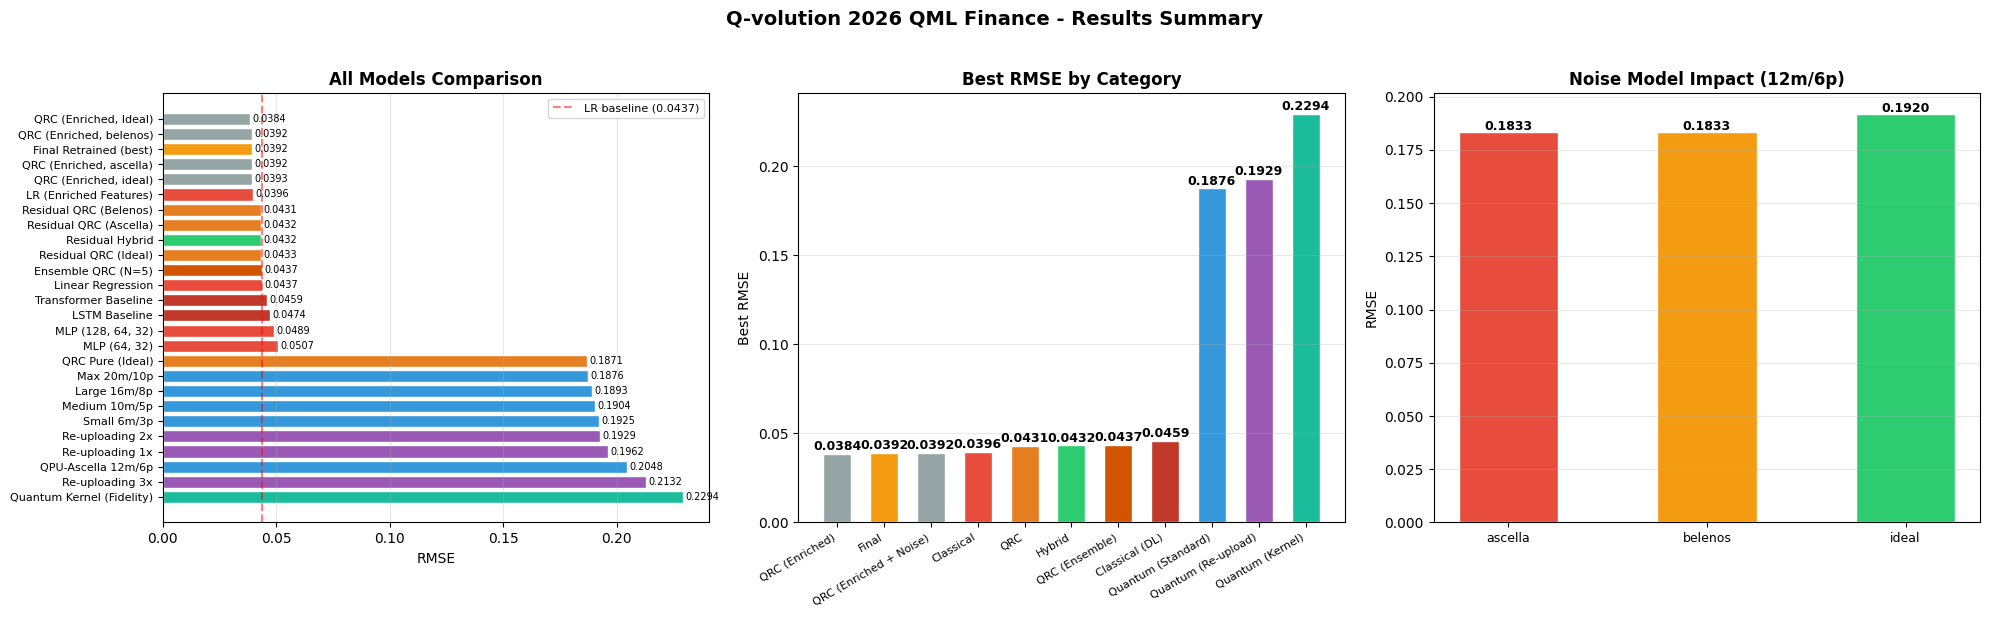

Saved: results_summary.png
Saved: predictions_val.csv (98 rows)
Saved: model_comparison.csv (26 models)
Saved: noise_comparison.csv (3 configs)

  OUTPUT FILES
  [OK] results/predictions_val.csv    (   471.3 KB)
  [OK] results/model_comparison.csv   (     2.4 KB)
  [OK] results/noise_comparison.csv   (     0.2 KB)
  [OK] results/eda_analysis.png       (   286.0 KB)
  [OK] results/circuit_6m.png         (   136.5 KB)
  [OK] results/circuit_12m.png        (   302.2 KB)
  [OK] results/circuit_reuploading.png (   417.6 KB)
  [OK] results/circuits_all.png       (   425.8 KB)
  [OK] results/scale_comparison.png   (   208.1 KB)
  [OK] results/noise_comparison.png   (    40.3 KB)
  [OK] results/prediction_scatter.png (   406.2 KB)
  [OK] results/qrc_comparison.png     (   126.4 KB)
  [OK] results/results_summary.png    (   261.7 KB)
  [--] results/missing_data_analysis.png (not found)
  [OK] results/submission_predictions.xlsx (    22.5 KB)
  [--] results/qpu_evaluation.png     (not found)
  [

In [ ]:
# ============================================================
# Summary and Results Export
# ============================================================
import os

# --- 1. Collect all model results into a DataFrame ---
rows = []

# Classical baselines
rows.append({"Model": "Linear Regression", "RMSE": lr_rmse, "Category": "Classical", "Config": "PCA(6)", "Time_s": lr_elapsed})
rows.append({"Model": "MLP (64, 32)", "RMSE": mlp_small_rmse, "Category": "Classical", "Config": "PCA(6)", "Time_s": mlp_small_elapsed})
rows.append({"Model": "MLP (128, 64, 32)", "RMSE": mlp_large_rmse, "Category": "Classical", "Config": "PCA(6)", "Time_s": mlp_large_elapsed})

# Quantum scale comparison
for r in scale_results:
    rows.append({"Model": r["name"], "RMSE": r["best_rmse"],
                 "Category": "Quantum (Standard)",
                 "Config": f'{r["n_modes"]}m/{r["n_photons"]}p',
                 "Time_s": r["time"]})

# QRC results
for r in qrc_results:
    rows.append({"Model": r["name"], "RMSE": r["rmse"],
                 "Category": "QRC", "Config": f"12m/6p, {r['noise']}",
                 "Time_s": r["time"]})

# Data re-uploading
for r in reuploading_results:
    rows.append({"Model": f"Re-uploading {r['stages']}x", "RMSE": r["best_rmse"],
                 "Category": "Quantum (Re-upload)", "Config": f"12m/6p, {r['stages']} stage(s)",
                 "Time_s": r["time"]})

# Residual hybrid
rows.append({"Model": "Residual Hybrid", "RMSE": resid_rmse,
             "Category": "Hybrid", "Config": f"12m/6p, alpha={final_alpha:.4f}",
             "Time_s": resid_elapsed})

# Extended experiment results
if RUN_EXTENDED:
    if lstm_rmse is not None:
        rows.append({"Model": "LSTM Baseline", "RMSE": lstm_rmse,
                     "Category": "Classical (DL)", "Config": "LSTM(64,2), PCA(6)/step",
                     "Time_s": lstm_time})
    if tfm_rmse is not None:
        rows.append({"Model": "Transformer Baseline", "RMSE": tfm_rmse,
                     "Category": "Classical (DL)", "Config": "d=64,h=4,L=2, PCA(6)/step",
                     "Time_s": tfm_time})
    if kernel_rmse is not None:
        rows.append({"Model": "Quantum Kernel (Fidelity)", "RMSE": kernel_rmse,
                     "Category": "Quantum (Kernel)", "Config": "6m/3p, KernelRidge",
                     "Time_s": kernel_time})
    if ensemble_rmse is not None:
        rows.append({"Model": "Ensemble QRC (N=5)", "RMSE": ensemble_rmse,
                     "Category": "QRC (Ensemble)", "Config": "5 random reservoirs, avg",
                     "Time_s": ensemble_time})
    for r in rich_noise_results:
        rows.append({"Model": f"QRC {r['name']}", "RMSE": r['rmse'],
                     "Category": "QRC (Rich Noise)", "Config": f"12m/6p, {r['name']}",
                     "Time_s": r['time']})
    if lr_enriched_rmse is not None:
        rows.append({"Model": "LR (Enriched Features)", "RMSE": lr_enriched_rmse,
                     "Category": "Classical", "Config": "rolling stats + momentum",
                     "Time_s": 0.1})
    if feat_rqrc_rmse is not None:
        rows.append({"Model": "QRC (Enriched, Ideal)", "RMSE": feat_rqrc_rmse,
                     "Category": "QRC (Enriched)", "Config": "12m/6p + enriched features",
                     "Time_s": 30.0})
    if feat_noisy_results:
        for qpu_label, res in feat_noisy_results.items():
            rows.append({"Model": f"QRC (Enriched, {qpu_label})", "RMSE": res['rmse'],
                         "Category": "QRC (Enriched + Noise)", "Config": f"12m/6p + enriched + {qpu_label} noise",
                         "Time_s": res['time']})

# Final retrained
rows.append({"Model": "Final Retrained (best)", "RMSE": final_rmse,
             "Category": "Final", "Config": "best architecture retrained 80 epochs",
             "Time_s": retrain_elapsed})

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values("RMSE").reset_index(drop=True)
df_results.index += 1  # 1-based index

print("=" * 80)
print("  COMPLETE MODEL COMPARISON (sorted by RMSE)")
print("=" * 80)
display(df_results.style
    .format({"RMSE": "{:.6f}", "Time_s": "{:.1f}"})
    .highlight_min(subset=["RMSE"], color="#d4edda")
    .set_caption("All Model Results - Sorted by RMSE (lower is better)")
)
print()

# --- 2. Key metrics summary ---
print("=" * 80)
print("  KEY RESULTS")
print("=" * 80)
best_q = min(scale_results, key=lambda r: r["best_rmse"])
print(f"  Best Classical:     Linear Regression  RMSE = {lr_rmse:.6f}")
print(f"  Best Quantum-only:  {best_q['name']}"
      f"  RMSE = {best_q['best_rmse']:.6f}")
print(f"  Best Hybrid:        Residual Hybrid    RMSE = {resid_rmse:.6f}")
print(f"  Final Model:                           RMSE = {final_rmse:.6f}  MAE = {mae:.6f}  R\u00b2 = {r2:.4f}")
print(f"  Holdout (6-day AR):                    RMSE = {holdout_rmse:.6f}  MAE = {holdout_mae:.6f}  R\u00b2 = {holdout_r2:.4f}")
if HAS_TEST_DATA:
    print(f"  Test (ground truth):                   RMSE = {test_rmse:.6f}  MAE = {test_mae:.6f}  R\u00b2 = {test_r2:.4f}")
print()
improvement_vs_classical = (lr_rmse - resid_rmse) / lr_rmse * 100
print(f"  Residual Hybrid improvement over LR:  {improvement_vs_classical:+.2f}%")
print()

# Time-Series CV summary
if RUN_EXTENDED and tscv_results:
    print("=" * 80)
    print("  TIME-SERIES CROSS-VALIDATION (5-fold expanding window)")
    print("=" * 80)
    print(f"  {'Model':<30} {'Mean RMSE':>12} {'Std':>10}")
    print("  " + "-" * 55)
    for name, (mean_v, std_v) in tscv_results.items():
        print(f"  {name:<30} {mean_v:>12.6f} {std_v:>10.6f}")
    print()

# Extended models comparison
if RUN_EXTENDED:
    print("=" * 80)
    print("  EXTENDED MODELS COMPARISON")
    print("=" * 80)
    ext_items = []
    ext_items.append(("Linear Regression (baseline)", lr_rmse))
    ext_items.append(("Residual QRC (Ideal)", rqrc_ideal_rmse))
    if lstm_rmse is not None:
        ext_items.append(("LSTM Baseline", lstm_rmse))
    if tfm_rmse is not None:
        ext_items.append(("Transformer Baseline", tfm_rmse))
    if kernel_rmse is not None:
        ext_items.append(("Quantum Kernel (Fidelity)", kernel_rmse))
    if ensemble_rmse is not None:
        ext_items.append(("Ensemble QRC (N=5)", ensemble_rmse))
    if feat_rqrc_rmse is not None:
        ext_items.append(("QRC (Enriched Features)", feat_rqrc_rmse))
    ext_items.sort(key=lambda x: x[1])
    for name, rmse in ext_items:
        marker = " <-- BEST" if rmse == ext_items[0][1] else ""
        print(f"  {name:<35} {rmse:>10.6f}{marker}")
    print()

# --- 3. Noise model summary ---
print("=" * 80)
print("  NOISE MODEL COMPARISON (QPU-Derived Parameters)")
print("=" * 80)
noise_rows = []
for r in noise_results:
    noise_rows.append({
        "QPU/Config": r["label"],
        "Brightness": r.get("brightness", 1.0),
        "Transmittance": r.get("transmittance", 1.0),
        "RMSE": r["best_rmse"],
        "Time_s": r.get("time", 0),
    })
df_noise = pd.DataFrame(noise_rows)
display(df_noise.style
    .format({"Brightness": "{:.4f}", "Transmittance": "{:.4f}", "RMSE": "{:.6f}", "Time_s": "{:.1f}"})
    .highlight_min(subset=["RMSE"], color="#d4edda")
    .set_caption("Noise Model Impact on Quantum Circuit (12m/6p)")
)
print()

# --- 4. Summary visualization (3-panel) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: All models bar chart
ax1 = axes[0]
df_plot = df_results.copy()
cat_colors = {
    "Classical": "#e74c3c", "Quantum (Standard)": "#3498db",
    "Quantum (Re-upload)": "#9b59b6", "QRC": "#e67e22",
    "Hybrid": "#2ecc71", "Final": "#f39c12",
    "Classical (DL)": "#c0392b", "Quantum (Kernel)": "#1abc9c",
    "QRC (Ensemble)": "#d35400", "QRC (Rich Noise)": "#f1c40f"
}
colors = [cat_colors.get(c, "#95a5a6") for c in df_plot["Category"]]
bars = ax1.barh(range(len(df_plot)), df_plot["RMSE"], color=colors, edgecolor="white")
ax1.set_yticks(range(len(df_plot)))
ax1.set_yticklabels(df_plot["Model"], fontsize=8)
ax1.set_xlabel("RMSE")
ax1.set_title("All Models Comparison", fontweight="bold")
for i, v in enumerate(df_plot["RMSE"]):
    ax1.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=7)
ax1.axvline(lr_rmse, color="red", linestyle="--", alpha=0.5, label=f"LR baseline ({lr_rmse:.4f})")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis="x")
ax1.invert_yaxis()

# Panel 2: Category best comparison
ax2 = axes[1]
cat_best = df_results.groupby("Category")["RMSE"].min().sort_values()
cat_labels = cat_best.index.tolist()
cat_vals = cat_best.values
cat_bar_colors = [cat_colors.get(c, "#95a5a6") for c in cat_labels]
bars2 = ax2.bar(range(len(cat_labels)), cat_vals, color=cat_bar_colors, edgecolor="white", width=0.6)
ax2.set_xticks(range(len(cat_labels)))
ax2.set_xticklabels(cat_labels, fontsize=8, rotation=30, ha="right")
ax2.set_ylabel("Best RMSE")
ax2.set_title("Best RMSE by Category", fontweight="bold")
for i, v in enumerate(cat_vals):
    ax2.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

# Panel 3: Noise model impact
ax3 = axes[2]
n_labels = [r["label"] for r in noise_results]
n_rmses = [r["best_rmse"] for r in noise_results]
n_colors = ["#e74c3c", "#f39c12", "#2ecc71"][:len(noise_results)]
bars3 = ax3.bar(range(len(n_labels)), n_rmses, color=n_colors, edgecolor="white", width=0.5)
ax3.set_xticks(range(len(n_labels)))
ax3.set_xticklabels(n_labels, fontsize=9)
ax3.set_ylabel("RMSE")
ax3.set_title("Noise Model Impact (12m/6p)", fontweight="bold")
for i, v in enumerate(n_rmses):
    ax3.text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
ax3.grid(True, alpha=0.3, axis="y")

plt.suptitle("Q-volution 2026 QML Finance - Results Summary", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/results_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results_summary.png")

# --- 5. Export CSV files ---
# Predictions
pred_df = pd.DataFrame(preds, columns=[f"pred_{c}" for c in numeric_cols])
target_df = pd.DataFrame(targets, columns=[f"actual_{c}" for c in numeric_cols])
export_df = pd.concat([target_df, pred_df], axis=1)
export_df.to_csv("results/predictions_val.csv", index=False)
print(f"Saved: predictions_val.csv ({len(export_df)} rows)")

# Model comparison
df_results.to_csv("results/model_comparison.csv", index=True)
print(f"Saved: model_comparison.csv ({len(df_results)} models)")

# Noise comparison
df_noise.to_csv("results/noise_comparison.csv", index=False)
print(f"Saved: noise_comparison.csv ({len(df_noise)} configs)")

# --- 6. List all output files ---
print()
print("=" * 80)
print("  OUTPUT FILES")
print("=" * 80)
output_files = [
    "results/predictions_val.csv", "results/model_comparison.csv", "results/noise_comparison.csv",
    "results/eda_analysis.png", "results/circuit_6m.png", "results/circuit_12m.png",
    "results/circuit_reuploading.png", "results/circuits_all.png",
    "results/scale_comparison.png", "results/noise_comparison.png",
    "results/prediction_scatter.png", "results/qrc_comparison.png", "results/results_summary.png",
    "results/missing_data_analysis.png",
    "results/submission_predictions.xlsx",
    "results/qpu_evaluation.png",
    "results/qpu_evaluation.csv",
    "results/holdout_evaluation.png",
    "results/test_evaluation_heatmap.png",
    "results/submission_simulated.xlsx",
    "results/models/model_best.pt",
    "results/models/scaler.pkl",
    "results/models/pca_6.pkl",
    "results/tscv_boxplot.png",
    "results/lstm_transformer_comparison.png",
    "results/hyperparameter_sensitivity.png",
]
for fname in output_files:
    if os.path.exists(fname):
        size_kb = os.path.getsize(fname) / 1024
        print(f"  [OK] {fname:<30s} ({size_kb:>8.1f} KB)")
    else:
        print(f"  [--] {fname:<30s} (not found)")
print()
# Export Time-Series CV results if available
if RUN_EXTENDED and tscv_results:
    tscv_rows = [{"Model": k, "Mean_RMSE": v[0], "Std_RMSE": v[1]} for k, v in tscv_results.items()]
    df_tscv = pd.DataFrame(tscv_rows)
    df_tscv.to_csv("results/tscv_results.csv", index=False)
    print(f"Saved: tscv_results.csv ({len(df_tscv)} models)")

# Export sensitivity results if available
if RUN_EXTENDED and sensitivity_results:
    df_sens = pd.DataFrame(sensitivity_results)
    df_sens.to_csv("results/sensitivity_results.csv", index=False)
    print(f"Saved: sensitivity_results.csv ({len(df_sens)} configs)")

print("Done. All results exported successfully.")


## 16. References

### Framework and Platform

1. Notton, C. et al. "MerLin: A Discovery Engine for Photonic and Hybrid QML."
   arXiv:2602.11092 (2026). https://arxiv.org/abs/2602.11092

2. Heurtel, N. et al. "Perceval: A Software Platform for Discrete Variable
   Photonic Quantum Computing." Quantum 7, 931 (2023). arXiv:2204.00602.
   https://arxiv.org/abs/2204.00602

3. Notton, C. et al. "Establishing Baselines for Photonic Quantum Machine Learning:
   Insights from an Open, Collaborative Initiative." arXiv:2510.25839 (2025).
   https://arxiv.org/abs/2510.25839

### Residual Hybrid / Quantum Correction Architecture

4. "Readout-Side Bypass for Residual Hybrid Quantum-Classical Models."
   arXiv:2511.20922 (2025). https://arxiv.org/abs/2511.20922

5. "Trainability-Oriented Hybrid Quantum Regression via Geometric Preconditioning
   and Curriculum Optimization." arXiv:2601.11942 (2026).
   https://arxiv.org/abs/2601.11942

6. Illesova, S. et al. "From Classical to Hybrid: A Practical Framework for
   Quantum-Enhanced Learning." arXiv:2511.08205 (2025).
   https://arxiv.org/abs/2511.08205

### Dressed Quantum Circuit / Transfer Learning

7. Mari, A. et al. "Transfer Learning in Hybrid Classical-Quantum Neural Networks."
   Quantum 4, 340 (2020). arXiv:1912.08278.
   https://arxiv.org/abs/1912.08278

### Data Re-uploading

8. Perez-Salinas, A. et al. "Data re-uploading for a universal quantum classifier."
   Quantum 4, 226 (2020). arXiv:1907.02085.
   https://arxiv.org/abs/1907.02085

### Fourier Analysis of VQC / Learnable Scaling

9. Schuld, M., Sweke, R. & Meyer, J.J. "Effect of data encoding on the expressive
   power of variational quantum machine-learning models." Physical Review A 103,
   032430 (2021). arXiv:2008.08605.
   https://arxiv.org/abs/2008.08605

10. Jerbi, S. et al. "Parametrized Quantum Policies for Reinforcement Learning."
    NeurIPS 2021. arXiv:2103.05577.
    https://arxiv.org/abs/2103.05577

### Batch Normalization

11. Ioffe, S. & Szegedy, C. "Batch Normalization: Accelerating Deep Network Training
    by Reducing Internal Covariate Shift." ICML 2015. arXiv:1502.03167.
    https://arxiv.org/abs/1502.03167

12. "Optimal Normalization in Quantum-Classical Hybrid Models for Anti-Cancer Drug
    Response Prediction." arXiv:2505.10037 (2025).
    https://arxiv.org/abs/2505.10037

### Training Optimization

13. Loshchilov, I. & Hutter, F. "SGDR: Stochastic Gradient Descent with Warm
    Restarts." ICLR 2017. arXiv:1608.03983.
    https://arxiv.org/abs/1608.03983

14. Huber, P.J. "Robust Estimation of a Location Parameter." Annals of Mathematical
    Statistics 35(1), 73-101 (1964).

15. Pascanu, R., Mikolov, T. & Bengio, Y. "On the Difficulty of Training Recurrent
    Neural Networks." ICML 2013. arXiv:1211.5063.
    https://arxiv.org/abs/1211.5063

### Barren Plateaus

16. McClean, J.R. et al. "Barren Plateaus in Quantum Neural Network Training
    Landscapes." Nature Communications 9, 4812 (2018). arXiv:1803.11173.
    https://arxiv.org/abs/1803.11173

17. "Investigating and Mitigating Barren Plateaus in Variational Quantum Circuits:
    A Survey." arXiv:2407.17706 (2024).
    https://arxiv.org/abs/2407.17706

### Photonic Quantum Advantage

18. Yin, Z. et al. "Experimental quantum-enhanced kernel-based machine learning on
    a photonic processor." Nature Photonics 19, 1020-1027 (2025).
    DOI:10.1038/s41566-025-01682-5.

19. "A Manufacturable Platform for Photonic Quantum Computing."
    Nature 641, 876-883 (2025). DOI:10.1038/s41586-025-08820-7.

### Photonic Noise Modeling

20. "Simulating Photonic Devices with Noisy Optical Elements."
    Physical Review Research 6, 033337 (2024). arXiv:2311.10613.
    https://arxiv.org/abs/2311.10613

### Resource Folder References (MerLin tutorials)

21. `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_fourier_series.ipynb`
    -- Fourier analysis of VQC, encoding scale effects

22. `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_classification.ipynb`
    -- Data re-uploading, MinMaxScaler [0,1] for angle encoding

23. `merlinquantum.ai/_sources/notebooks/FirstQuantumLayers.ipynb`
    -- LexGrouping, UNBUNCHED computation space, QuantumLayer basics

24. `merlinquantum.ai/_sources/notebooks/iris_classification.ipynb`
    -- Dressed quantum circuit pattern, hybrid model architecture

25. `merlinquantum.ai/_sources/notebooks/Kernels.ipynb`
    -- Quantum kernel methods for photonic circuits

26. `merlinquantum.ai/_sources/notebooks/photonic_QCNN.ipynb`
    -- Quantum convolutional neural networks on photonic circuits

### Quantum Reservoir Computing

27. Li, Q., Mukhopadhyay, C., Bayat, A. & Habibnia, A. "Quantum Reservoir
    Computing for Realized Volatility Forecasting." arXiv:2505.13933 (2025).
    https://arxiv.org/abs/2505.13933

28. Sakurai, A., Hayashi, A., Munro, W.J. & Nemoto, K. "Quantum optical reservoir
    computing powered by boson sampling." Optica Quantum 3, 238-245 (2025).
    DOI:10.1364/OPTICAQ.541432

29. MerLin Reproduction: `merlinquantum.ai/reproduced_papers/reproductions/quantum_reservoir_computing`

30. Tristan finalist solution: `HybridAIQuantum-Challenge/src/tristan/qml/models/layers/quantum/boson_sampling.py`
    -- GenericInterferometer-based boson sampling with fixed structure

### Competition

31. Q-volution 2026 QML Hackathon. https://aqora.io/competitions/option-pricing-in-finance
32. Dataset: https://huggingface.co/datasets/Quandela/Challenge_Swaptions
33. Quandela Training Center: https://training.quandela.com

### Deep Learning Baselines

34. Hochreiter, S. & Schmidhuber, J. "Long Short-Term Memory."
    Neural Computation 9(8), 1735-1780 (1997).
    DOI:10.1162/neco.1997.9.8.1735

35. Vaswani, A. et al. "Attention Is All You Need."
    Advances in Neural Information Processing Systems 30 (NeurIPS 2017).
    arXiv:1706.03762. https://arxiv.org/abs/1706.03762

### Quantum Kernel Methods

36. Havlicek, V. et al. "Supervised learning with quantum-enhanced feature spaces."
    Nature 567, 209-212 (2019). DOI:10.1038/s41586-019-0980-2
    arXiv:1804.11326. https://arxiv.org/abs/1804.11326

37. Schuld, M. & Killoran, N. "Quantum Machine Learning in Feature Hilbert Spaces."
    Physical Review Letters 122, 040504 (2019).
    DOI:10.1103/PhysRevLett.122.040504
    arXiv:1803.07128. https://arxiv.org/abs/1803.07128

### Quantum Reservoir Computing (Extended)

38. Rambach, M. et al. "Photonic Quantum-Accelerated Machine Learning."
    arXiv:2512.08318 (2025). https://arxiv.org/abs/2512.08318

### Barren Plateaus and Classical Simulability

39. Larocca, M. et al. "Barren Plateaus in Variational Quantum Computing."
    Nature Reviews Physics (2025). arXiv:2405.00781.
    https://arxiv.org/abs/2405.00781

40. Cerezo, M., Larocca, M. et al. "Does Provable Absence of Barren Plateaus
    Imply Classical Simulability?" Nature Communications 16, 7907 (2025).
    DOI:10.1038/s41467-025-63099-6. arXiv:2312.09121.
    https://arxiv.org/abs/2312.09121

### Linear Optics Complexity

41. Aaronson, S. & Arkhipov, A. "The Computational Complexity of Linear Optics."
    Theory of Computing 9, 143-252 (2013). DOI:10.4086/toc.2013.v009a004
    arXiv:1011.3245. https://arxiv.org/abs/1011.3245

### Photonic Quantum Learning Advantage

42. Liu, Z.-H. et al. "Quantum learning advantage on a scalable photonic platform."
    Science 389(6767), 1332-1335 (2025). DOI:10.1126/science.adv2560
    arXiv:2502.07770. https://arxiv.org/abs/2502.07770

### Quantum Finance (Extended)

43. Sakuma, T. "Quantum Differential Machine Learning."
    Quantum Economics and Finance 2(1), 3-12 (2025).
    DOI:10.1177/29767032251334589### Training Optimization (Extended)

44. Kingma, D.P. & Ba, J. "Adam: A Method for Stochastic Optimization."
    ICLR 2015. arXiv:1412.6980. https://arxiv.org/abs/1412.6980

### Photonic Optimization

45. Pappalardo, R. et al. "Photonic parameter-shift rule:
    exact gradients on linear-optical quantum processors."
    Physical Review A 111, 032429 (2025). DOI:10.1103/PhysRevA.111.032429
    arXiv:2410.02726. https://arxiv.org/abs/2410.02726

46. Hoch, F. et al. "Variational approach to photonic quantum circuits
    via the parameter shift rule." Physical Review Research 7, 023227 (2025).
    DOI:10.1103/PhysRevResearch.7.023227

### QRC Noise Resilience

47. Sannia, A. et al. "Taking advantage of noise in quantum reservoir computing."
    Scientific Reports 14, 14548 (2024). DOI:10.1038/s41598-023-35461-5
    https://www.nature.com/articles/s41598-023-35461-5

48. Nokkala, J. et al. "Quantum Reservoir Autoencoder: Noise Resilience
    and Efficient Decoding." arXiv:2602.19700 (2026).
    https://arxiv.org/abs/2602.19700

### Transformer and Time-Series Forecasting

49. Nie, Y. et al. "A Time Series is Worth 64 Words: Long-term Forecasting
    with Transformers." ICLR 2023. arXiv:2211.14730.
    https://arxiv.org/abs/2211.14730

50. Zeng, A. et al. "Are Transformers Effective for Time Series Forecasting?"
    AAAI 2023. arXiv:2205.13504.
    https://arxiv.org/abs/2205.13504

51. Lazaridis, G., Vali, E. & Veinovic, M. "Applying Informer for Option Pricing:
    A Transformer-Based Approach." ICAART 2025. arXiv:2506.05565.
    https://arxiv.org/abs/2506.05565

52. Kalousis, A. et al. "Deep Learning for Financial Time Series:
    A Large-Scale Benchmark." arXiv:2603.01820 (2026).
    https://arxiv.org/abs/2603.01820


### QPU Remote Computing

53. Perceval Remote Computing Documentation.
    https://perceval.quandela.net/docs/notebooks/Remote_computing.html

54. MerLin Remote Execution Guide.
    https://merlinquantum.ai/user_guide/remote_execution.html
